In [27]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt

# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

# Original six, unchanged.
RED    = "#cd001a"
ORANGE = "#ef6a00"
YELLOW = "#f2cd00"
GREEN  = "#79c300"
BLUE   = "#1961ae"
PURPLE = "#61007d"
# Extensions, same flat saturated register.
PINK   = "#e5006d"
BROWN  = "#8a5a2b"
OLIVE  = "#6b8f00"
TEAL   = "#00a19a"
FOREST = "#1f7a33"
NAVY   = "#0b2d6b"
GREY   = "#6e6e6e"
SKY    = "#3fa9f5"
CYAN   = "#00b8d4"
INDIGO = "#534bae"

# Thinking mode is a BENCHMARK DIMENSION, not a footnote: the same checkpoint scores
# ~20 points apart on GSM8K with and without it. The two live in separate trees so they
# can never be silently mixed (everything under results/vllm/think/ was produced
# with thinking on, including runs whose command line said --no-think — see that
# directory's README). Comment out a mode to drop it from the grid.
# Two independent axes, flattened into one "mode" key: THINKING (Qwen3 <think> blocks)
# and SERVING (one engine, vs a real disaggregated prefill/decode pair exchanging KV).
# Disaggregated is the deployment-accurate measurement, so it is a first-class series
# here rather than a footnote -- run_eval_disagg.sh writes the identical on-disk layout.
# DISAGGREGATED IS THE REPORTED NUMBER. Single-engine results are only a POINT-WISE
# fallback: for each (model, method, benchmark, step) the disaggregated value is used
# when it exists, and the single-engine value fills the hole otherwise. That keeps a
# curve continuous while the disagg sweep is still filling in, without ever discarding
# a disaggregated point in favour of a single-engine one.
#
# Sources are listed in PRIORITY ORDER per thinking mode.
SOURCES = {
    "think":   [("disagg", Path("../qad/results/disagg/think")),
                ("single", Path("../qad/results/vllm/think"))],
    "nothink": [("disagg", Path("../qad/results/disagg/nothink")),
                ("single", Path("../qad/results/vllm/nothink"))],
}
MODE_LABEL = {"think": "think", "nothink": "no-think"}
MODES = [m for m, srcs in SOURCES.items() if any(d.exists() for _, d in srcs)]

# Which training recipes to plot. Checkpoint tags are <RUN>-<model>-<method>-<hash>, and
# RUN doubles as the FAMILY namespace: run_qad.sh builds the tag and
# cluster_scripts/submit_missing_evals.py reads it back from the same table. Listing more
# than one loads them into ONE grid -- every (family, size) becomes its own row, so Gemma-3
# rows appear alongside Qwen3 rows with no other change to the figures.
RUNS = ["qad3x", "gemma3"]
# RUNS = ["qad"]     # 10M tokens, cosine decay -- the older recipe

# Modes a FAMILY can actually have. Gemma-3 has NO thinking switch: `enable_thinking` is
# accepted and completely inert (the rendered prompt is byte-identical with it True, False
# or absent) and `--no-think` hard-fails at eval time, so a Gemma "no-think" cell can never
# be filled. This matters beyond labelling: avg_accuracy() only averages steps where EVERY
# plotted benchmark has a value, so averaging a Gemma row over a mode it cannot have would
# blank its Average and bar panels entirely instead of just dropping one column.
FAMILY_MODES = {"qad3x":  ["think", "nothink"],
                "qad":    ["think", "nothink"],
                "gemma3": ["think"]}


def family_of(model):
    """Family of a MODEL tag (not a run tag): google-gemma-3-4b-it -> gemma3."""
    return "gemma3" if model.startswith("google-") else "qad3x"


def short_name(model):
    """Display label: drop the vendor prefix only.

    Qwen-Qwen3-4B -> Qwen3 4B, google-gemma-3-4b-it -> Gemma 3 4b.
    """
    if "Qwen" in model:
        return model.replace("Qwen-", "", 1).replace("Qwen3", "Qwen 3").replace("-", " ", 1)
    elif "gemma" in model:
        return model.replace("google-gemma-3-", "Gemma 3 ").replace("-it", "")

# task -> (display title, preferred metric key). Metric keys vary by task filter:
#   - math500          : symbolic math_verify,none
#   - mmlu_flan_cot_*   : CoT generative MMLU; a GROUP whose top-level row is empty —
#                         the metric lives on 57 subject leaves (exact_match,flexible-extract),
#                         so get_metric() sample-weight-aggregates the leaves.
#   - mmlu_pro         : CoT; aggregates at the group level as exact_match,custom-extract.
# Comment a row out to drop it from the panels AND from the mean-recovery panel.
BENCHMARKS = {
    "gsm8k":                  ("GSM8K",      "exact_match,flexible-extract"),
    "minerva_math500":        ("MATH-500",   "math_verify,none"),
    # "aime25":                 ("AIME-2025",  "exact_match,none"),
    # "mmlu_flan_cot_zeroshot": ("MMLU (CoT)", "exact_match,flexible-extract"),
    "mmlu_pro":               ("MMLU-Pro",   "exact_match,custom-extract"),
}

# One plotted column per (benchmark, thinking mode). Keys are "<task>@<mode>" so the
# rest of the notebook needs no change; only modes actually present on disk appear.
TASKS = {
    f"{task}@{mode}": (f"{title} [{MODE_LABEL[mode]}]", key)
    for task, (title, key) in BENCHMARKS.items()
    for mode in MODES
}

# quantizer -> (legend label, colour, linestyle, marker). Plot order follows this dict.
# Comment a row out to hide that method; any method found on disk but missing here is
# reported by the warning below and simply not plotted.
#
# A key may be either "<method>" or "<method>-<hash>". The hash-qualified form wins
# when both are present, and is how you separate several runs of the SAME method that
# differ only in hyperparameters (the hash is over the quantizer params). Without it
# every arm of a sweep collapses onto one label/color — see the collision warning.
METHODS = {
    # --- homogeneous: one format on both phases (solid, round) ---------------
    
    # Weight-only
    "nvfp4a16":  ("NVFP4A16", SKY, "-", "o"),
    "lloyd43":   ("LUT3", CYAN, "-", "o"),
    "lloyd21":   ("LUT2", TEAL, "-", "o"),

    # Homogeneous
    "nvfp4":     ("NVFP4", RED, "-", "o"),
    "nvfp4lloyd43upcastboth": ("LUT3", GREEN, "-", "o"),
    "nvfp4lloyd21upcastboth": ("LUT2", BLUE, "-", "o"),

    # Upcasted
    "nvfp4pdshared": ("NVFP4", ORANGE, "--", "*"),
    "nvfp4lloyd43upcast": ("LUT3", OLIVE, "--", "*"),
    "nvfp4lloyd21upcast": ("LUT2", NAVY, "--", "*"),

    # Decoupled
    "nvfp4pdsplit":  ("NVFP4", YELLOW, "-.", "*"),
    "nvfp4lloyd43split":  ("LUT3", FOREST, "-.", "*"),
    "nvfp4lloyd21split":  ("LUT2", INDIGO, "-.", "*"),

    # Phase ablation
    "nvfp4prefill":  ("NVFP4 prefill", YELLOW, "--", "*"),
    "nvfp4decode":   ("NVFP4 decode", NAVY, "--", "*"),

    # --full-disag ablation
    "nvfp4lloyd21split-a9264ff4": ("LUT2, beyond linear disaggregation", PURPLE, ":", "s"),
    "nvfp4lloyd43split-a9264ff4": ("LUT3, beyond linear disaggregation", OLIVE, ":", "s"),

    # Deprecated
    # "ste4bit":  ("W4A4 INT4 GS128",     "tab:orange"),
    # "ste3bit":  ("STE 3-bit",     "tab:red"),
    # "ste2bit":  ("STE 2-bit",     "tab:brown"),
    # "quest4bit":("QuEST 4-bit",   "tab:purple"),
    # "quest3bit":("QuEST 3-bit",   "tab:brown"),
    # "quest2bit":("QuEST 2-bit",   "tab:pink"),
    # "fp8":      ("FP8",           "tab:gray"),
    # "nvfp4lloyd43shared": ("NVFP4/LUT3 common", FOREST, "--", "*"),
    # "lloyd3bit": ("W3A16 LLOYD", CYAN, "-", "o"),
}


# How disaggregated a format is. ONE table, because two figures key off it -- the bar
# legend's sections and the Pareto's dashed chains -- and if they drift apart the same
# format silently reads as two different things in two figures.
#   none   : one weight, one compute pathway; both phases get the same treatment
#   format : one stored weight, two pathways (decode skips the autocast)
#   full   : two masters, two stored weights, nothing shared
DISAG = {
    "nvfp4": "none", "nvfp4lloyd43upcastboth": "none", "nvfp4lloyd21upcastboth": "none",
    "nvfp4pdshared": "format", "nvfp4lloyd43upcast": "format", "nvfp4lloyd21upcast": "format",
    "nvfp4pdsplit": "full", "nvfp4lloyd43split": "full", "nvfp4lloyd21split": "full",
}
DISAG_LABEL = {"none": "Not disaggregated", "format": "Format disaggregated",
               "full": "Fully disaggregated"}


def _leaf_metric(m, key):
    if key in m:
        return m[key]
    for k, v in m.items():
        if k.startswith(("exact_match,", "math_verify,")) and not k.endswith("_stderr"):
            return v
    return None


def get_metric(doc, task, key):
    results = doc.get("results", {})
    r = results.get(task, {})
    # 1) direct metric on the task / group aggregate row
    v = _leaf_metric(r, key)
    if v is not None:
        return v
    # 2) group with an empty top-level row: sample-weighted mean over subject leaves
    #    (keys like "<task>_abstract_algebra"; excludes "<task>::category" mid-groups).
    num = den = 0.0
    for t, m in results.items():
        if t == task or not t.startswith(task + "_"):
            continue
        lv = _leaf_metric(m, key)
        if lv is None:
            continue
        w = m.get("sample_len") or 1
        num += lv * w
        den += w
    return num / den if den else None


def load_tag(tag_dir, mode):
    """Return {"<task>@<mode>": {step: accuracy_pct}} for one checkpoint-tag directory."""
    out = {}
    for jf in sorted(tag_dir.glob("step_*.json")):
        m = re.search(r"step_(\d+)", jf.name)
        if not m:
            continue
        step = int(m.group(1))
        doc = json.loads(jf.read_text())
        for task, (_title, key) in BENCHMARKS.items():
            v = get_metric(doc, task, key)
            if v is not None:
                out.setdefault(f"{task}@{mode}", {})[step] = float(v) * 100.0
    return out


# Tag conventions (from eval_vllm.py / run_qad.sh):
#   method   : <run>-<Model>-<quantizer>-<8hexhash>
#              qad3x-Qwen-Qwen3-4B-nvfp4-99914b93
#              gemma3-google-gemma-3-4b-it-nvfp4-2d557910
#   baseline : <Model>-unquantized
#              Qwen-Qwen3-1.7B-unquantized  /  google-gemma-3-1b-it-unquantized
# <Model> is the HF repo id with "/" -> "-", so for Gemma it CONTAINS hyphens
# (google-gemma-3-4b-it). The old patterns used [^-]+ and so matched Qwen ONLY -- a Gemma
# results directory was not reported missing, it was invisible. Quantizer names never
# contain a hyphen and the hash is exactly 8 hex, so anchoring on the last two fields stays
# unambiguous even with the model group greedy.
# The hash is captured too, so METHODS can key on "<method>-<hash>" (see above).
_METHOD_RE = re.compile(rf"^(?:{'|'.join(re.escape(r) for r in RUNS)})"
                        rf"-(.+)-([A-Za-z0-9.]+)-([0-9a-f]{{8}})$")
# Anchored on "-unquantized$" so the KV-noise arms (...-unquantized-kvd2) do NOT match;
# cell 9 parses those separately.
_BASELINE_RE = re.compile(r"^(.+)-unquantized$")

models = {}      # model -> {key -> {task -> {step -> acc_pct}}}   key: method or method-hash
baselines = {}   # model -> {task -> acc_pct}  (BF16, unquantized)
seen_hashes = {}  # method -> {hash} — to detect arms sharing one un-qualified key

FALLBACK = set()      # (model, key, "<task>@<mode>", step) filled from single-engine
SRC_COUNT = {}        # source -> number of points contributed


def _merge_points(dst, data, src, owner):
    """Insert only steps that are still missing, and record where each point came from.

    Priority is by source ORDER, not by file time: a later single-engine read must
    never displace a disaggregated point already in place.
    """
    for task, steps in data.items():
        cur = dst.setdefault(task, {})
        for step, val in steps.items():
            if step in cur:
                continue
            cur[step] = val
            SRC_COUNT[src] = SRC_COUNT.get(src, 0) + 1
            if src != "disagg" and owner is not None:
                FALLBACK.add((*owner, task, step))


for mode in MODES:
  for src, root in SOURCES[mode]:
    if not root.exists():
        continue
    for tag_dir in sorted(root.glob("*")):
        if not tag_dir.is_dir():
            continue
        data = load_tag(tag_dir, mode)
        if not data:
            continue
        mb = _BASELINE_RE.match(tag_dir.name)
        mm = _METHOD_RE.match(tag_dir.name)
        if mb:
            model = mb.group(1)
            bl = baselines.setdefault(model, {})
            for task, steps in data.items():
                if steps and task not in bl:      # first source wins (disagg)
                    bl[task] = steps[min(steps)]
        elif mm:
            model, method, qhash = mm.group(1), mm.group(2), mm.group(3)
            # hash-qualified key wins when listed; otherwise all hashes share one key
            key = f"{method}-{qhash}" if f"{method}-{qhash}" in METHODS else method
            seen_hashes.setdefault(method, set()).add(qhash)
            _merge_points(models.setdefault(model, {}).setdefault(key, {}),
                          data, src, (model, key))


def _size(model):
    """Parameter count in billions, for ordering. gemma-3-270m -> 0.27."""
    m = re.search(r"Qwen3-([\d.]+)B", model)
    if m:
        return float(m.group(1))
    m = re.search(r"gemma-3-([\d.]+)([bm])-it", model)
    if m:
        return float(m.group(1)) / (1000.0 if m.group(2) == "m" else 1.0)
    return 1e9


# Grouped by FAMILY first, then by size within the family. Interleaving Qwen3-0.6B with
# gemma-3-1b-it by raw parameter count makes the grid harder to read than it is to sort.
MODEL_ORDER = sorted(models, key=lambda m: (family_of(m) != "qad3x", _size(m)))

# Models the PARETO may draw: anything with quantized arms OR merely a BF16 baseline.
# MODEL_ORDER deliberately excludes the latter, because the grid and the bar figures are
# per-METHOD and a model with no arms would be an empty row there. The Pareto is a
# memory-vs-accuracy map, where a lone BF16 anchor is meaningful on its own -- it is the
# headroom the quantized arms are read against. Without this, gemma-3-12b was measured
# (all three benchmarks, on disk) and yet invisible in every figure, because the BF16
# anchor is drawn INSIDE the per-model loop that MODEL_ORDER drives.
PARETO_ORDER = sorted(set(models) | set(baselines),
                      key=lambda m: (family_of(m) != "qad3x", _size(m)))
# MODEL_ORDER = MODEL_ORDER[:-1] # TODO: recheck

# Methods to plot: METHODS order, restricted to those actually present on disk.
found = {q for m in models.values() for q in m}
PLOT_METHODS = [q for q in METHODS if q in found]
unlisted = sorted(found - set(METHODS))
if unlisted:
    # suggest the hash-qualified name so it can be pasted straight into METHODS
    sugg = [f"{q}-{sorted(seen_hashes.get(q, {'?'}))[0]}" if len(seen_hashes.get(q, ())) > 1
            else q for q in unlisted]
    print(f"WARNING: results found for method(s) missing from METHODS — NOT plotted: "
          f"{unlisted}. Add them to METHODS to include them (e.g. {sugg}).")
missing = [q for q in METHODS if q not in found]
if missing:
    print(f"note: METHODS entries with no results on disk: {missing}")
# Several hyperparameter arms silently overwriting each other is the failure this
# guards: they'd share one label, one color, and only the last one read would survive.
for method, hashes in sorted(seen_hashes.items()):
    if len(hashes) > 1 and method in found:
        print(f"WARNING: {method!r} has {len(hashes)} hashes on disk {sorted(hashes)} but is "
              f"keyed WITHOUT a hash — only one arm is plotted. Replace the {method!r} entry "
              f"in METHODS with one '{method}-<hash>' entry per arm.")

print(f"runs    : {RUNS}   modes: {MODES}")
# Say plainly how much of the plot is actually disaggregated. A silently mixed figure
# is the failure this guards against.
_tot = sum(SRC_COUNT.values()) or 1
print("source  : " + ", ".join(f"{k}={v} ({100*v/_tot:.0f}%)"
                               for k, v in sorted(SRC_COUNT.items())))
if FALLBACK:
    print(f"          {len(FALLBACK)} point(s) fell back to single-engine "
          f"(drawn as hollow markers)")
print("models  :", {short_name(m): sorted(models[m]) for m in MODEL_ORDER})
print("plotting:", PLOT_METHODS)
print("baselines:", {short_name(m): {t: round(v, 1) for t, v in b.items()}
                     for m, b in baselines.items()})

runs    : ['qad3x', 'gemma3']   modes: ['think', 'nothink']
source  : disagg=6306 (93%), single=495 (7%)
          495 point(s) fell back to single-engine (drawn as hollow markers)
models  : {'Qwen 3 0.6B': ['gsqlloyd3bit', 'lloyd21', 'lloyd3bit', 'lloyd43', 'nvfp4', 'nvfp4a16', 'nvfp4decode', 'nvfp4lloyd21split', 'nvfp4lloyd21split-a9264ff4', 'nvfp4lloyd21upcast', 'nvfp4lloyd21upcastboth', 'nvfp4lloyd43shared', 'nvfp4lloyd43split', 'nvfp4lloyd43split-a9264ff4', 'nvfp4lloyd43upcast', 'nvfp4lloyd43upcastboth', 'nvfp4nvr2bitsplit', 'nvfp4nvr2bitupcast', 'nvfp4pdshared', 'nvfp4pdsplit', 'nvfp4prefill', 'nvr2bit', 'ste3bit', 'ste4bit'], 'Qwen 3 1.7B': ['lloyd21', 'lloyd3bit', 'lloyd43', 'nvfp4', 'nvfp4a16', 'nvfp4decode', 'nvfp4lloyd21split', 'nvfp4lloyd21upcast', 'nvfp4lloyd21upcastboth', 'nvfp4lloyd43shared', 'nvfp4lloyd43split', 'nvfp4lloyd43upcast', 'nvfp4lloyd43upcastboth', 'nvfp4nvr2bitsplit', 'nvfp4nvr2bitupcast', 'nvfp4pdshared', 'nvfp4pdsplit', 'nvfp4prefill', 'nvr2bit', 'ste3bit'

In [28]:
# ===========================================================================
# RULER (long context). Same tags, same tail-averaging, same palette as the
# disagg figures -- but the COLUMN axis is SEQUENCE LENGTH instead of benchmark.
# RULER runs one 13-task suite at several context lengths, and the question it
# answers is how each format degrades as context grows, so length is the axis
# worth spending columns on.
#
# Mode is per FAMILY and is NOT the disagg think/no-think matrix. From
# cluster_scripts/submit_missing_evals.py's RULER_MODES: Qwen3 runs RULER
# NO-THINK only (RULER's 30-128 token generation budget has no room for a
# <think> trace, so a thinking run scores near zero), and Gemma-3 THINK only
# (it has no thinking axis at all -- `--no-think` hard-fails its probe guard).
# Exactly one mode per family is why seqlen can take the column axis that
# benchmark x mode takes elsewhere.
RULER_DIRS = {"think":   Path("../qad/results/ruler/think"),
              "nothink": Path("../qad/results/ruler/nothink")}
RULER_FAMILY_MODE = {"qad3x": "nothink", "qad": "nothink", "gemma3": "think"}
# Filter at loading so curves, BF16 baselines and all averages use the same lengths.
RULER_CONTEXT_LENGTHS = (4096, 8192, 16384, 32768)  # Common base-setup cohort.
RULER_EXCLUDED_LENGTHS = {64 * 1024}

# The LIVE checkpoint prefix. Everything now trains under run_qad.sh's default RUN_PREFIX;
# `gemma3-` was a relic of the early Gemma ablations (see submit_missing_evals.PREFIX).
# This is a guard, not decoration: _METHOD_RE matches EVERY entry of RUNS, so a retired
# `gemma3-<model>-<quant>-<hash>` tag parses to the SAME (model, method) key as its
# current `qad3x-` counterpart and the two would merge into one curve -- silently, since
# both are well-formed files from different TRAINING RUNS. Those old-cluster scores are
# orphans (their checkpoints no longer exist), so only the live prefix is read.
RULER_PREFIX = "qad3x"

# The 13 tasks of the suite. A length's score is the UNWEIGHTED MEAN over all of
# them, which is how RULER itself reports a length -- not a per-task number.
RULER_TASKS = [
    "niah_single_1", "niah_single_2", "niah_single_3",
    "niah_multikey_1", "niah_multikey_2", "niah_multikey_3",
    "niah_multiquery", "niah_multivalue",
    "ruler_vt", "ruler_cwe", "ruler_fwe",
    "ruler_qa_squad", "ruler_qa_hotpot",
]


def _ruler_lengths(doc):
    """Sequence lengths this file actually MEASURED.

    lm-eval's RULER tasks declare a metric key for every length in their YAML
    (4096 ... 131072) and write **-1** into the ones the run did not request --
    they are not absent. Reading every "<L>,none" key therefore picks up -1
    sentinels, and a mean over them plots as a collapsed score. Prefer the
    top-level `seqlens` stamp eval_ruler.py writes; fall back to the
    non-sentinel keys for any older file that predates it.
    """
    if isinstance(doc.get("seqlens"), list) and doc["seqlens"]:
        return sorted(int(L) for L in doc["seqlens"])
    out = set()
    for t in RULER_TASKS:
        for k, v in doc.get("results", {}).get(t, {}).items():
            m = re.fullmatch(r"(\d+),none", k)
            if m and isinstance(v, (int, float)) and v >= 0:
                out.add(int(m.group(1)))
    return sorted(out)


def ruler_score(doc, length):
    """Mean RULER score (%) over the 13 tasks at one length, or None.

    Returns None if ANY task is missing or sentinel at that length: a partial
    mean over whichever tasks happened to land would silently report a
    different, easier benchmark than the full suite.
    """
    vals = []
    for t in RULER_TASKS:
        v = doc.get("results", {}).get(t, {}).get(f"{length},none")
        if not isinstance(v, (int, float)) or v < 0:
            return None
        vals.append(float(v))
    return 100.0 * sum(vals) / len(vals)


def load_ruler():
    """-> (models, baselines, found, lengths).

    models[model][method_key][length] = {step: pct}
    baselines[model][length]          = pct     (BF16, from the -unquantized tag)
    """
    r_models, r_base, r_found, r_lengths = {}, {}, set(), set()
    r_legacy = set()
    for mode, root in RULER_DIRS.items():
        if not root.exists():
            continue
        for tag_dir in sorted(p for p in root.iterdir() if p.is_dir()):
            mm, bm = _METHOD_RE.match(tag_dir.name), _BASELINE_RE.match(tag_dir.name)
            if mm:
                model, quant, h = mm.groups()
                if not tag_dir.name.startswith(RULER_PREFIX + "-"):
                    r_legacy.add(tag_dir.name)      # retired prefix -- see RULER_PREFIX
                    continue
                key = f"{quant}-{h}" if f"{quant}-{h}" in METHODS else quant
            elif bm:
                model, key = bm.group(1), None
            else:
                continue
            # Drop a tag sitting under the mode its family cannot have. Both
            # trees exist on disk from earlier sweeps; mixing them would put two
            # different benchmarks on one curve.
            if RULER_FAMILY_MODE.get(family_of(model)) != mode:
                continue
            for jf in sorted(tag_dir.glob("step_*.json")):
                sm = re.search(r"step_(\d+)", jf.name)
                if not sm:
                    continue
                step, doc = int(sm.group(1)), json.loads(jf.read_text())
                for L in _ruler_lengths(doc):
                    if L not in RULER_CONTEXT_LENGTHS or L in RULER_EXCLUDED_LENGTHS:
                        continue
                    v = ruler_score(doc, L)
                    if v is None:
                        continue
                    r_lengths.add(L)
                    if key is None:
                        # Baseline is a single iter-0 measurement; last file wins.
                        r_base.setdefault(model, {})[L] = v
                    else:
                        r_found.add(key)
                        (r_models.setdefault(model, {}).setdefault(key, {})
                                 .setdefault(L, {}))[step] = v
    if r_legacy:
        print(f"  skipped {len(r_legacy)} tag(s) under a retired run prefix "
              f"(would have merged with the live ones): {sorted(r_legacy)}")
    return r_models, r_base, r_found, sorted(set(RULER_CONTEXT_LENGTHS) - RULER_EXCLUDED_LENGTHS)


ruler_models, ruler_baselines, ruler_found, RULER_LENGTHS = load_ruler()

# Rows follow the same family-then-size order the disagg grid uses.
RULER_MODEL_ORDER = sorted(ruler_models, key=lambda m: (family_of(m) != "qad3x", _size(m)))


def ruler_lengths_for(model):
    """Common 4K/8K/16K/32K cohort for every base-setup model.

    Missing lengths must not silently shrink a model's averaging cohort.
    Curves and BF16 means remain incomplete until all four lengths arrive.
    """
    return list(RULER_LENGTHS) if model in ruler_models or model in ruler_baselines else []


def ruler_avg_curve(model, curves):
    """Mean over the model's lengths: {step: pct}.

    Only steps where EVERY length has a value are averaged, mirroring
    avg_accuracy() -- a step that is missing its 32k point would otherwise jump
    upward, since RULER scores fall monotonically with length.
    """
    Ls = [L for L in ruler_lengths_for(model) if L in curves]
    if not Ls or len(Ls) != len(ruler_lengths_for(model)):
        return {}
    common = set.intersection(*(set(curves[L]) for L in Ls))
    return {s: sum(curves[L][s] for L in Ls) / len(Ls) for s in common}


print(f"RULER: {len(ruler_models)} model(s), lengths={RULER_LENGTHS}, "
      f"methods={sorted(ruler_found)}")
for _m in RULER_MODEL_ORDER:
    _have = ", ".join(f"{L//1024}k" for L in ruler_lengths_for(_m))
    print(f"  {short_name(_m):<16} lengths=[{_have}]  "
          f"methods={sorted(ruler_models[_m])}  "
          f"bf16={'yes' if _m in ruler_baselines else 'MISSING'}")
_unknown = sorted(ruler_found - set(METHODS))
if _unknown:
    print(f"  NOTE: on disk but not in METHODS (not plotted): {_unknown}")

RULER: 8 model(s), lengths=[4096, 8192, 16384, 32768], methods=['lloyd21', 'lloyd43', 'nvfp4', 'nvfp4a16', 'nvfp4decode', 'nvfp4lloyd21split', 'nvfp4lloyd21upcast', 'nvfp4lloyd21upcastboth', 'nvfp4lloyd43split', 'nvfp4lloyd43upcast', 'nvfp4lloyd43upcastboth', 'nvfp4pdshared', 'nvfp4pdsplit', 'nvfp4prefill']
  Qwen 3 0.6B      lengths=[4k, 8k, 16k, 32k]  methods=['lloyd21', 'lloyd43', 'nvfp4', 'nvfp4a16', 'nvfp4decode', 'nvfp4lloyd21split', 'nvfp4lloyd21upcast', 'nvfp4lloyd21upcastboth', 'nvfp4lloyd43split', 'nvfp4lloyd43upcast', 'nvfp4lloyd43upcastboth', 'nvfp4pdshared', 'nvfp4pdsplit', 'nvfp4prefill']  bf16=yes
  Qwen 3 1.7B      lengths=[4k, 8k, 16k, 32k]  methods=['lloyd21', 'lloyd43', 'nvfp4', 'nvfp4a16', 'nvfp4decode', 'nvfp4lloyd21split', 'nvfp4lloyd21upcast', 'nvfp4lloyd21upcastboth', 'nvfp4lloyd43split', 'nvfp4lloyd43upcast', 'nvfp4lloyd43upcastboth', 'nvfp4pdshared', 'nvfp4pdsplit', 'nvfp4prefill']  bf16=yes
  Qwen 3 4B        lengths=[4k, 8k, 16k, 32k]  methods=['lloyd21', 'l

In [29]:
# Clear message instead of an opaque "Number of rows must be a positive integer"
# from plt.subplots() when the selected RUN has no eval results yet.
assert MODEL_ORDER, (f"No eval results for RUNS={RUNS!r} yet "
                     "- evals may still be queued; check the RUNS list above.")

import numpy as np

tasks = list(TASKS)                 # every plotted COLUMN: benchmark x mode


def tasks_for(model):
    """The columns THIS model can actually have -- see FAMILY_MODES.

    The grid keeps a FIXED set of columns across all rows (a Gemma row simply leaves the
    no-think cells empty, which is honest), but averaging must not: requiring a Gemma row
    to carry a no-think value would blank its Average and bar panels rather than narrow
    them.
    """
    allowed = FAMILY_MODES[family_of(model)]
    return [t for t in tasks if t.rsplit("@", 1)[1] in allowed]
AVG = "__avg__"                     # synthetic panel: mean accuracy over those benchmarks
# Bar hatch mirrors the curve linestyle, so a bar carries the same phase-structure
# information: solid = one format everywhere, // = disaggregated (prefill and decode
# differ), xx = fully disaggregated (--full-disag: embedding, norms and head dual too).
# Colour stays free to mean decode-side weight precision, which --full-disag does not
# change -- so a full-disag arm keeps its plain arm's colour and differs only in hatch.
_HATCH = {"-": "", "--": "//", "-.": "xx", ":": "xx"}

MIN_STEP = 0


TAIL_N = 5
N_BOOT = 20000
BOOT_SEED = 0                       # fixed so the figure is reproducible run to run


def avg_accuracy(curves, bl, model):
    """Mean accuracy over the benchmarks THIS model can have: mean_t(acc_t).

    Simple average of raw scores. Only steps where EVERY such benchmark has a
    value are averaged, so a partially-failed sweep can't make the curve jump.
    Returns ({step: pct}, skipped).

    CROSS-FAMILY CAVEAT: the average is over tasks_for(model), so a Gemma row averages
    think-only columns while a Qwen row averages both modes. That is the right thing
    within a family -- which is what every recovery claim here is -- but the two Average
    panels are not averages of the same column set, so do not read one against the other.
    """
    _t = tasks_for(model)
    usable = [t for t in _t if t in curves and bl.get(t)]   # needs a non-zero baseline
    if len(usable) < len(_t):
        return {}, sorted({s for t in usable for s in curves[t]})
    complete = set.intersection(*(set(curves[t]) for t in _t))
    skipped = set().union(*(set(curves[t]) for t in _t)) - complete
    return ({s: sum(curves[t][s] for t in _t) / len(_t)
             for s in complete}, sorted(skipped))


def _bl_avg(bl_all, model):
    """BF16 average accuracy over this model's benchmarks, or None if any is missing."""
    _t = tasks_for(model)
    vals = [bl_all.get(t) for t in _t]
    return sum(vals) / len(vals) if all(v is not None for v in vals) else None


def tail_stats(curve, rng):
    """(mean, 2sigma) of the last TAIL_N points of a curve, bootstrapped.

    The bootstrap resamples the tail STEPS, so it measures how much a method wanders
    across late checkpoints. It is NOT evaluation uncertainty: every step is scored on
    the same problems, so their errors are correlated and this interval neither
    contains nor replaces the binomial stderr of a single measurement.
    """
    steps = [s for s in sorted(curve) if s >= MIN_STEP and s % 250 == 0][-TAIL_N:]
    vals = np.array([curve[s] for s in steps], dtype=float)
    if vals.size == 0:
        return None
    if vals.size == 1:
        return float(vals[0]), 0.0, 1
    draws = rng.choice(vals, size=(N_BOOT, vals.size), replace=True).mean(axis=1)
    return float(vals.mean()), float(2.0 * draws.std(ddof=0)), int(vals.size)


def _format_legend(host, methods, colour_of, label_of, grouped, title, F,
                   make_handle=None, y=0.5, transform=None, sections=None,
                   valign="center", fontsize=None, stack="h", ncol=1):
    """The format key, drawn into a spare panel as bar swatches -- or whatever
    `make_handle` builds, so a curve figure can key on lines instead.

    `host` is an Axes for a figure with a spare panel to put the key in, or the Figure
    itself for one without -- plot_grid's grid is exactly models x panels, so its key has
    to hang below the whole thing.

    Sections are separate legends placed side by side, each with a TITLE, rather than one
    legend with header rows in it. A header row has to sit in the text column, indented
    past the swatch it heads; a legend title starts at the swatch's own left edge, which
    is both where a heading belongs and how the column stops being padded out to the
    width of the longest heading.
    """
    def swatch(m):
        return plt.Rectangle((0, 0), 1, 1, facecolor=colour_of(m),
                             hatch=_HATCH.get(METHODS[m][2], "//"), label=label_of(m))
    swatch = make_handle or swatch

    transform = transform if transform is not None else host.transAxes
    # A swatch is sized in units of the label's line height, so a two-line label leaves a
    # short swatch floating beside the first of its lines. Grow it to span both -- the
    # swatch then reads as the entry's own block rather than as a mark on one line of it.
    tall = any("\n" in str(label_of(m) or "") for m in methods)
    common = dict(frameon=False, fontsize=F(16), labelspacing=0.45, handlelength=2.0,
                  handleheight=2.0 if tall else 1.3, handletextpad=0.7)
    if grouped:
        # Three sections have to share one panel's width, and at single-column sizes they
        # do not: measured, the block came to 1.11 panel widths and the last section ran
        # off the figure. Trimmed swatch, padding and a point of type bring it under 1.
        common.update(handlelength=1.4, handletextpad=0.5, fontsize=F(14),
                      borderpad=0.2)
    if ncol > 1:
        # Multi-column sections pay matplotlib's DEFAULT columnspacing of 2em between
        # every pair, on top of a swatch and its padding -- three columns of it is most of
        # a panel's width spent on air. Tightened, the same key fits at a readable size
        # instead of being shrunk to fit around the gaps.
        common.update(columnspacing=0.9, handlelength=1.2, handletextpad=0.4)
    # LAST, so it overrides the grouped defaults rather than being overridden by them.
    # The key's width is set by its longest entry, and an entry naming both phases'
    # formats is three times the length of one naming a format -- past what any padding
    # tweak recovers, so the size itself has to give.
    if fontsize is not None:
        common["fontsize"] = F(fontsize)
    if not grouped:
        # One section, so its heading is the legend's own title -- same bold, same left
        # edge as the group names on the grouped figure, so the two keys read alike.
        # valign says which part of the key `y` anchors: its middle, or its top. A key
        # anchored by the middle at the top of a panel hangs half of itself above it.
        leg = host.legend(handles=[swatch(m) for m in methods],
                          loc="center" if valign == "center" else "upper center",
                          title=title,
                          bbox_to_anchor=(0.5, y), bbox_transform=transform,
                          title_fontsize=common["fontsize"], alignment="left", **common)
        if title:
            leg.get_title().set_fontweight("bold")
        return []

    # Sections come from DISAG unless the caller names its own. A figure whose point is
    # some OTHER split -- which phase an ablation quantizes, say -- needs its own
    # headings, and deriving them from the disaggregation degree would file every arm
    # under one heading and say nothing.
    # Remember whose headings these are before DISAG fills them in: a caller's heading is
    # written to fit the row under it and should not be re-wrapped.
    custom = sections is not None
    if sections is None:
        # A method with no DISAG entry would land in no section and silently vanish from
        # the key while its bar stays on the chart.
        missing = [m for m in methods if m not in DISAG]
        assert not missing, f"grouped legend: no DISAG entry for {missing}"
        sections = [(name, [m for m in methods if DISAG.get(m) == key])
                    for key, name in DISAG_LABEL.items()]
    sections = [(t, [m for m in g if m in methods]) for t, g in sections]
    sections = [(t, g) for t, g in sections if g]

    # COLUMN ALIGNMENT ACROSS SECTIONS. Each legend sizes its columns to its own
    # entries, so two stacked sections whose entries differ in length put their swatches
    # at different x and the key reads as two unrelated blocks. Pad every entry to the
    # width of the widest entry in its column across all sections -- measured, and applied
    # to each line of a multi-line label, since a column is as wide as its widest line.
    padding = {}
    if ncol > 1 and len(sections) > 1:
        _fig = getattr(host, "figure", host)
        _r = _fig.canvas.get_renderer()

        def _w(txt):
            t = _fig.text(0, 0, txt, fontsize=common["fontsize"])
            out = t.get_window_extent(_r).width
            t.remove()
            return out

        NBSP = "\u00a0"
        step = max(_w(NBSP + "x") - _w("x"), 1e-6)
        wide = {m: _w(str(label_of(m) or "")) for _, gp in sections for m in gp}
        colmax = {}
        for _, gp in sections:
            for i, m in enumerate(gp):
                colmax[i] = max(colmax.get(i, 0.0), wide[m])
        # Keyed by (SECTION, method), not by method: an arm may appear in both sections
        # at different column indices -- NVFP4 is the last of the ablations and the first
        # of the formats -- and a per-method key let one section's padding be applied in
        # the other, widening a column that was already the widest.
        for si, (_, gp) in enumerate(sections):
            for i, m in enumerate(gp):
                n = int(round((colmax[i] - wide[m]) / step))
                if n > 0:
                    padding[(si, m)] = NBSP * n

    def _padded(si, m):
        pad = padding.get((si, m))
        lbl = str(label_of(m) or "")
        return lbl if not pad else "\n".join(ln + pad for ln in lbl.split("\n"))

    legs = []
    for i, (name, group) in enumerate(sections):
        handles = [swatch(m) for m in group]
        for h, m in zip(handles, group):
            h.set_label(_padded(i, m))
        leg = host.legend(handles=handles,
                        # Wrapped: unwrapped, "Format disaggregated" is wider than any
                        # entry under it and sets the column width, and three such columns
                        # overrun the spare panel and widen the whole saved figure.
                        title=name if custom else name.replace(" ", "\n", 1),
                        ncol=ncol,
                        title_fontsize=common["fontsize"], alignment="left",
                          # Vertically stacked sections all start at the same left
                          # edge and are dealt their y by _center_legends; side-by-side
                          # ones get an even share of the width to start from.
                          loc="upper left" if (valign != "center" or stack == "v")
                              else "center left",
                          bbox_to_anchor=((0.0, y) if stack == "v"
                                          else (i / len(sections), y)),
                          bbox_transform=transform, **common)
        leg.get_title().set_fontweight("bold")
        if isinstance(host, plt.Axes):
            host.add_artist(leg)    # ax.legend() would otherwise replace the previous one;
                                    # fig.legend() already keeps them all in fig.legends
        legs.append(leg)
    return legs


def _center_legends(host, legs, gap=0.03, bias=0.08, y=0.5, transform=None,
                    vertical=False):
    """Re-lay the section legends as ONE centred block.

    Each section is its own legend, so nothing centres them as a unit -- anchored at even
    fractions they end up flush against the panel edges with the slack all on one side.
    Widths are only real after the layout is final, hence the draw and the late call.

    `bias` nudges the block left of true centre: the panel to its left ends in bars, and a
    key set slightly toward them reads as part of the grid rather than as something parked
    in the corner. Pass bias=0 for a key that hangs under the whole figure, where there is
    nothing to lean towards and centred means centred.
    """
    fig = getattr(host, "figure", host)
    fig.canvas.draw()
    tr = transform if transform is not None else host.transAxes
    inv = tr.inverted()
    boxes = [leg.get_window_extent(fig.canvas.get_renderer()).transformed(inv)
             for leg in legs]
    if vertical:
        # ONE COLUMN: sections run down the panel, each starting where the last ended.
        # Every section is anchored by its top-left, so the running y is all that moves;
        # x is the same for all of them, which is what keeps their swatches aligned.
        total_h = sum(b.height for b in boxes) + gap * (len(legs) - 1)
        if total_h > 1:
            print(f"note: the format key is {total_h:.2f} panel heights tall and will "
                  f"overrun -- reduce its fontsize, or give the grid a taller panel")
        # CENTRED, and deliberately not clamped to the panel: a stacked key that comes
        # out a little wider than its cell should overhang both sides by half each --
        # the left half lands in the gutter between panels -- rather than sit flush left
        # and run off the figure, where savefig's crop takes the last column with it.
        # No `bias` either: leaning exists to tuck a small key toward the bars beside it,
        # and there is nothing to lean when the key fills the width.
        x = (1 - max(b.width for b in boxes)) / 2
        cy = y
        for leg, b in zip(legs, boxes):
            leg.set_bbox_to_anchor((x, cy), transform=tr)
            cy -= b.height + gap
        return
    widths = [b.width for b in boxes]
    total = sum(widths) + gap * (len(legs) - 1)
    if total > 1:
        # A block wider than the panel would run off BOTH edges once centred, which is
        # worse than starting it at the left edge and overrunning only one.
        print(f"note: the format key is {total:.2f} panel widths wide and will overrun "
              f"-- reduce its fontsize, or give the grid a wider panel")
    x = max(0.0, (1 - total) / 2 - bias)
    for leg, w in zip(legs, widths):
        leg.set_bbox_to_anchor((x, y),
                               transform=transform if transform is not None
                               else host.transAxes)
        x += w + gap


LEGEND_MIN_PT = 12.0    # never auto-shrink the key past this; see plot_recovery_bars
CLUSTER_GAP = 0.9       # blank bar-widths between named bar clusters; see sections=
FAMILY_GAP = 0.35       # height of the blank band between model families, in rows
ZERO_FLOOR = 10.0       # a panel dipping below this is drawn from zero; see plot_grid


def _panel_title(panel, model):
    """Column title for one model's panel.

    Gemma has no thinking / non-thinking split: its single mode is plain CoT prompting,
    and labelling that column [think] would imply a [no-think] counterpart it does not
    have -- next to Qwen rows that really do have both, which makes the implication worse.
    """
    title = TASKS[panel][0]
    return title.replace("[think]", "[CoT]") if family_of(model) == "gemma3" else title


def plot_grid(methods, outfile=None, scale=1.0, labels=None, group_legend=False,
              legend_title=None, subset=None, colors=None):
    """One row per model; columns = benchmarks, then their mean.

    `subset` restricts which models get a row. A figure about ONE model -- the
    --full-disag ablation is -- is this grid with one row, not a second function:
    columns, titles, tail band, baselines and the key are all unchanged, and only the
    row set narrows.

    Curves only. plot_recovery_bars already reduces each of these to its tail mean, and
    repeating that as a column here spent a panel per row restating a whole other figure.
    What is kept is the BAND behind the last points -- the tail those bars average -- so a
    reader can still see which part of each curve the reported number comes from.

    ROW LAYOUT FOLLOWS THE MODEL, not the grid. Gemma has no thinking / non-thinking
    split, so its three benchmarks each take the pair of columns a Qwen row spends on the
    two modes, instead of leaving half of every Gemma row blank. That also means the top
    row cannot title the columns for everyone -- a Gemma panel spans two of the columns a
    Qwen title labels -- so titles are drawn once per family instead.

    Sized for a full-page appendix figure: at `scale=1` this is ~17in wide, which is a
    ~1.9x reduction placed landscape, so the 13pt type lands near 7pt on the page.
    """
    methods = [m for m in methods if m in found]
    assert methods, f"none of the requested methods are on disk: {methods}"
    order = [m for m in MODEL_ORDER if subset is None or m in subset]
    assert order, f"none of the requested models have results: {subset}"
    F = lambda pt: pt * scale
    label_of = dict(zip(methods, labels)) if labels else {m: METHODS[m][0] for m in methods}
    # `colors` overrides the METHODS palette for THIS figure only. METHODS keeps a method
    # looking the same everywhere, which is right when figures share methods -- but a
    # figure whose whole legend is three neighbours of one hue needs its own separation.
    color_of = dict(zip(methods, colors)) if colors else {m: METHODS[m][1] for m in methods}

    # The Average column header is shared by every row, but with two families the rows no
    # longer average the same number of benchmarks -- so only state a count when it is
    # actually uniform, rather than quoting the first row's count for all of them.
    _ns = {len(tasks_for(m)) for m in order}
    avg_title = f"Average ({_ns.pop()})" if len(_ns) == 1 else "Average"
    task_cols, nrows = len(tasks), len(order)
    widths = [1.0] * (task_cols + 1)            # one per task, plus the Average
    # An empty band at each family change, because that boundary is not like the others:
    # across it the columns mean something different (Gemma's panels span two of them) and
    # the titles start again. hspace cannot do this -- it is one value for every gap -- so
    # the gap is a spacer ROW, and models index the grid through row_of.
    row_of, heights = {}, []
    for i, model in enumerate(order):
        if i and family_of(order[i - 1]) != family_of(model):
            heights.append(FAMILY_GAP)
        row_of[model] = len(heights)
        heights.append(1.0)
    fig = plt.figure(figsize=(2.2 * sum(widths) * scale, 1.75 * sum(heights) * scale))
    gs = fig.add_gridspec(len(heights), len(widths), width_ratios=widths,
                          height_ratios=heights, hspace=0.42, wspace=0.32)
    skipped_note = {}

    for i, model in enumerate(order):
        bl_all = baselines.get(model, {})
        bl_avg_val = _bl_avg(bl_all, model)
        mtasks = tasks_for(model)
        span, rem = divmod(task_cols, len(mtasks))
        assert not rem, (f"{short_name(model)} has {len(mtasks)} benchmarks, which does "
                         f"not divide the {task_cols} task columns")
        r = row_of[model]
        cells = [(t, gs[r, k * span:(k + 1) * span]) for k, t in enumerate(mtasks)]
        cells.append((AVG, gs[r, task_cols]))
        titled = i == 0 or family_of(order[i - 1]) != family_of(model)

        for j, (panel, cell) in enumerate(cells):
            ax = fig.add_subplot(cell)
            ax.tick_params(labelsize=F(10))
            ax.grid(True, alpha=0.3)
            ax.set_axisbelow(True)
            ax.yaxis.set_major_locator(plt.MaxNLocator(5, integer=True))

            lo = None
            for method in methods:                 # METHODS order, only what's on disk
                ls, mk = METHODS[method][2:]
                color = color_of[method]
                # Marker and linestyle come from METHODS, not from plot order, so a method
                # looks the SAME in every figure and solid/round vs dashed/star always
                # means homogeneous vs disaggregated. Colour alone stops separating curves
                # once the panels get small.
                curves = models[model].get(method, {})
                if panel == AVG:
                    curve, skip = avg_accuracy(curves, bl_all, model)
                    if skip:
                        skipped_note[(model, method)] = skip
                else:
                    curve = curves.get(panel)
                if not curve:
                    continue
                steps = [s for s in sorted(curve) if s >= MIN_STEP and s % 250 == 0]
                # Hollow overlay marks points that fell back to single-engine serving, so
                # a mixed curve is visibly mixed rather than quietly averaged together.
                if panel != AVG:
                    fb = [s for s in steps if (model, method, panel, s) in FALLBACK]
                    if fb:
                        ax.plot(fb, [curve[s] for s in fb], linestyle="none", marker=mk,
                                markersize=F(6), markerfacecolor="white",
                                markeredgecolor=color, markeredgewidth=F(1.1), zorder=5)
                vals = [curve[s] for s in steps]
                lo = min(vals) if lo is None else min(lo, min(vals))
                ax.plot(steps, vals, marker=mk,
                        markersize=F(6 if mk == "*" else 3.5), linestyle=ls,
                        linewidth=F(1.6), color=color, label=label_of[method], zorder=3)
                if len(steps) > TAIL_N:
                    ax.axvspan(steps[-TAIL_N], steps[-1], color="0.85", alpha=0.4, lw=0,
                               zorder=0)

            if titled:
                ax.set_title(avg_title if panel == AVG else _panel_title(panel, model),
                             fontsize=F(12), fontweight="bold" if panel == AVG else None)
            if j == 0:
                ax.set_ylabel(f"{short_name(model)}\nAccuracy, %", fontsize=F(12))
            if i == nrows - 1:
                ax.set_xlabel("QAD step", fontsize=F(11))
            ax.set_xlim(MIN_STEP, None)
            # Zero floor only where it is earned. A panel whose worst arm reaches near
            # chance has to be read against zero, or that collapse looks like a small gap;
            # a panel where every arm stays well clear of the floor spends most of its
            # height on empty axis if forced to zero, and these panels are small.
            # LIMITS FIRST, then the baseline, because the top limit has to make room
            # for the baseline's label. BF16 is the ceiling on nearly every panel here, so
            # its label rides in whatever space is left above the dashed line -- and when
            # there is none it is drawn outside the axes and cropped away by
            # bbox_inches="tight". Two things used to take that space away: a baseline
            # above every plotted point (the autoscale never saw it, since axhline does not
            # extend the data limits once set_ylim has fixed them), and a baseline just
            # under a top limit the curves had set.
            #
            # The headroom is MEASURED off this panel rather than taken as a fraction of
            # the range: panels in this grid differ threefold in height, so any fixed
            # fraction is wrong for most of them.
            bl = bl_avg_val if panel == AVG else bl_all.get(panel)
            y0, y1 = ax.get_ylim()
            if lo is not None and lo < ZERO_FLOOR:
                y0 = 0.0
            if bl is not None:
                ax_pts = ax.get_window_extent().height * 72.0 / fig.dpi
                head = (y1 - y0) * F(9) * 1.8 / max(ax_pts, 1.0)
                y1 = max(y1, bl + head)
            ax.set_ylim(y0, y1)
            if bl is not None:
                ax.axhline(bl, ls="--", color="0.45", linewidth=F(1.3), zorder=1)
                ax.annotate(f"BF16 {bl:.1f}%", xy=(0.98, bl),
                            xycoords=("axes fraction", "data"), ha="right", va="bottom",
                            fontsize=F(9), color="0.45", zorder=6)

    # The key hangs under the figure -- this grid is exactly models x panels, with no spare
    # panel to put it in -- but is built exactly as the bar figures' key is.
    legs = _format_legend(
        fig, methods, lambda m: color_of[m], label_of.get, group_legend, legend_title, F,
        y=-0.004, transform=fig.transFigure,
        make_handle=lambda m: plt.Line2D([], [], color=color_of[m], ls=METHODS[m][2],
                                         marker=METHODS[m][3],
                                         markersize=F(8 if METHODS[m][3] == "*" else 5),
                                         lw=F(1.8), label=label_of[m]))
    if legs:
        # bias=0: the left nudge exists so a key in a spare PANEL sits toward the bars
        # beside it. Hanging under the figure there is nothing to lean towards, and the
        # sections should read as centred under the grid.
        _center_legends(fig, legs, y=-0.004, bias=0.0, transform=fig.transFigure)
    # The band and the baseline are not formats, so they get their own line of key rather
    # than a fourth section in one that is grouped by disaggregation. Its position is
    # MEASURED off the format key: the two collide otherwise, and how tall the format key
    # is depends on how many sections it has and how tall the figure is.
    fig.canvas.draw()
    inv = fig.transFigure.inverted()
    # Where "under the grid" IS depends on how tall the grid is: with one row the panels
    # reach far closer to the figure's bottom edge than with eight, and a key anchored at a
    # fixed -0.004 ends up centred ON them. Measure the panels and drop the key clear.
    # min() keeps the tall grids exactly where they were.
    rend = fig.canvas.get_renderer()
    panels_low = min(ax.get_tightbbox(rend).transformed(inv).y0 for ax in fig.axes)
    if not legs and fig.legends:        # ungrouped: one legend, centred on its anchor
        key = fig.legends[-1]
        h = key.get_window_extent(rend).transformed(inv).height
        key.set_bbox_to_anchor((0.5, min(-0.004, panels_low - 0.04 - h / 2)),
                               transform=fig.transFigure)
        fig.canvas.draw()
    low = min(lg.get_window_extent().transformed(inv).y0 for lg in fig.legends)
    fig.legend(handles=[plt.Line2D([], [], color="0.85", lw=F(9)),
                        plt.Line2D([], [], color="0.45", ls="--", lw=F(1.3))],
               labels=[f"Tail averaged in the bar figures ({TAIL_N} steps)", "BF16 baseline"],
               loc="upper center", bbox_to_anchor=(0.5, low - 0.004),
               bbox_transform=fig.transFigure, ncol=2, frameon=False, fontsize=F(11),
               handlelength=2.4)

    if outfile is not None:
        fig.savefig(outfile, transparent=True, bbox_inches="tight")
    plt.show()

    for (model, method), steps in sorted(skipped_note.items()):
        print(f"note: {short_name(model)} {METHODS[method][0]} — steps {steps} "
              f"not averaged (missing one of "
              f"{[TASKS[t][0] for t in tasks_for(model)]})")


In [30]:
# RULER curves: the plot_grid styling, with context length replacing benchmark.
def plot_ruler_grid(methods, outfile=None, scale=1.0, subset=None,
                    labels=None, colors=None, ylim=None, group_legend=False,
                    legend_title=None, figsize=None):
    """One row per model; columns show context lengths and their mean.

    Uses the same format legends, markers, BF16 annotations and family spacing
    as plot_grid. Missing model/length combinations stay blank.
    """
    # Bind labels and colors before filtering formats whose evaluations have not arrived.
    label_of = dict(zip(methods, labels)) if labels else {m: METHODS[m][0] for m in methods}
    color_of = dict(zip(methods, colors)) if colors else {m: METHODS[m][1] for m in methods}
    methods = [m for m in methods if m in ruler_found]
    assert methods, f"none of the requested methods have RULER results: {methods}"
    order = [m for m in RULER_MODEL_ORDER if subset is None or m in subset]
    assert order, f"no RULER results for models: {subset}"
    F = lambda pt: pt * scale

    row_of, heights = {}, []
    for r, model in enumerate(order):
        if r and family_of(order[r - 1]) != family_of(model):
            heights.append(FAMILY_GAP)
        row_of[model] = len(heights)
        heights.append(1.0)
    ncols = len(RULER_LENGTHS) + 1
    if figsize is None:
        # Match plot_grid's width despite fewer context-length columns, so
        # page-wide placement preserves the same row heights and font scale.
        figsize = (2.2 * (len(tasks) + 1) * scale, 1.75 * sum(heights) * scale)
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(len(heights), ncols, height_ratios=heights,
                          hspace=0.42, wspace=0.32)
    active_axes = []
    baseline_annotations = []
    for r, model in enumerate(order):
        mine = ruler_lengths_for(model)
        titled = r == 0 or family_of(order[r - 1]) != family_of(model)
        for c, L in enumerate(RULER_LENGTHS + [AVG]):
            ax = fig.add_subplot(gs[row_of[model], c])
            if L != AVG and L not in mine:
                ax.set_axis_off()
                continue
            active_axes.append(ax)
            lo = None
            for meth in methods:
                curves = ruler_models.get(model, {}).get(meth)
                if not curves:
                    continue
                pts = ruler_avg_curve(model, curves) if L == AVG else curves.get(L, {})
                steps = [s for s in sorted(pts) if s >= MIN_STEP and s % 250 == 0]
                if not steps:
                    continue
                vals = [pts[s] for s in steps]
                lo = min(vals) if lo is None else min(lo, min(vals))
                ls, mk = METHODS[meth][2:]
                ax.plot(steps, vals, color=color_of[meth], linestyle=ls,
                        marker=mk, markersize=F(6 if mk == "*" else 3.5),
                        linewidth=F(1.6), label=label_of[meth], zorder=3)
                # Match the per-method tail windows averaged by tail_stats.
                if len(steps) > TAIL_N:
                    ax.axvspan(steps[-TAIL_N], steps[-1], color="0.85",
                               alpha=0.4, lw=0, zorder=0)

            bl = ruler_baselines.get(model, {})
            ref = (sum(bl[x] for x in mine) / len(mine)
                   if L == AVG and mine and all(x in bl for x in mine) else bl.get(L))
            if titled:
                ax.set_title("Average" if L == AVG else f"{L // 1024}K context",
                             fontsize=F(12), fontweight="bold" if L == AVG else None)
            if c == 0:
                ax.set_ylabel(f"{short_name(model)}\nRULER, %", fontsize=F(12))
            if r == len(order) - 1:
                ax.set_xlabel("QAD step", fontsize=F(11))
            ax.set_xlim(MIN_STEP, None)
            ax.tick_params(labelsize=F(10))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5, integer=True))
            ax.grid(True, alpha=0.3)
            ax.set_axisbelow(True)
            if ylim is not None:
                ax.set_ylim(*ylim)
            else:
                y0, y1 = ax.get_ylim()
                if lo is not None and lo < ZERO_FLOOR:
                    y0 = 0.0
                if ref is not None:
                    ax_pts = ax.get_window_extent().height * 72.0 / fig.dpi
                    head = (y1 - y0) * F(9) * 1.8 / max(ax_pts, 1.0)
                    y0, y1 = min(y0, ref - head), max(y1, ref + head)
                ax.set_ylim(max(0.0, y0), y1)
            if ref is not None:
                ax.axhline(ref, ls="--", color="0.45", linewidth=F(1.3), zorder=1)
                annotation = ax.annotate(f"BF16 {ref:.1f}%", xy=(0.98, ref),
                            xycoords=("axes fraction", "data"), ha="right", va="bottom",
                            fontsize=F(9), color="0.45", zorder=6)
                baseline_annotations.append((ax, annotation, ref))

    # Check actual label height after drawing: the initial plot_grid-style estimate
    # uses the old data span, which can grow substantially to include a high BF16 score.
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for ax, annotation, ref in baseline_annotations:
        panel = ax.get_window_extent(renderer)
        label = annotation.get_window_extent(renderer)
        padding = F(2) * fig.dpi / 72.0
        if label.y1 + padding <= panel.y1:
            continue
        if ylim is not None:
            # Keep explicit limits; put an in-range ceiling label below its line.
            if ylim[0] <= ref <= ylim[1]:
                annotation.set_verticalalignment("top")
            continue
        lo, hi = ax.get_ylim()
        anchor_y = ax.transData.transform((0, ref))[1]
        headroom = label.y1 - anchor_y + padding
        usable_height = max(panel.height - headroom, 1.0)
        ax.set_ylim(lo, max(hi, lo + (ref - lo) * panel.height / usable_height))

    # Anchor the shared format key below the actual panels, not at a fixed offset.
    fig.canvas.draw()
    inv = fig.transFigure.inverted()
    rend = fig.canvas.get_renderer()
    y = min(ax.get_tightbbox(rend).transformed(inv).y0 for ax in active_axes) - 0.03
    legs = _format_legend(
        fig, methods, color_of.get, label_of.get, group_legend, legend_title, F,
        y=y, transform=fig.transFigure, valign="upper",
        make_handle=lambda m: plt.Line2D([], [], color=color_of[m], ls=METHODS[m][2],
                                         marker=METHODS[m][3],
                                         markersize=F(8 if METHODS[m][3] == "*" else 5),
                                         lw=F(1.8), label=label_of[m]))
    if legs:
        _center_legends(fig, legs, y=y, bias=0.0, transform=fig.transFigure)
    fig.canvas.draw()
    low = min(lg.get_window_extent(fig.canvas.get_renderer()).transformed(inv).y0
              for lg in fig.legends)
    fig.legend(handles=[plt.Line2D([], [], color="0.85", lw=F(9)),
                        plt.Line2D([], [], color="0.45", ls="--", lw=F(1.3))],
               labels=[f"Tail averaged in the bar figures ({TAIL_N} steps)", "BF16 baseline"],
               loc="upper center", bbox_to_anchor=(0.5, low - 0.004),
               bbox_transform=fig.transFigure, ncol=2, frameon=False, fontsize=F(11),
               handlelength=2.4)
    if outfile:
        fig.savefig(outfile, transparent=True, bbox_inches="tight")
    plt.show()


In [31]:
# SLIDE FIGURE: tail-averaged accuracy BARS, one panel per model.
#
# plot_grid() is the working figure -- every benchmark, the curves, the fallback markers.
# That is the right density for reading results and the wrong density for a projector.
# This keeps only the summary each model reduces to: the bootstrapped mean accuracy over
# the last TAIL_N plotted steps, one bar per method.
#
# Same styling contract as everywhere else: colour identifies the method, and the HATCH
# carries the homogeneous/disaggregated split that linestyle carries on the curves (a bar
# has no linestyle).
#
# The format key lives in the grid's SPARE PANEL, not under the bars. Eight models in a
# 3x3 grid leave exactly one panel empty and a legend there is free, whereas x tick labels
# cost height in every panel -- and with nine formats they had to be broken over two lines
# ("NVFP4\nFormat") whose halves read as separate labels. A legend also survives
# re-ordering the bars, which tick labels silently do not.
def plot_recovery_bars(methods, suptitle=None, outfile=None, scale=1.0,
                       ylim=None, labels=None, nrows=1, figsize=None,
                       method_to_color=None, hline_annot_left=False,
                       group_legend=False, annotate=True, legend_title=None,
                       sections=None, legend_top=False, legend_fontsize=None,
                       legend_stack="h", cluster_gap=None, legend_ncol=1,
                       legend_below=False):
    """Tail-averaged avg accuracy, one subplot per model, sized for a slide.

    The error bar is the SAME bootstrap plot_grid uses: it resamples the tail STEPS, so
    it measures how much a method wanders across late checkpoints. It is NOT evaluation
    uncertainty -- every step is scored on the same problems, so it neither contains nor
    replaces the binomial stderr of a single measurement. Do not read overlapping bars
    as "no significant difference".

    ylim: shared (lo, hi). Default autoscales PER PANEL, which is honest per model but
          makes cross-model comparison misleading on a slide -- pass one explicitly if
          the panels are meant to be compared side by side.
    labels: per-method legend text, defaulting to that method's METHODS label.
    group_legend: split the key into DISAG sections, one per legend column. Earns its
          space on the nine-format figure, where the sections ARE the comparison; noise
          on a three-format one.
    legend_title: heading over an ungrouped key. The grouped key gets its headings from
          DISAG_LABEL instead.
    cluster_gap: blank bar-widths between sections, defaulting to CLUSTER_GAP. Pass 0
          when the sections SHARE an arm, where a gap would misfile it.
    legend_below: hang the key under the WHOLE figure instead of in a spare panel.
          A panel is one grid cell wide, and a key of long entries is wider than
          that at any readable size; under the figure it has the full width, so
          the grid can also be filled exactly rather than keeping a cell free.
    legend_ncol: entries per ROW within a section. One per row runs taller than the
          panel the key sits in; three per row makes each section a single row and
          fits the panel's own shape, which is wide and short.
    legend_stack: "h" lays the sections side by side, "v" stacks them down the panel.
          Vertical suits long entries -- a section is then as wide as ONE entry
          rather than as wide as all of them -- and costs height for it.
    legend_fontsize: points for the key, overriding the default. Needed when the
          entries spell something out -- naming both phases' formats is ~30
          characters against a format name's ~8, and two such columns overrun the
          spare panel.
    legend_top: hang the key from the TOP of the spare panel instead of its middle.
          Worth it when the key is tall enough that centring leaves it floating, and
          when the panel above it ends in bars the key should line up with.
    sections: [(heading, [method, ...]), ...] to lay the bars out in NAMED CLUSTERS --
          a gap on the x axis between clusters, and one legend column per cluster with
          that heading over it. Use it when the figure answers two questions at once and
          the grouping is the thing that keeps them apart; the methods keep their own
          colours, so an arm appearing in both clusters is recognisably the same arm.
          Implies group_legend.
    hline_annot_left: which end of the panel the BF16 label sits at. "auto" picks the
          end with more room under the line, which is what a panel with bars on both
          sides of the baseline needs.
    annotate: print each bar's value above it. Reads well over three bars; over nine it
          is a wall of digits competing with the bars for the same space, and the panel
          is being read for shape by then, not for exact numbers.
    """
    methods = [m for m in methods if m in found]
    assert methods, f"none of the requested methods are on disk: {methods}"
    # Bar x positions. Without sections this is 0..n-1, exactly as before; with them each
    # cluster is pushed right by CLUSTER_GAP so the grouping is visible on the axis and
    # not only in the key.
    if sections:
        sections = [(t, [m for m in g if m in methods]) for t, g in sections]
        sections = [(t, g) for t, g in sections if g]
        # An arm can belong to BOTH sections -- NVFP4 is the reference for the phase
        # ablations and the first of the deployable formats -- so it is keyed twice and
        # drawn once. Dedupe in section order, keeping the first appearance.
        seen, methods = set(), [m for _, g in sections for m in g]
        methods = [m for m in methods if not (m in seen or seen.add(m))]
        group_legend = True
        gap = CLUSTER_GAP if cluster_gap is None else cluster_gap
        cut = {m for _, g in sections[1:] for m in g} - {m for _, g in sections[:1]
                                                         for m in g}
        xs, x = [], 0.0
        for m in methods:
            # The gap goes before the first arm that belongs to the LATER section only.
            # A shared arm bridges the two, so putting a gap beside it would file it
            # under whichever side the gap was not on.
            if m in cut and xs:
                x += gap
                cut = set()
            xs.append(x)
            x += 1.0
    else:
        xs = list(range(len(methods)))

    # F = lambda pt: pt * scale     
    F = lambda pt: pt

    rng = np.random.default_rng(BOOT_SEED)    # same seed as plot_grid -> same numbers
    ncols = ((len(MODEL_ORDER) - 1) // nrows) + 1
    # The key has to go somewhere, and this figure spends nothing on it only while the
    # grid has a panel to spare. Asserting it is cheaper than discovering a legend drawn
    # on top of a model panel after adding the ninth model.
    assert legend_below or nrows * ncols > len(MODEL_ORDER), (
        f"{len(MODEL_ORDER)} models fill the {nrows}x{ncols} grid exactly, leaving no "
        f"panel for the format legend -- add a row, or put the key back on the x axis")
    if figsize is None:
        figsize = (9.0 * ncols * scale, 4 * nrows * scale)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                             squeeze=False, sharex=True)

    axes = axes.reshape(1, -1)

    axes = axes[0]
    short = []

    if method_to_color is None:
        method_to_color = {m: METHODS[m][1] for m in methods}
    label_of = dict(zip(methods, labels)) if labels else {m: METHODS[m][0] for m in methods}

    for ax_id in range(len(axes)):
        if len(MODEL_ORDER) <= ax_id:
            continue
        ax = axes[ax_id]
        model = MODEL_ORDER[ax_id]

        bl_all = baselines.get(model, {})
        bl_avg_val = _bl_avg(bl_all, model)
        # Defined before the arms are read so the BF16 annotation below can consult the
        # bar heights whether or not this panel got any.
        means = errs = None
        stats = {}
        for method in methods:
            curve, _ = avg_accuracy(models[model].get(method, {}), bl_all, model)
            st = tail_stats(curve, rng) if curve else None
            if st:
                stats[method] = st
        if stats:
            means = [stats[m][0] if m in stats else np.float32('nan') for m in methods]
            errs = [stats[m][1] if m in stats else np.float32('nan') for m in methods]
            ax.bar(xs, means,
                   color=[method_to_color[m] for m in methods],
                   hatch=[_HATCH.get(METHODS[m][2], "//") for m in methods],
                   width=0.7, yerr=errs, capsize=F(5),
                   error_kw=dict(elinewidth=F(2.0), ecolor="0.25"))
            if annotate:
                for x, m_, e_ in zip(xs, means, errs):
                    ax.annotate(f"{m_:.1f}", xy=(x, m_ + e_), ha="center", va="bottom",
                                fontsize=F(15), fontweight="bold")
            bl_ref = bl_avg_val if bl_avg_val is not None else 0.0
            lo = min([m_ - e_ for m_, e_ in zip(means, errs)] + [bl_ref])
            hi = max([m_ + e_ for m_, e_ in zip(means, errs)] + [bl_ref])
            # Headroom exists for the value labels; without them only the BF16 annotation
            # needs clearance, and 16% of the range left the bars looking cropped short.
            pad = (0.16 if annotate else 0.08) * (hi - lo) if hi > lo else 1.0
            
            if not np.isnan(hi):
                ax.set_ylim(max(0, lo - pad), hi + pad)
            else:
                pass
            short += [(model, m, stats[m][2]) for m in methods if m in stats and stats[m][2] < TAIL_N]

        # No x tick labels anywhere: the formats are named once, in the legend panel.
        ax.set_xticks([])

        if bl_avg_val is not None:
            # "auto" puts the label over whichever END of the panel has more room under
            # the baseline. A fixed side works while every panel has the same shape; with
            # bars on both sides of the BF16 line, as soon as one arm exceeds it, the
            # label sits on top of a bar in some panels whichever side is chosen.
            if hline_annot_left == "auto" and means is not None:
                ends = [m_ + (e_ or 0.0) for m_, e_ in ((means[0], errs[0]),
                                                        (means[-1], errs[-1]))]
                left = ends[0] < ends[1]
            else:
                left = bool(hline_annot_left)
            ha, x = ("left", 0.02) if left else ("right", 0.98)
            ax.axhline(bl_avg_val, ls="--", color="0.45", lw=F(1.8), zorder=1)
            ax.annotate(f"BF16 {bl_avg_val:.1f}%", xy=(x, bl_avg_val),
                        xycoords=("axes fraction", "data"), ha=ha, va="bottom",
                        fontsize=F(12), color="0.45")
        ax.set_title(short_name(model), fontsize=F(21), pad=F(10))
        ax.tick_params(axis="y", labelsize=F(14))
        # integer=True: accuracy is reported to 0.1 at best and read to the nearest
        # point, so fractional ticks (77.2, 77.6) claim a resolution the numbers do not
        # have -- and on the tightest panels they were what the grid was spaced by.
        ax.yaxis.set_major_locator(plt.MaxNLocator(5, integer=True))
        ax.grid(True, axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        if ylim:
            ax.set_ylim(*ylim)

    for i in range(0, len(axes), ncols):
        axes[i].set_ylabel("Avg accuracy, %", fontsize=F(16))

    # Spare panels carry no data, so they carry no frame either; the last one is the key.
    for ax in axes[len(MODEL_ORDER):]:
        ax.axis("off")
    # Under the figure the key is a FIGURE legend, which savefig's tight bbox follows;
    # an axes legend anchored outside its axes is not, and is cropped instead of framed.
    # Its y is MEASURED off the panels, since how far down "under the grid" is depends on
    # how tall the grid is.
    host, tr = axes[-1], None
    ly = 1.0 if legend_top else 0.5
    if legend_below:
        fig.canvas.draw()
        inv = fig.transFigure.inverted()
        rend = fig.canvas.get_renderer()
        host, tr = fig, fig.transFigure
        ly = min(ax.get_tightbbox(rend).transformed(inv).y0
                 for ax in axes[:len(MODEL_ORDER)]) - 0.04

    def _key(fs):
        return _format_legend(host, methods, method_to_color.get, label_of.get,
                              group_legend, legend_title, F, sections=sections, y=ly,
                              valign="upper" if (legend_top or legend_below)
                                  else "center",
                              fontsize=fs, stack=legend_stack, ncol=legend_ncol,
                              transform=tr)

    legs = _key(legend_fontsize)
    if legend_stack == "v" and legs and not legend_below:
        # A stacked key is bounded by the panel's HEIGHT, and height is the one dimension
        # a spare panel has little of. Measure it and, if it overruns, rebuild it at the
        # size that fits rather than letting it run off the figure -- where the tight bbox
        # does not follow it, so it would be cropped rather than shown.
        fig.canvas.draw()
        inv = axes[-1].transAxes.inverted()
        boxes = [lg.get_window_extent().transformed(inv) for lg in legs]
        # BOTH dimensions. Stacking trades width for height, so a key that has just been
        # made to fit the panel's height can still be wider than it -- and the overrun is
        # invisible until the third column is found cut off at the figure's edge.
        need_h = sum(b.height for b in boxes) + 0.03 * (len(legs) - 1)
        need_w = max(b.width for b in boxes)
        need = max(need_h, need_w)
        if need > 1.0:
            base = 14.0 if legend_fontsize is None else legend_fontsize
            # FLOOR. Shrinking to fit is right up to a point, and past it the key stops
            # being readable at the size the figure is printed -- better a key that
            # touches the panel's edges than one nobody can read.
            fs = max(LEGEND_MIN_PT, base * 0.97 / need)
            for lg in legs:
                lg.remove()
            legs = _key(fs)
            print(f"note: the stacked key needed {need_w:.2f} panel widths x "
                  f"{need_h:.2f} heights at {base:g}pt; rebuilt at {fs:.1f}pt"
                  + ("" if fs > LEGEND_MIN_PT else " (floor)"))

    if suptitle:
        fig.suptitle(suptitle, fontsize=F(20), y=1.02)
    fig.tight_layout()
    if legs:
        _center_legends(host, legs, y=ly, vertical=legend_stack == "v",
                        transform=tr, bias=0.0 if legend_below else 0.08)

    # CLEARANCE FOR THE BF16 LABEL, checked here rather than guessed above. The headroom
    # over the bars is a fraction of the value range, which says nothing about whether a
    # 12pt label fits: that depends on the panel's height in POINTS, and tight_layout is
    # what finally decides it -- after every set_ylim above has run. On the tightest panels
    # the label ended up over the top spine and bbox_inches="tight" then cropped it away.
    # Measured overflow, converted back to data units, so one pass is exact.
    if not ylim:
        fig.canvas.draw()
        rend = fig.canvas.get_renderer()
        for ax in axes[:len(MODEL_ORDER)]:
            box = ax.get_window_extent()
            for t in ax.texts:
                if not t.get_text().startswith("BF16"):
                    continue
                over = t.get_window_extent(rend).y1 - box.y1
                if over > -F(2):
                    y0, y1 = ax.get_ylim()
                    ax.set_ylim(y0, y1 + (over + F(4)) * (y1 - y0) / box.height)
    if outfile:
        fig.savefig(outfile, bbox_inches="tight", transparent=True)
    plt.show()
    for model, m, n in short:
        print(f"note: {short_name(model)} {METHODS[m][0]} - bar over {n} tail "
              f"step(s), fewer than {TAIL_N}: not a settled plateau")


In [32]:
# RULER bars: plot_recovery_bars styling, with the same tail-averaged scores.
def plot_ruler_bars(methods, outfile=None, scale=1.0, subset=None, labels=None,
                    colors=None, ylim=None, per_length=False, annotate=True,
                    nrows=None, figsize=None, group_legend=False,
                    legend_title=None, legend_below=False):
    """One panel per model, with a spare panel for the shared format legend.

    per_length=False shows the length-average; True groups bars by context length.
    Default y limits fit each panel's means, errors and BF16 reference; ylim
    overrides them. nrows/figsize and legend_below control the layout, as in
    plot_recovery_bars. Score aggregation and bootstrap settings are unchanged.
    """
    methods = [m for m in methods if m in ruler_found]
    assert methods, f"none of the requested methods have RULER results: {methods}"
    order = [m for m in RULER_MODEL_ORDER if subset is None or m in subset]
    assert order, f"no RULER results for models: {subset}"
    F = lambda pt: pt * scale
    label_of = dict(zip(methods, labels)) if labels else {m: METHODS[m][0] for m in methods}
    color_of = dict(zip(methods, colors)) if colors else {m: METHODS[m][1] for m in methods}
    rng = np.random.default_rng(BOOT_SEED)

    slots = len(order) + (0 if legend_below else 1)
    if nrows is None:
        nrows = (slots + 2) // 3
    assert isinstance(nrows, int) and nrows > 0, "nrows must be a positive integer"
    ncols = (slots + nrows - 1) // nrows
    if figsize is None:
        figsize = (6.0 * ncols * scale, (7.0 / 3.0) * nrows * scale)
    fig, axes = plt.subplots(nrows, ncols, squeeze=False, figsize=figsize)
    axes = axes.ravel()
    short = []
    for c, model in enumerate(order):
        ax = axes[c]
        mine = ruler_lengths_for(model)
        groups = mine if per_length else [AVG]
        width = 0.8 / max(len(methods), 1)
        bounds = []
        for gi, L in enumerate(groups):
            for mi, meth in enumerate(methods):
                curves = ruler_models.get(model, {}).get(meth)
                if not curves:
                    continue
                pts = ruler_avg_curve(model, curves) if L == AVG else curves.get(L, {})
                st = tail_stats(pts, rng) if pts else None
                if st is None:
                    continue
                mean, err, n = st
                bounds.extend(v for v in (mean - err, mean + err) if np.isfinite(v))
                if n < TAIL_N:
                    short.append((model, meth, L, n))
                # Equal bar widths in the average view; a group per context length otherwise.
                x = gi + (mi - (len(methods) - 1) / 2) * width if per_length else mi
                ax.bar(x, mean, width=width * 0.875 if per_length else 0.7,
                       color=color_of[meth], hatch=_HATCH.get(METHODS[meth][2], "//"),
                       yerr=err, capsize=F(5),
                       error_kw=dict(elinewidth=F(2.0), ecolor="0.25"))
                if annotate:
                    ax.annotate(f"{mean:.1f}", xy=(x, mean + err),
                                ha="center", va="bottom", fontsize=F(15),
                                fontweight="bold")

        bl = ruler_baselines.get(model, {})
        ref = (sum(bl[x] for x in mine) / len(mine)
               if not per_length and mine and all(x in bl for x in mine) else None)
        if ref is not None:
            if np.isfinite(ref):
                bounds.append(ref)
            ax.axhline(ref, ls="--", color="0.45", lw=F(1.8), zorder=1)
            ax.annotate(f"BF16 {ref:.1f}%", xy=(0.98, ref),
                        xycoords=("axes fraction", "data"), ha="right", va="bottom",
                        fontsize=F(12), color="0.45")
        if per_length:
            ax.set_xticks(range(len(groups)))
            ax.set_xticklabels([f"{L // 1024}K" for L in groups], fontsize=F(14))
            ax.set_xlabel("Context length", fontsize=F(16))
        else:
            # Formats are identified once in the shared legend.
            ax.set_xticks([])
        ax.set_title(short_name(model), fontsize=F(21), pad=F(10))
        if c % ncols == 0:
            ax.set_ylabel("Avg RULER, %", fontsize=F(16))
        if ylim is not None:
            ax.set_ylim(*ylim)
        elif bounds:
            lo, hi = min(bounds), max(bounds)
            pad = (0.16 if annotate else 0.08) * (hi - lo) if hi > lo else 1.0
            ax.set_ylim(max(0.0, lo - pad), hi + pad)
        ax.yaxis.set_major_locator(plt.MaxNLocator(5, integer=True))
        ax.grid(True, axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        ax.tick_params(axis="y", labelsize=F(14))

    for ax in axes[len(order):]:
        ax.axis("off")
    fig.tight_layout()
    host = fig if legend_below else axes[-1]
    transform = fig.transFigure if legend_below else host.transAxes
    y = 0.5
    if legend_below:
        fig.canvas.draw()
        inv = fig.transFigure.inverted()
        rend = fig.canvas.get_renderer()
        y = min(ax.get_tightbbox(rend).transformed(inv).y0
                for ax in axes[:len(order)]) - 0.04
    legs = _format_legend(host, methods, color_of.get, label_of.get,
                          group_legend, legend_title, F, y=y, transform=transform,
                          valign="upper" if legend_below else "center")
    if legs:
        _center_legends(host, legs, y=y, bias=0.0, transform=transform)

    # Keep baseline/value labels within the panels after layout fixes their heights.
    if ylim is None:
        fig.canvas.draw()
        rend = fig.canvas.get_renderer()
        for ax in axes[:len(order)]:
            box = ax.get_window_extent()
            over = max((t.get_window_extent(rend).y1 - box.y1 for t in ax.texts),
                       default=-F(4))
            if over > -F(2):
                y0, y1 = ax.get_ylim()
                ax.set_ylim(y0, y1 + (over + F(4)) * (y1 - y0) / box.height)
    if outfile:
        fig.savefig(outfile, bbox_inches="tight", transparent=True)
    plt.show()
    for model, meth, L, n in short:
        panel = "length-average" if L == AVG else f"{L // 1024}K"
        print(f"note: {short_name(model)} {label_of[meth]} ({panel}) - bar over "
              f"{n} tail step(s), fewer than {TAIL_N}: not a settled plateau")


note: the stacked key needed 1.51 panel widths x 1.07 heights at 14pt; rebuilt at 12.0pt (floor)


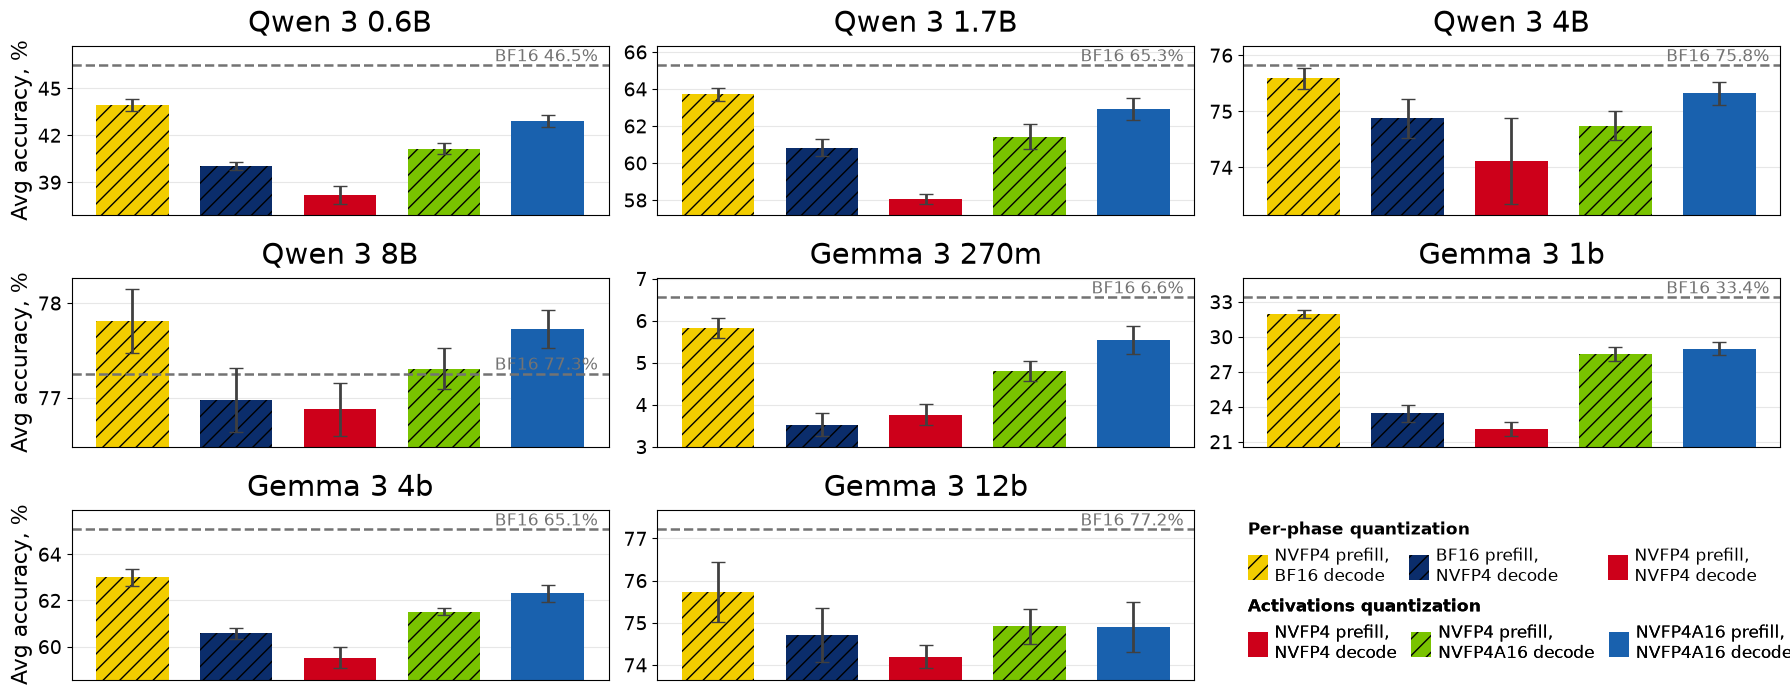

In [33]:
# bars_phase_isolation + bars_disable, FUSED. Both figures answered one question about
# the same five arms and shared a bar (nvfp4) to answer it, so side by side they made a
# reader hold one panel in their head while reading the other.
#
# The clusters ARE the argument, left to right: quantizing one phase at a time shows the
# damage is decode's, and the formats beside it are what that buys -- NVFP4PD keeps
# NVFP4's prefill and NVFP4A16's decode, so it sits between them by construction and the
# question is how close to the right-hand bar it lands.
#
# The ablation pair is deliberately NOT deployable (a BF16 phase needs BF16 weights
# resident, which forfeits the compression) and the heading says so; grouping them with
# the formats would read as five things one might ship.
# Shared specification for every bars_phases counterpart.
_phase_methods = ["nvfp4prefill", "nvfp4decode", "nvfp4", "nvfp4pdshared", "nvfp4a16"]
_phase_labels = ["NVFP4 prefill,\nBF16 decode", "BF16 prefill,\nNVFP4 decode",
                 "NVFP4 prefill,\nNVFP4 decode", "NVFP4 prefill,\nNVFP4A16 decode",
                 "NVFP4A16 prefill,\nNVFP4A16 decode"]
_phase_color_map = {"nvfp4prefill": YELLOW, "nvfp4decode": NAVY,
                    "nvfp4": RED, "nvfp4pdshared": GREEN, "nvfp4a16": BLUE}
_phase_colors = [_phase_color_map[m] for m in _phase_methods]
_phase_sections = [("Per-phase quantization", ["nvfp4prefill", "nvfp4decode", "nvfp4"]),
                   ("Activations quantization", ["nvfp4", "nvfp4pdshared", "nvfp4a16"])]
plot_recovery_bars(_phase_methods,
                   # NVFP4 is keyed under BOTH headings: it is the reference the two
                   # ablations are read against and the first of the three formats. The
                   # bars run without a break for the same reason -- a gap beside the
                   # shared arm would file it under one side.
                   sections=_phase_sections,
                   # Every entry names BOTH phases on TWO lines, homogeneous formats
                   # included. Uniform shape is what keeps the key's rows evenly spaced --
                   # one taller entry pushes everything after it down and the two columns
                   # stop lining up -- and spelling the pair out is the whole point of a
                   # figure about which phase carries which format.
                   labels=_phase_labels, method_to_color=_phase_color_map,
                   hline_annot_left="auto", annotate=False, legend_top=True, legend_stack="v", legend_ncol=3, cluster_gap=0,
                   nrows=3, figsize=(18, 7),
                   outfile="figures/bars_phases_dh.pdf")


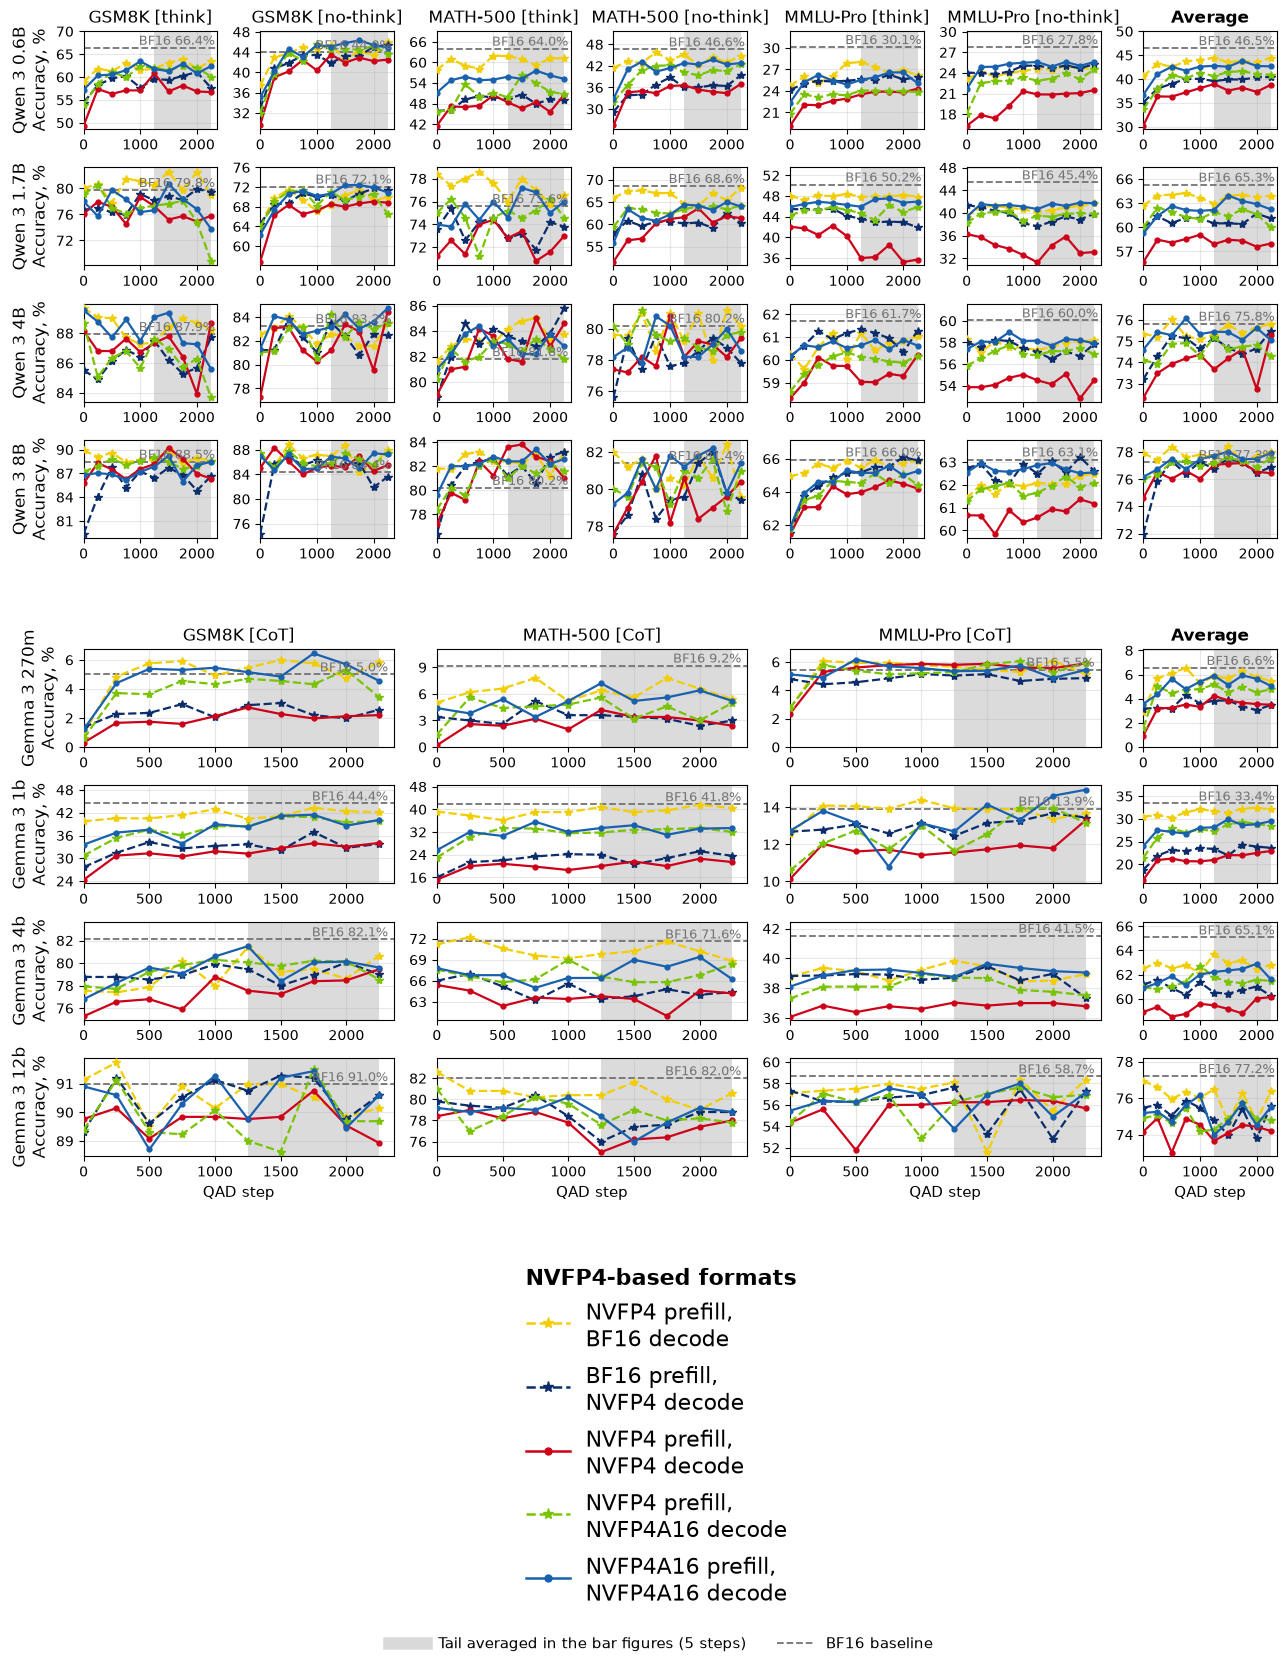

note: Qwen 3 0.6B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen 3 0.6B NVFP4A16 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen 3 1.7B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen 3 1.7B NVFP4A16 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen 3 4B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]'

In [34]:
plot_grid(_phase_methods, labels=_phase_labels, colors=_phase_colors,
          legend_title="NVFP4-based formats",
          outfile="figures/lines_phases_dh.pdf")


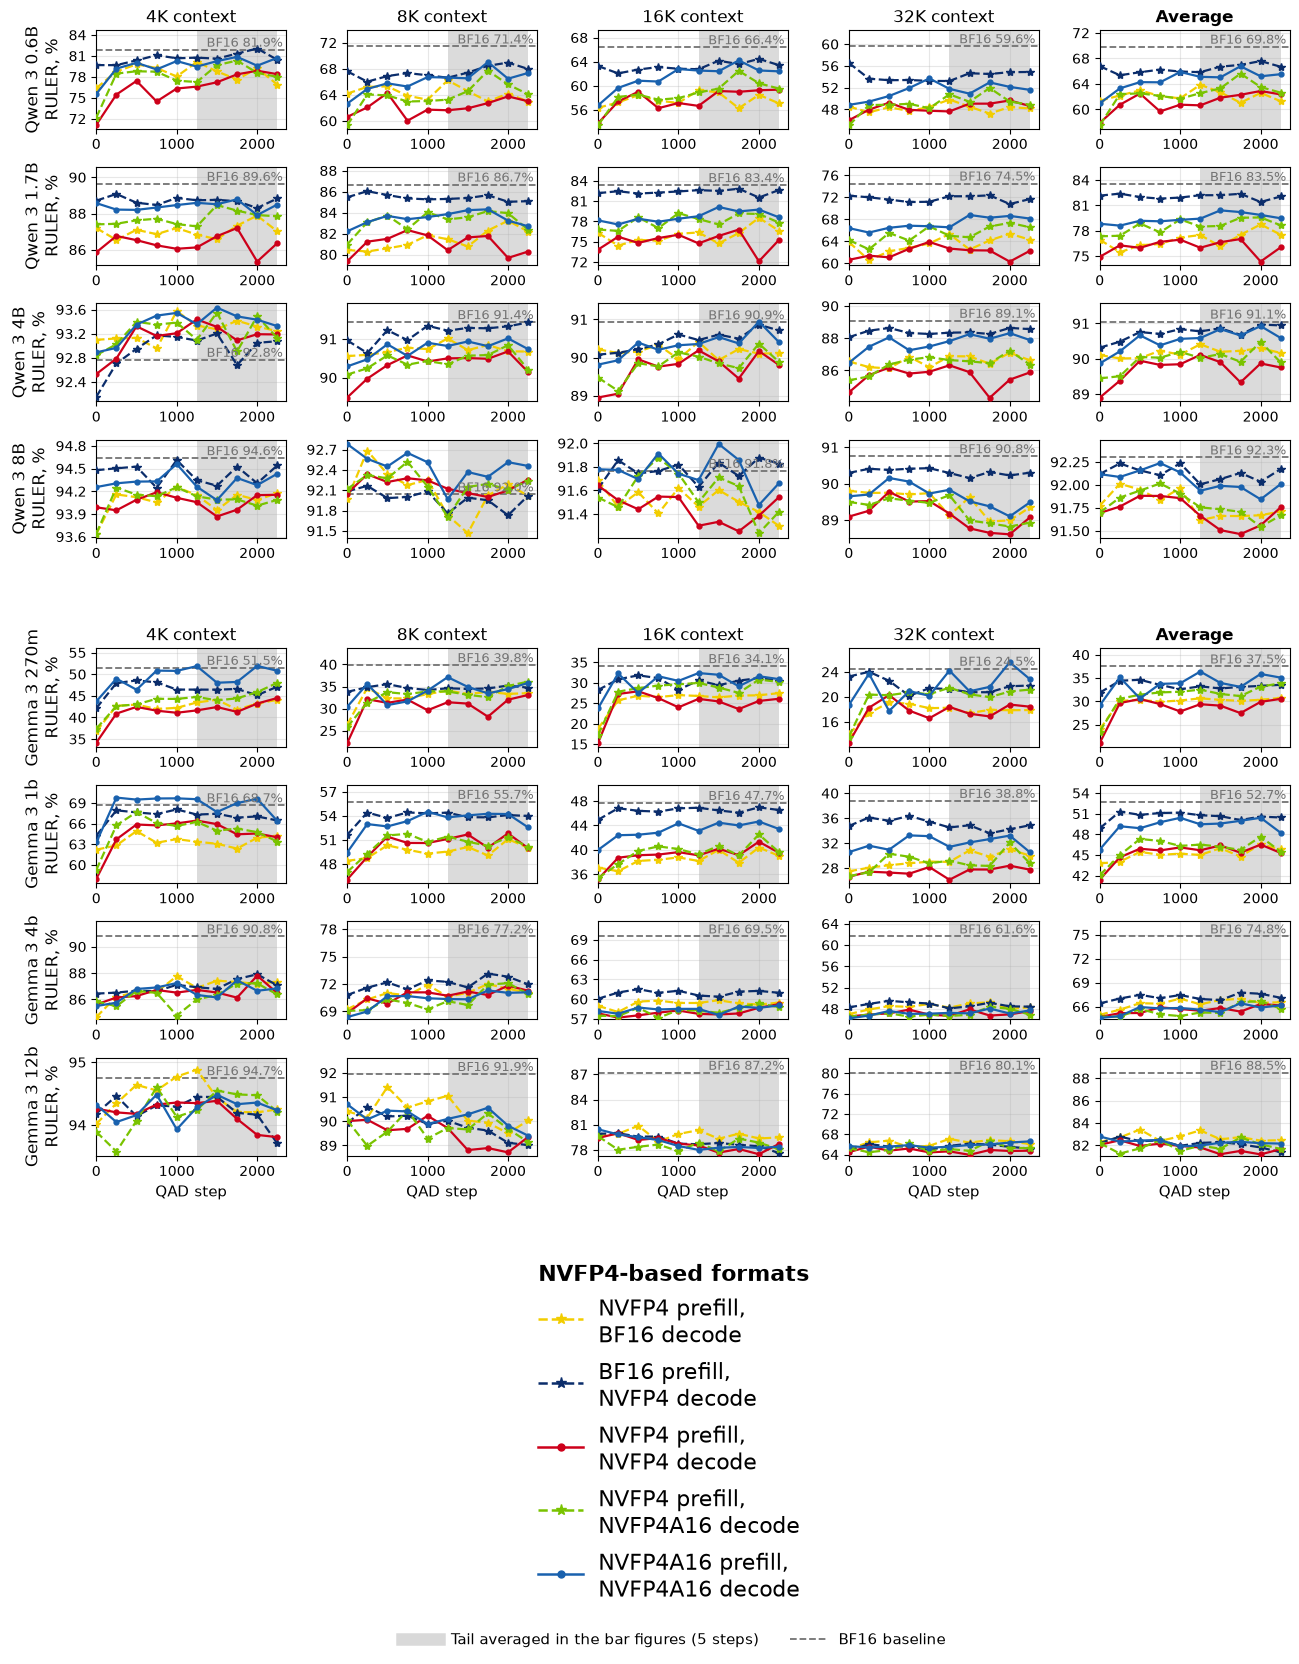

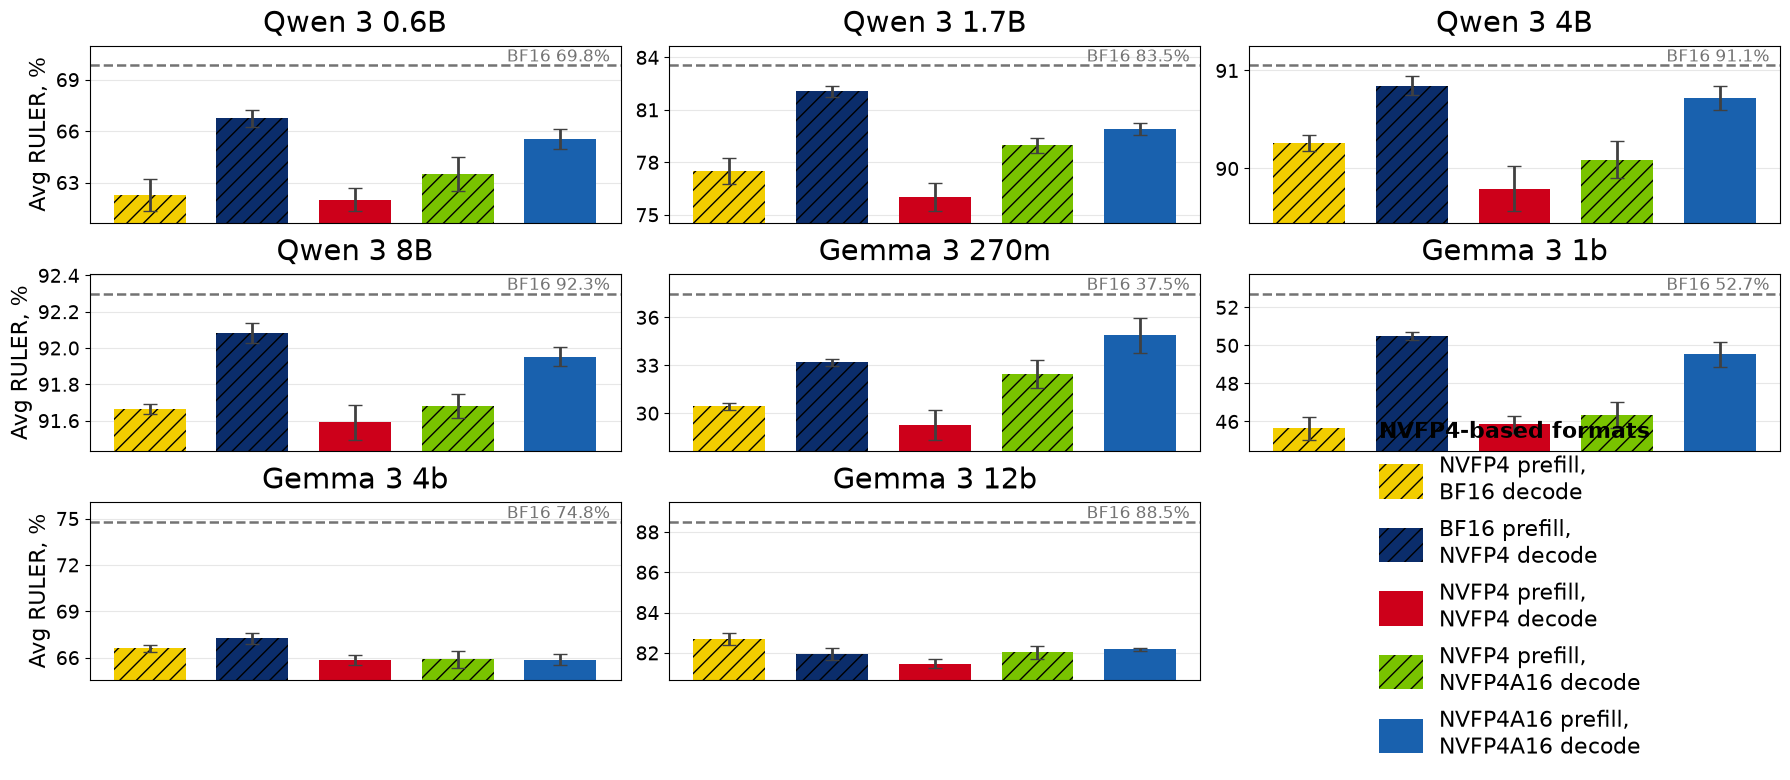

In [35]:
# Prefill-heavy counterparts of lines_phases_dh and bars_phases_dh: the same five formats, labels and colors.
# Formats without RULER evaluations appear once their results arrive.
_ruler_phase_methods = _phase_methods
_ruler_phase_labels = _phase_labels
plot_ruler_grid(_ruler_phase_methods, labels=_ruler_phase_labels, colors=_phase_colors,
                legend_title="NVFP4-based formats", outfile="figures/lines_phases_ph.pdf")
plot_ruler_bars(_ruler_phase_methods, labels=_ruler_phase_labels, colors=_phase_colors,
                legend_title="NVFP4-based formats", annotate=False,
                outfile="figures/bars_phases_ph.pdf")
# Per-length groups retain the same panel layout and format legend:
# plot_ruler_bars(_ruler_phase_methods, labels=_ruler_phase_labels, colors=_phase_colors,
#                 legend_title="NVFP4-based formats", per_length=True, annotate=False)


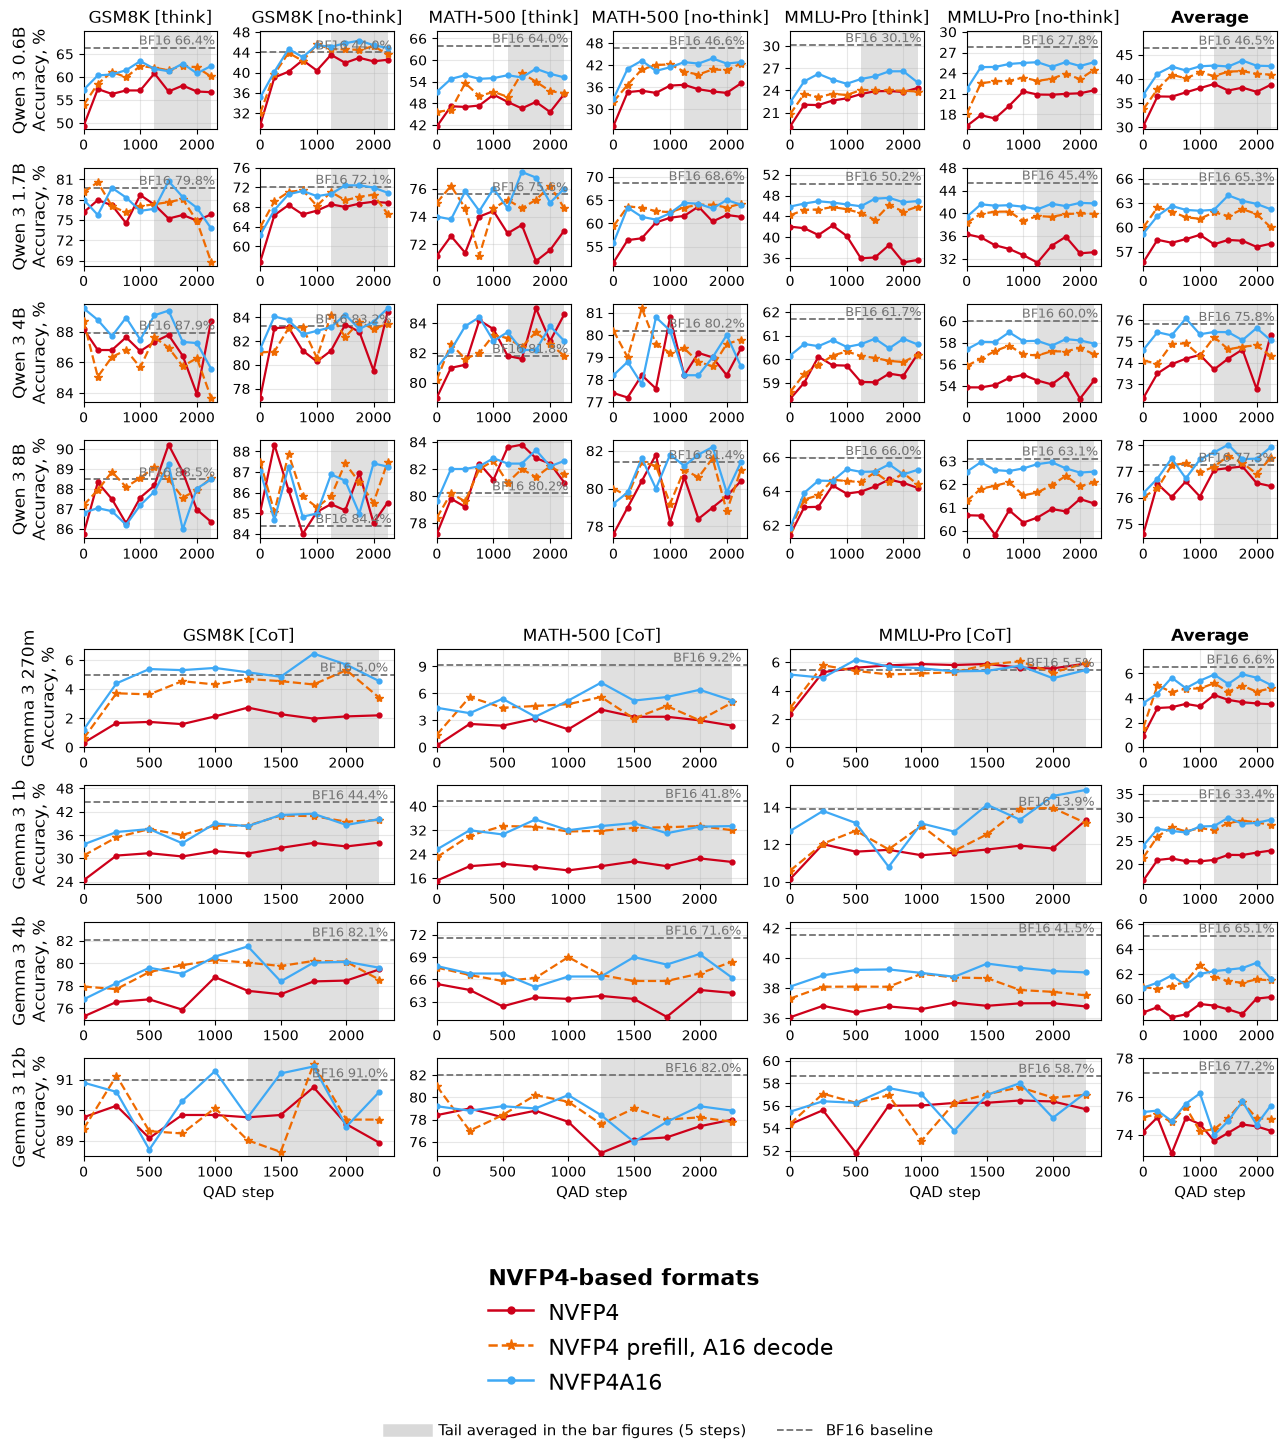

note: Qwen 3 0.6B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen 3 0.6B NVFP4A16 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen 3 1.7B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen 3 1.7B NVFP4A16 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen 3 4B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]'

In [36]:
plot_grid(["nvfp4", "nvfp4pdshared", "nvfp4a16"],
          labels=["NVFP4", "NVFP4 prefill, A16 decode", "NVFP4A16"],
          legend_title="NVFP4-based formats",
          outfile="figures/lines_activation_quantization_dh.pdf")


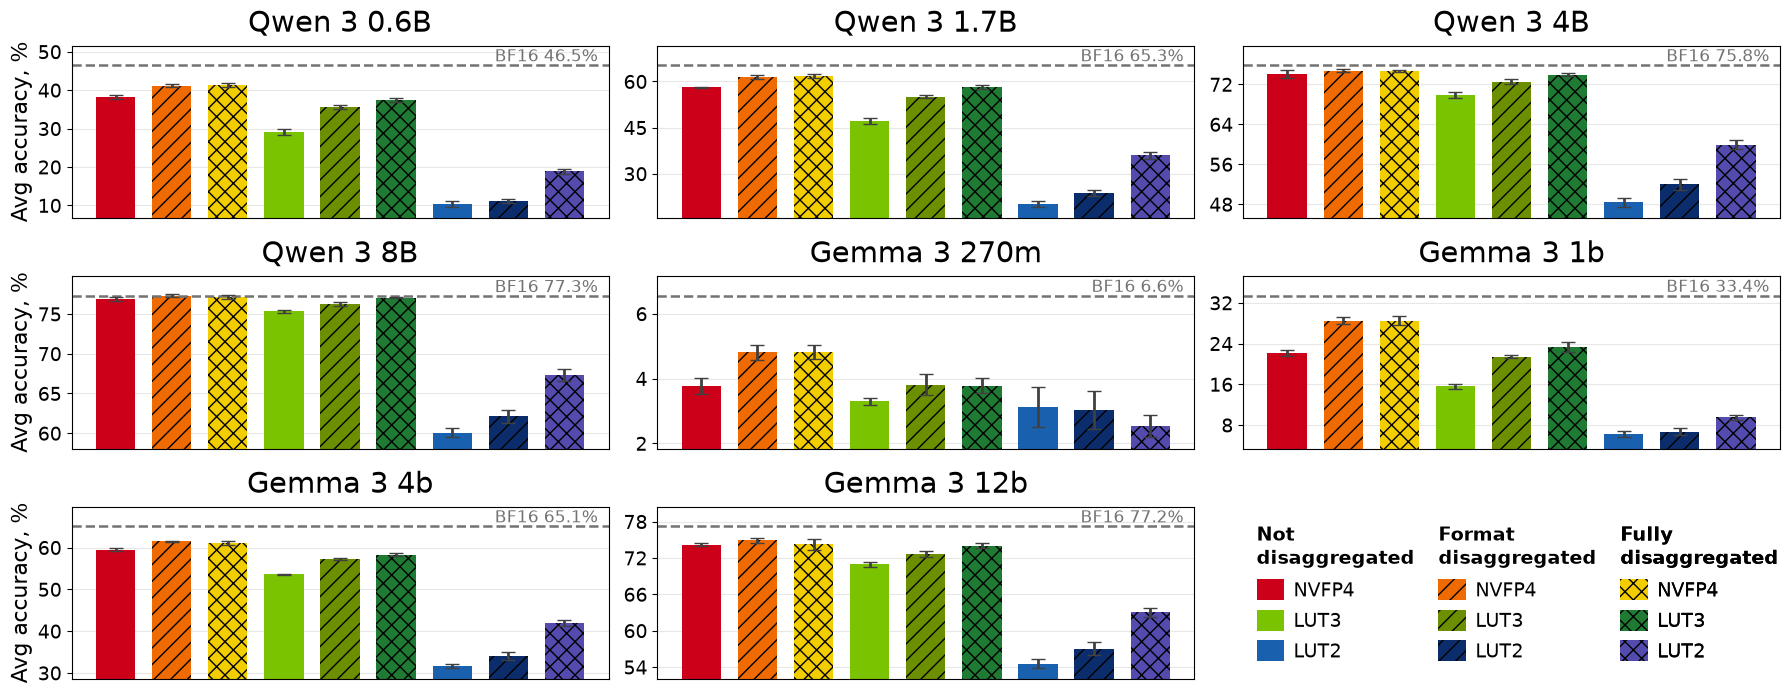

In [37]:
plot_recovery_bars([
        "nvfp4", "nvfp4pdshared", "nvfp4pdsplit",
        "nvfp4lloyd43upcastboth", "nvfp4lloyd43upcast", "nvfp4lloyd43split",
        "nvfp4lloyd21upcastboth", "nvfp4lloyd21upcast", "nvfp4lloyd21split",
    ],
    group_legend=True, annotate=False, nrows=3, figsize=(18, 7),
    outfile="figures/bars_disag_dh.pdf")


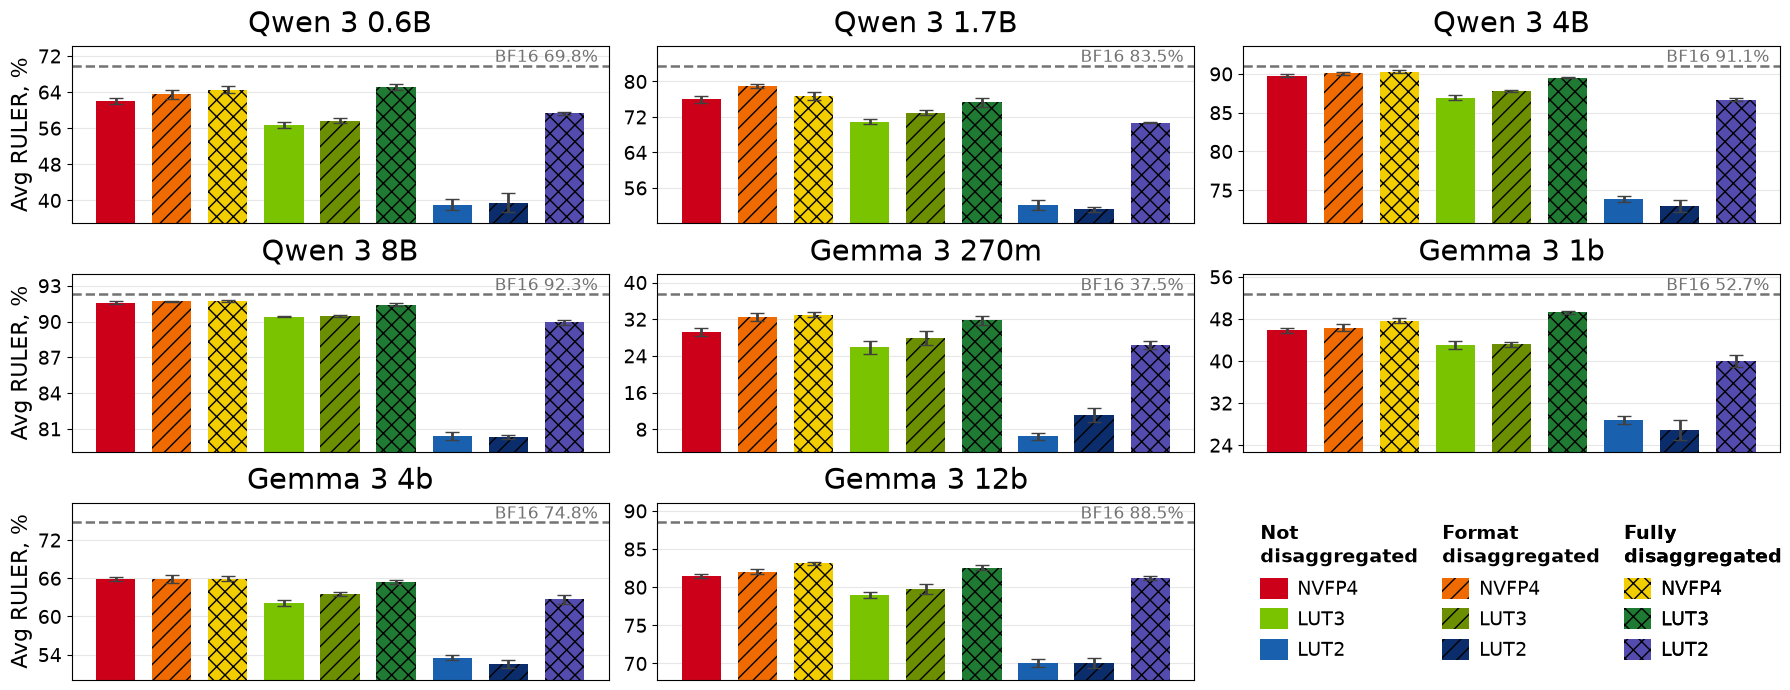

In [38]:
# RULER counterpart of bars_disag: mean over all 13 tasks, then context
# lengths, with the same late-checkpoint averaging and bootstrap errors.
_ruler_disag_methods = [
    "nvfp4", "nvfp4pdshared", "nvfp4pdsplit",
    "nvfp4lloyd43upcastboth", "nvfp4lloyd43upcast", "nvfp4lloyd43split",
    "nvfp4lloyd21upcastboth", "nvfp4lloyd21upcast", "nvfp4lloyd21split",
]
plot_ruler_bars(_ruler_disag_methods,
                group_legend=True, annotate=False, nrows=3, figsize=(18, 7),
                outfile="figures/bars_disag_ph.pdf")


note: the format key is 1.03 panel heights tall and will overrun -- reduce its fontsize, or give the grid a taller panel


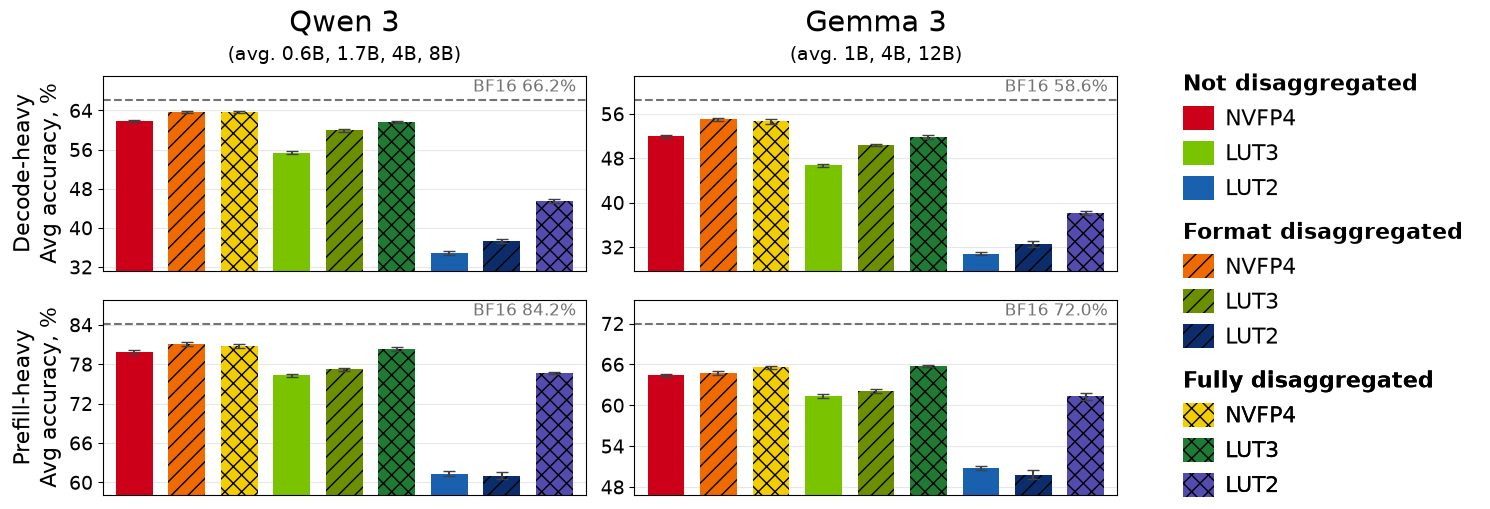

(<Figure size 1500x520 with 5 Axes>,
 array([[<Axes: title={'center': 'Qwen 3'}, ylabel='Decode-heavy\nAvg accuracy, %'>,
         <Axes: title={'center': 'Gemma 3'}>],
        [<Axes: ylabel='Prefill-heavy\nAvg accuracy, %'>, <Axes: >]],
       dtype=object),
 <Axes: >)

In [39]:
# Joint main-paper view: average the existing model bars within each family.
# Keep exactly the same model cohort in both workload rows.
WORKLOAD_FAMILIES = {
    "Qwen 3": ["Qwen-Qwen3-0.6B", "Qwen-Qwen3-1.7B", "Qwen-Qwen3-4B", "Qwen-Qwen3-8B"],
    "Gemma 3": ["google-gemma-3-1b-it", "google-gemma-3-4b-it", "google-gemma-3-12b-it"],
}


def _workload_family_stats(cohort, method, workload, rng, allow_missing=False):
    """Mean of per-model tail means; bootstrap checkpoints within each model."""
    source = ruler_models if workload == "prefill" else models
    if allow_missing and not any(method in source.get(model, {}) for model in cohort):
        return float("nan"), float("nan")  # Entire arm is unavailable.
    means, draws = [], np.zeros(N_BOOT)
    for model in cohort:
        if workload == "prefill":
            curve = ruler_avg_curve(model, ruler_models.get(model, {}).get(method, {}))
        else:
            curve, _ = avg_accuracy(models.get(model, {}).get(method, {}),
                                    baselines.get(model, {}), model)
        steps = [s for s in sorted(curve) if s >= MIN_STEP and s % 250 == 0][-TAIL_N:]
        if len(steps) != TAIL_N:
            if allow_missing:
                print(f"note: {workload}: {model} {method} has {len(steps)}/{TAIL_N} "
                      "complete tail checkpoints; marking the family bar TODO")
                return float("nan"), float("nan")
            raise ValueError(f"{workload}: {model} {method} has {len(steps)}/{TAIL_N} "
                             "complete tail checkpoints; refusing a partial family mean")
        values = np.asarray([curve[s] for s in steps])
        means.append(values.mean())
        draws += rng.choice(values, size=(N_BOOT, TAIL_N), replace=True).mean(axis=1)
    # Do not bootstrap model identities: the fixed cohort is the reported population.
    return float(np.mean(means)), float(2 * (draws / len(cohort)).std(ddof=0))


def _workload_family_baseline(cohort, workload):
    values = []
    for model in cohort:
        if workload == "prefill":
            lengths = ruler_lengths_for(model)
            baseline = ruler_baselines.get(model, {})
            if not lengths or any(L not in baseline for L in lengths):
                return None  # Never compare a full cohort against a partial BF16 mean.
            values.append(np.mean([baseline[L] for L in lengths]))
        else:
            value = _bl_avg(baselines.get(model, {}), model)
            if value is None:
                return None
            values.append(value)
    return float(np.mean(values))


def plot_workload_bars(methods, outfile=None, scale=1.0, annotate=False,
                       figsize=None, ylim=None, labels=None, sections=None,
                       method_to_color=None, allow_missing=True, legend_fontsize=16):
    """Two workload rows, two family columns, one double-height legend column.

    Scores match equal-weight averages of the existing per-model bars. Error bars
    are twice the bootstrap std of that family mean, independently resampling
    late checkpoints within each model; they are not across-training-run intervals.
    Custom labels and legend sections also support phase-isolation comparisons.
    allow_missing marks absent or incomplete family bars with a red TODO,
    without averaging partial cohorts or shorter checkpoint tails.
    """
    assert methods and all(m in METHODS for m in methods)
    if labels is not None:
        assert len(labels) == len(methods), "One label is required per method"
    label_of = dict(zip(methods, labels)) if labels is not None else {
        m: METHODS[m][0] for m in methods}
    color_of = {m: METHODS[m][1] for m in methods}
    if method_to_color is not None:
        color_of.update(method_to_color)
    if sections is None:
        assert all(m in DISAG for m in methods), "Provide sections for phase ablations"
        sections = [(title, [m for m in methods if DISAG[m] == degree])
                    for degree, title in DISAG_LABEL.items()]
    assert set(methods) == {m for _, group in sections for m in group}, (
        "Legend sections must cover exactly the plotted methods")
    F = lambda pt: pt * scale
    rng = np.random.default_rng(BOOT_SEED)
    # Resolve complete family means or TODO placeholders before constructing the figure.
    stats, refs = {}, {}
    for workload in ("decode", "prefill"):
        for family, cohort in WORKLOAD_FAMILIES.items():
            stats[workload, family] = [
                _workload_family_stats(cohort, method, workload, rng, allow_missing)
                for method in methods]
            refs[workload, family] = _workload_family_baseline(cohort, workload)
    fig = plt.figure(figsize=figsize or (15 * scale, 5.2 * scale))
    grid = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.65])
    axes = np.array([[fig.add_subplot(grid[r, c]) for c in range(2)] for r in range(2)])
    legend_ax = fig.add_subplot(grid[:, 2])
    legend_ax.axis("off")
    xs = np.arange(len(methods))
    for r, (workload, row_label) in enumerate([
            ("decode", "Decode-heavy"), ("prefill", "Prefill-heavy")]):
        for c, family in enumerate(WORKLOAD_FAMILIES):
            ax = axes[r, c]
            means, errors = np.asarray(stats[workload, family]).T
            valid = np.isfinite(means) & np.isfinite(errors)
            if not valid.any() and not allow_missing:
                raise ValueError(f"No complete arms for {workload}, {family}")
            present = [m for m, ok in zip(methods, valid) if ok]
            ax.bar(xs[valid], means[valid], width=0.7,
                   color=[color_of[m] for m in present],
                   hatch=[_HATCH.get(METHODS[m][2], "") for m in present],
                   yerr=errors[valid], capsize=F(4),
                   error_kw=dict(elinewidth=F(1.5), ecolor="0.25"))
            ax.set_xlim(-0.6, len(methods) - 0.4)
            for x in xs[~valid]:
                ax.text(x, 0.03, "TODO", transform=ax.get_xaxis_transform(),
                        ha="center", va="bottom", color="red", fontsize=F(12))
                print(f"note: {row_label}, {family}: {methods[x]} has incomplete or missing results")
            if annotate:
                for x, mean, err in zip(xs[valid], means[valid], errors[valid]):
                    ax.annotate(f"{mean:.1f}", (x, mean + err), ha="center",
                                va="bottom", fontsize=F(12), fontweight="bold")
            bounds = list(means[valid] - errors[valid]) + list(means[valid] + errors[valid])
            baseline = refs[workload, family]
            if baseline is not None:
                bounds.append(baseline)
                ax.axhline(baseline, ls="--", color="0.45", lw=F(1.5))
                ax.annotate(f"BF16 {baseline:.1f}%", (0.98, baseline),
                            xycoords=("axes fraction", "data"), xytext=(0, F(3)),
                            textcoords="offset points", ha="right", va="bottom",
                            fontsize=F(12), color="0.45")
            else:
                print(f"note: {row_label}, {family}: incomplete BF16 cohort; "
                      "reference line omitted")
            if not bounds:
                bounds = [0.0, 100.0]  # A panel may contain only TODOs and no BF16 baseline.
            pad = (0.16 if annotate else 0.10) * max(max(bounds) - min(bounds), 1.0)
            ax.set_ylim(*(ylim if ylim is not None else
                          (max(0, min(bounds) - pad), max(bounds) + pad)))
            ax.set_xticks([])
            ax.tick_params(axis="y", labelsize=F(14))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5, integer=True))
            ax.grid(True, axis="y", alpha=0.3)
            ax.set_axisbelow(True)
            if r == 0:
                ax.set_title(family, fontsize=F(21), pad=F(32))
                sizes = ", ".join(f"{_size(model):g}B"
                                  for model in WORKLOAD_FAMILIES[family])
                subtitle = ax.annotate(f"(avg. {sizes})", (0.5, 1.0),
                                       xycoords="axes fraction", xytext=(0, F(8)),
                                       textcoords="offset points", ha="center",
                                       va="bottom", fontsize=F(14))
                subtitle.set_gid("family-subtitle")
            if c == 0:
                ax.set_ylabel(f"{row_label}\nAvg accuracy, %", fontsize=F(16))
    legs = _format_legend(legend_ax, methods, color_of.get,
                          label_of.get, True, None, F,
                          stack="v", valign="upper", y=1.0, fontsize=legend_fontsize,
                          sections=sections)
    for leg in legs:
        leg.borderaxespad = 0  # Align measured boxes with their placement anchors.
        leg.set_in_layout(False)
    fig.tight_layout()
    fig.canvas.draw()
    boxes = [leg.get_window_extent().transformed(legend_ax.transAxes.inverted())
             for leg in legs]
    # Spread the groups over the full-height column, retaining outer margins.
    text_height = sum(box.height for box in boxes)
    gap = max(0.03, (0.94 - text_height) / max(len(legs) - 1, 1))
    height = text_height + gap * (len(legs) - 1)
    _center_legends(legend_ax, legs, y=(1 + height) / 2, vertical=True, gap=gap)

    # Keep BF16/value labels within the per-panel zoomed axes after layout.
    if ylim is None:
        fig.canvas.draw()
        for ax in axes.flat:
            box = ax.get_window_extent()
            overflow = max([t.get_window_extent().y1 - box.y1 for t in ax.texts
                            if t.get_gid() != "family-subtitle"] + [-F(4)])
            if overflow > -F(2):
                lo, hi = ax.get_ylim()
                ax.set_ylim(lo, hi + (overflow + F(4)) * (hi - lo) / box.height)
    if outfile:
        fig.savefig(outfile, bbox_inches="tight", transparent=True)
    plt.show()
    return fig, axes, legend_ax


plot_workload_bars(_ruler_disag_methods, outfile="figures/bars_disag_both.pdf")


note: the format key is 1.02 panel heights tall and will overrun -- reduce its fontsize, or give the grid a taller panel


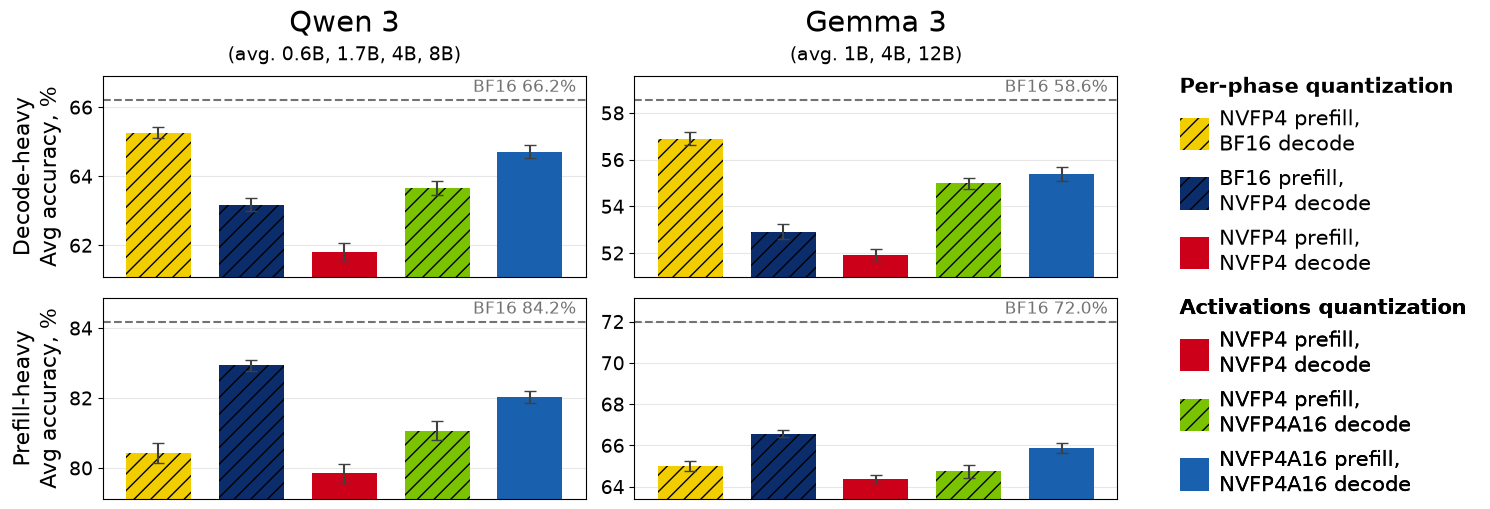

(<Figure size 1500x520 with 5 Axes>,
 array([[<Axes: title={'center': 'Qwen 3'}, ylabel='Decode-heavy\nAvg accuracy, %'>,
         <Axes: title={'center': 'Gemma 3'}>],
        [<Axes: ylabel='Prefill-heavy\nAvg accuracy, %'>, <Axes: >]],
       dtype=object),
 <Axes: >)

In [40]:
# Common bars_phases: phase isolation AND activation-quantization comparisons.
# Reuse the bars_phases specification, including its shared NVFP4 legend entry.
plot_workload_bars(
    _phase_methods, labels=_phase_labels, sections=_phase_sections,
    method_to_color=_phase_color_map,
    allow_missing=True, legend_fontsize=15,
    outfile="figures/bars_phases_both.pdf")


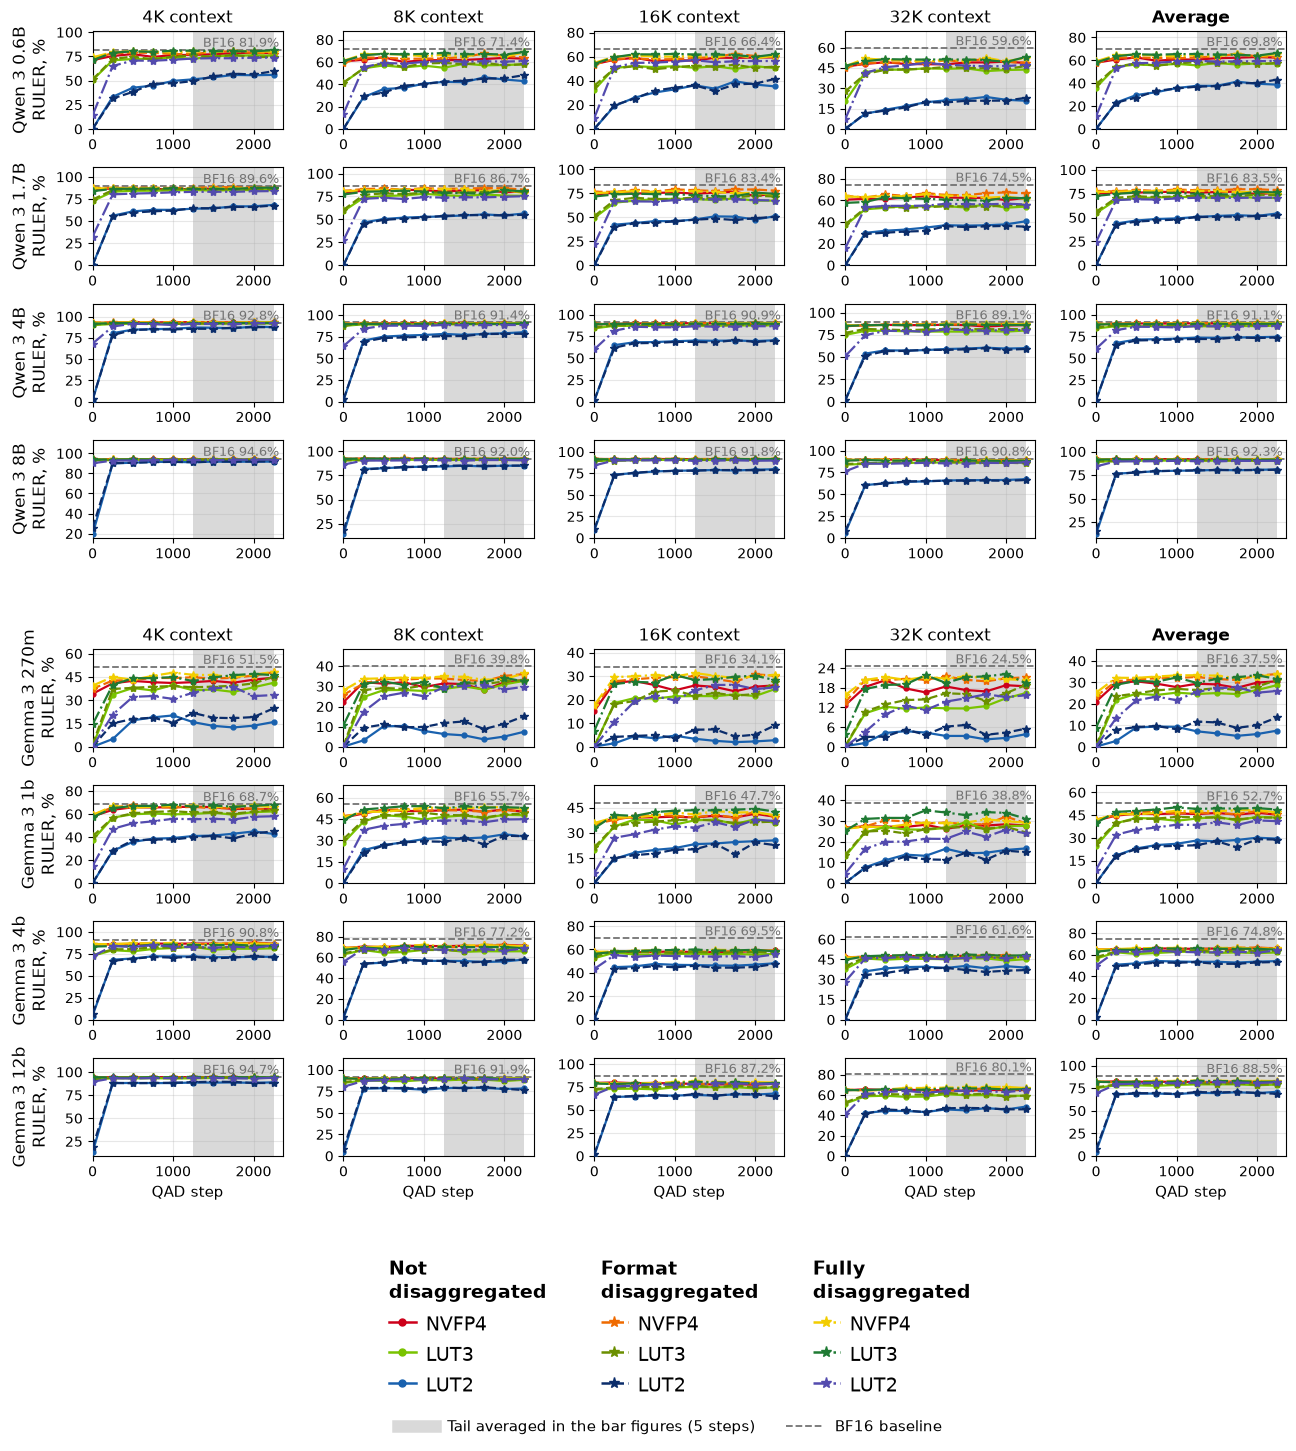

In [41]:
# RULER DQ ladder: one column per context length plus
# their average; each point averages the complete 13-task suite.
plot_ruler_grid(_ruler_disag_methods, group_legend=True,
                outfile="figures/lines_disag_ph.pdf")


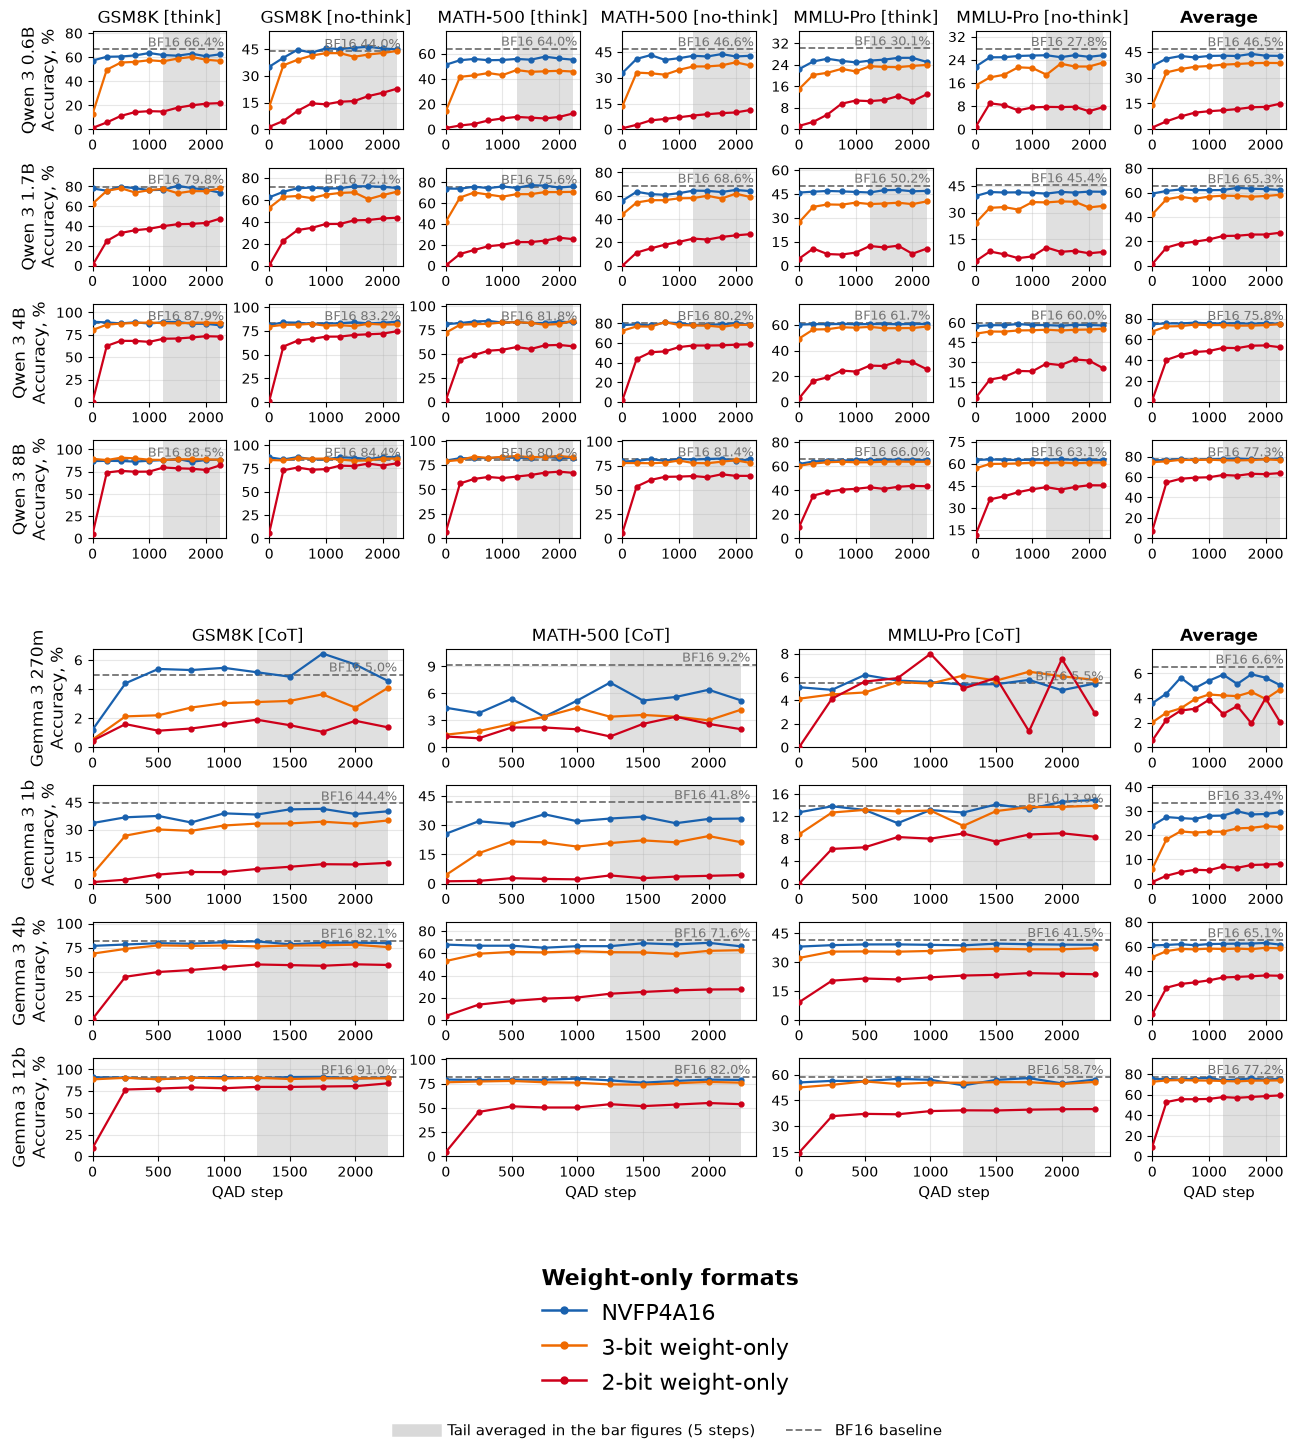

note: Qwen 3 0.6B NVFP4A16 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen 3 1.7B NVFP4A16 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen 3 4B NVFP4A16 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])


In [42]:
# Shared weight-only specification for decode-heavy and prefill-heavy curves.
_weight_only_methods = ["nvfp4a16", "lloyd43", "lloyd21"]
_weight_only_labels = ["NVFP4A16", "3-bit weight-only", "2-bit weight-only"]
_weight_only_colors = [BLUE, ORANGE, RED]  # Color denotes bitwidth, not format family.
plot_grid(_weight_only_methods, labels=_weight_only_labels, colors=_weight_only_colors,
          legend_title="Weight-only formats",
          outfile="figures/lines_weight_only_dh.pdf")


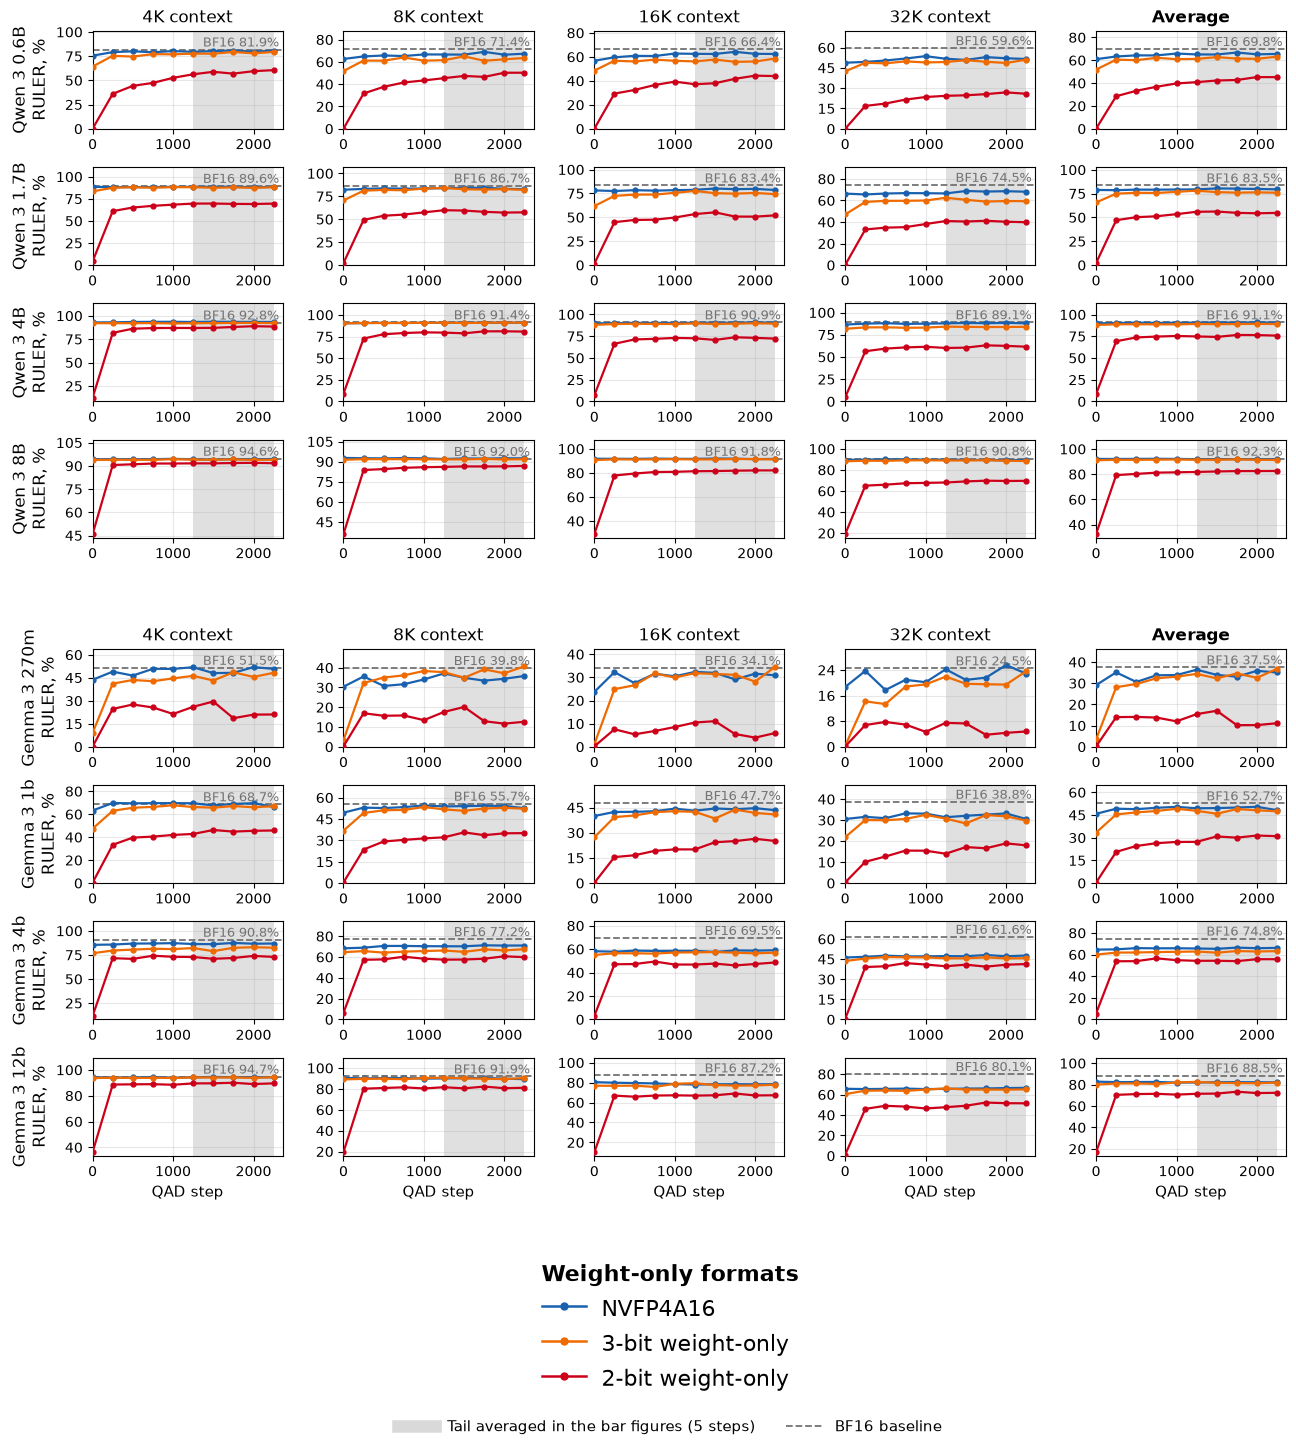

In [43]:
# RULER counterpart: retained context lengths and their mean (64K excluded by the loader).
# Plot available formats now; include the others automatically as evaluations arrive.
if any(method in ruler_found for method in _weight_only_methods):
    plot_ruler_grid(_weight_only_methods, labels=_weight_only_labels,
                    colors=_weight_only_colors, legend_title="Weight-only formats",
                    outfile="figures/lines_weight_only_ph.pdf")
else:
    print("Skipping lines_weight_only_ph: no weight-only RULER results available yet.")


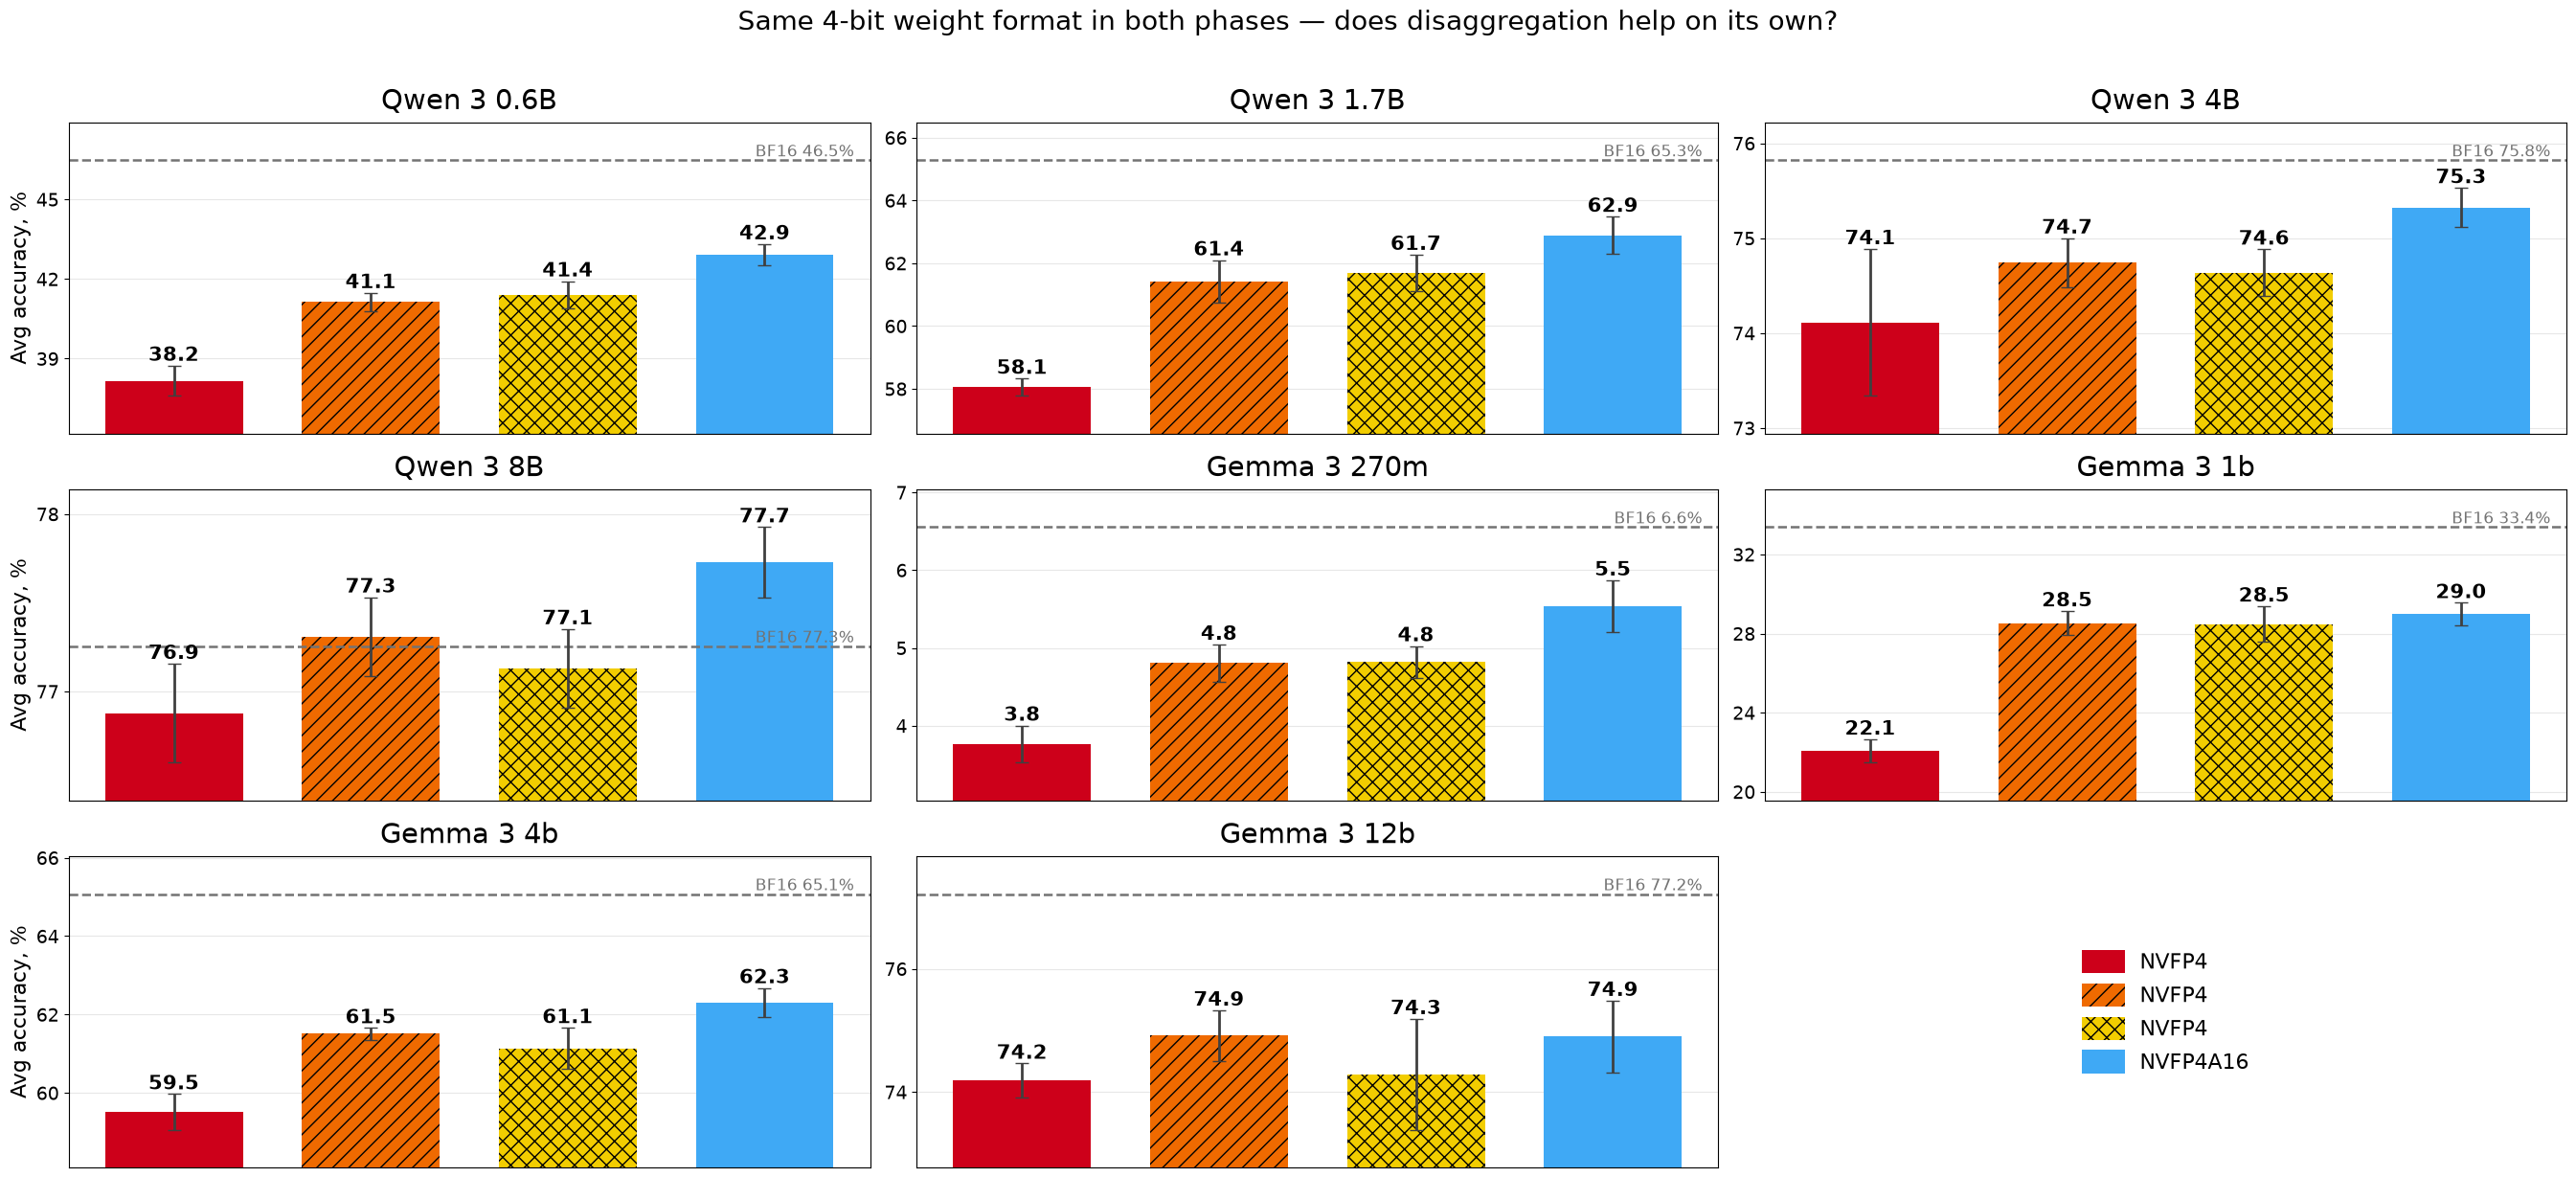

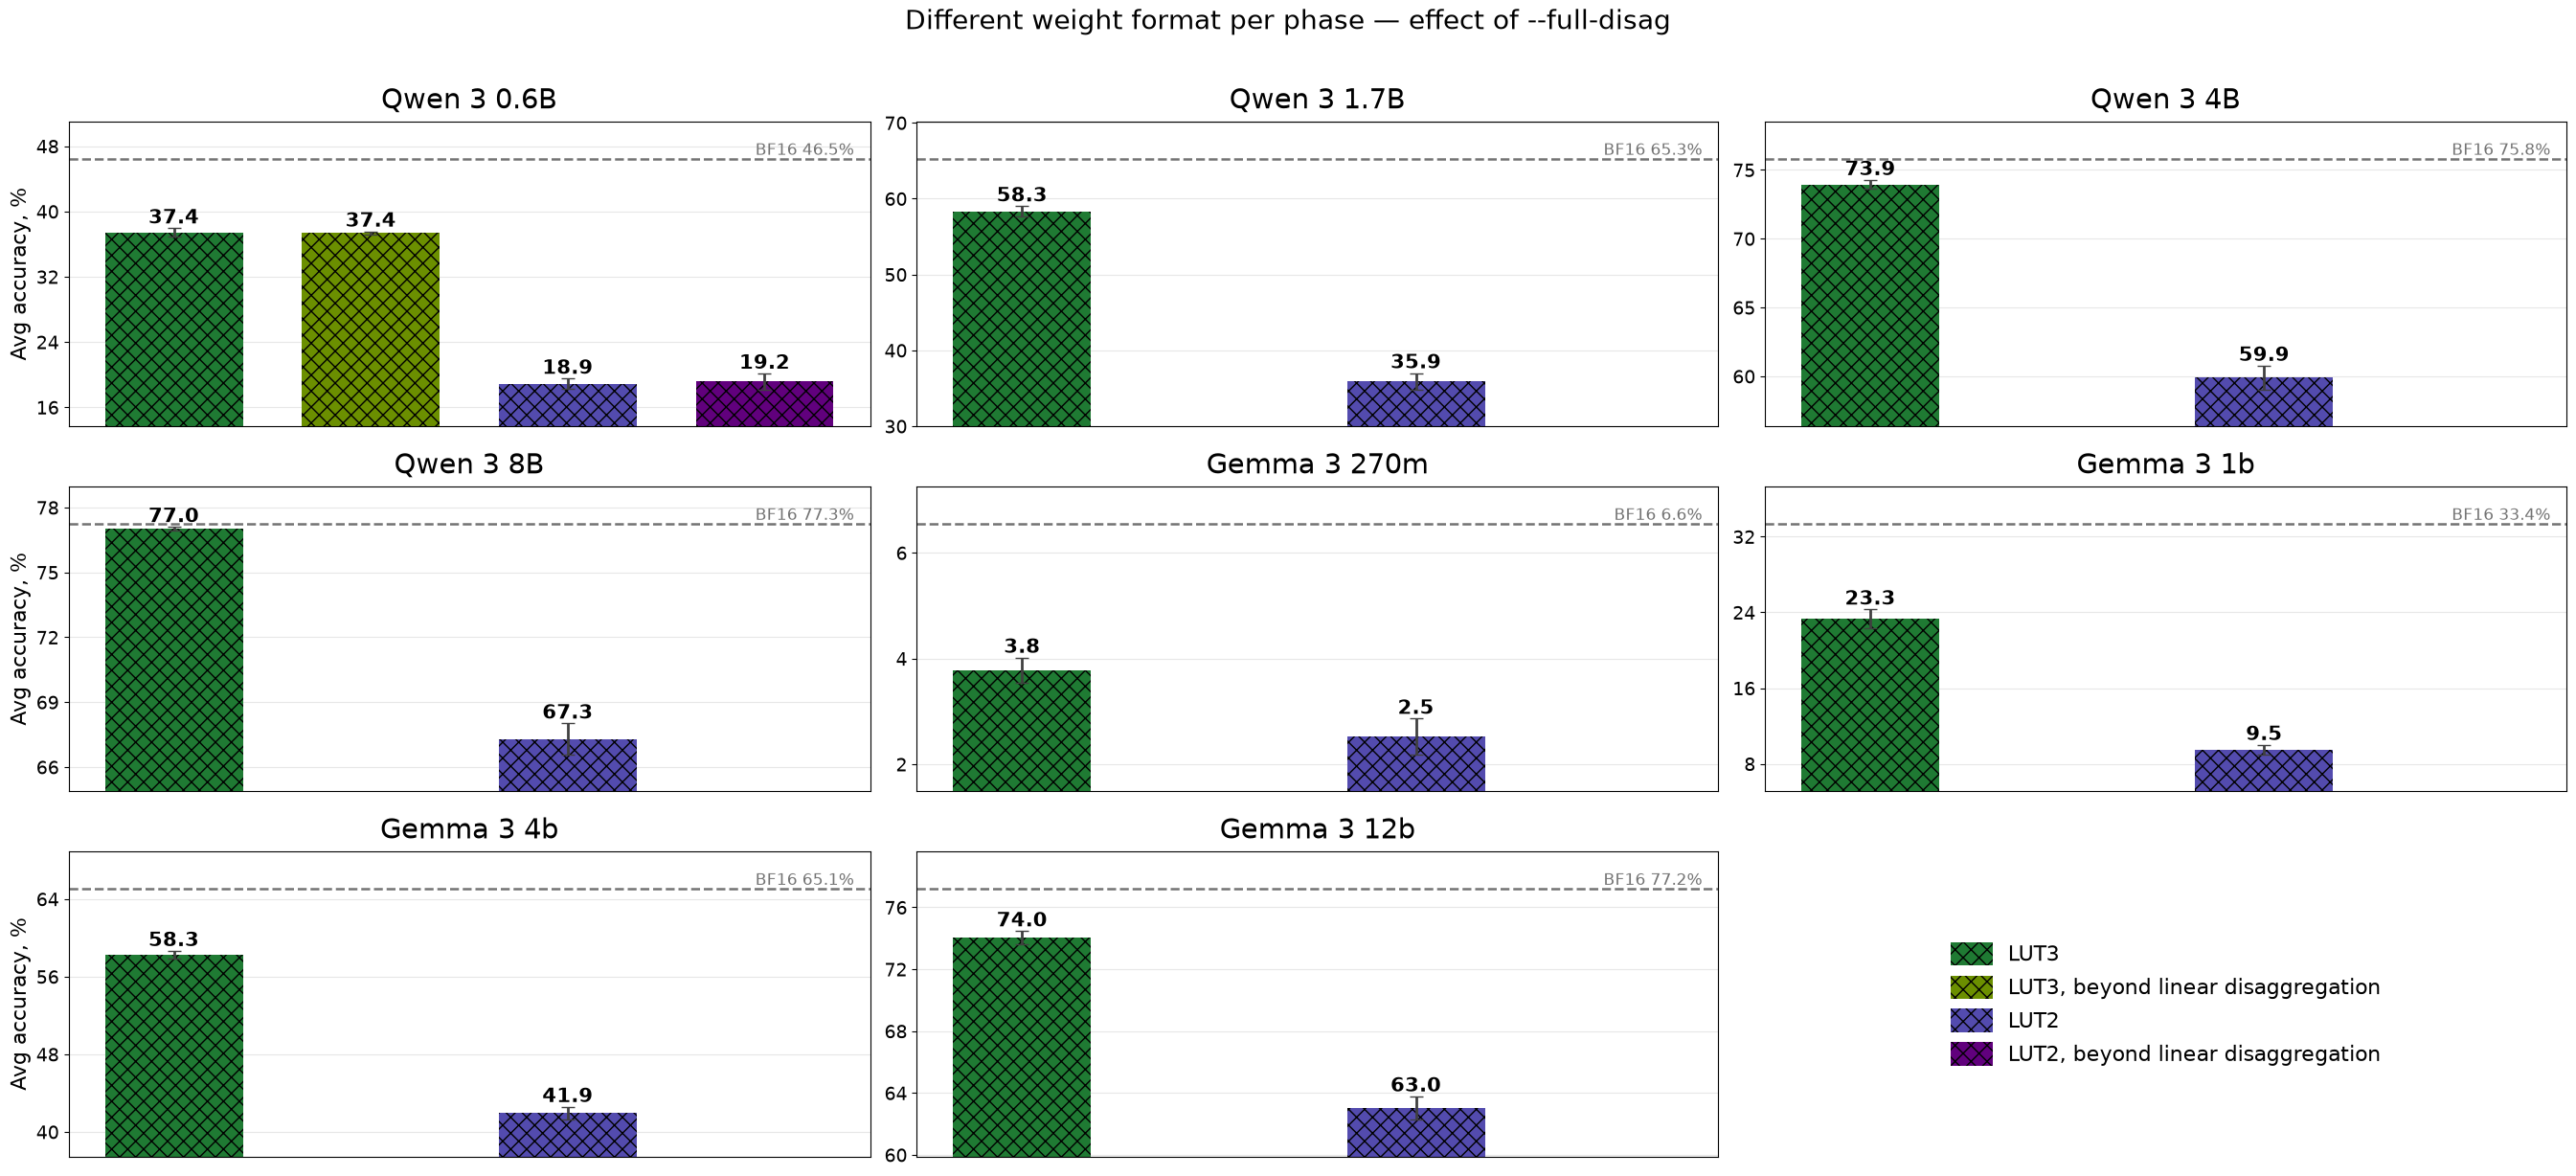

In [44]:
# DISAGGREGATION ABLATION -- two questions, same bar figure as every other slide.
#
# (1) SAME weight format in both phases. Every arm below stores 4-bit NVFP4 weights on both
#     sides, so disaggregation cannot be buying a bitwidth difference: the only thing it
#     changes is that the decode half stops quantizing ACTIVATIONS (W4A4 -> W4A16), and the
#     split arm additionally gives each phase its own master. This is the control for "is
#     disag worth anything when prefill is not higher precision". nvfp4 and nvfp4a16 bracket
#     it -- always quantize activations, never quantize them -- so if the disag arms land on
#     nvfp4a16 the win is the activation precision, not the disaggregation.
plot_recovery_bars(["nvfp4", "nvfp4pdshared", "nvfp4pdsplit", "nvfp4a16"], nrows=3,
                   suptitle="Same 4-bit weight format in both phases — "
                            "does disaggregation help on its own?")

# (2) DIFFERENT weight format per phase, and whether --full-disag adds anything on top.
#     Each pair keeps its plain arm's colour (colour = decode-side precision, which the flag
#     does not change) and differs by hatch: // = disaggregated linears, xx = also dual
#     embedding, norms and LM head.
plot_recovery_bars([
    "nvfp4lloyd43split", "nvfp4lloyd43split-a9264ff4",
    "nvfp4lloyd21split", "nvfp4lloyd21split-a9264ff4",
    ],nrows=3,
suptitle="Different weight format per phase — effect of --full-disag")


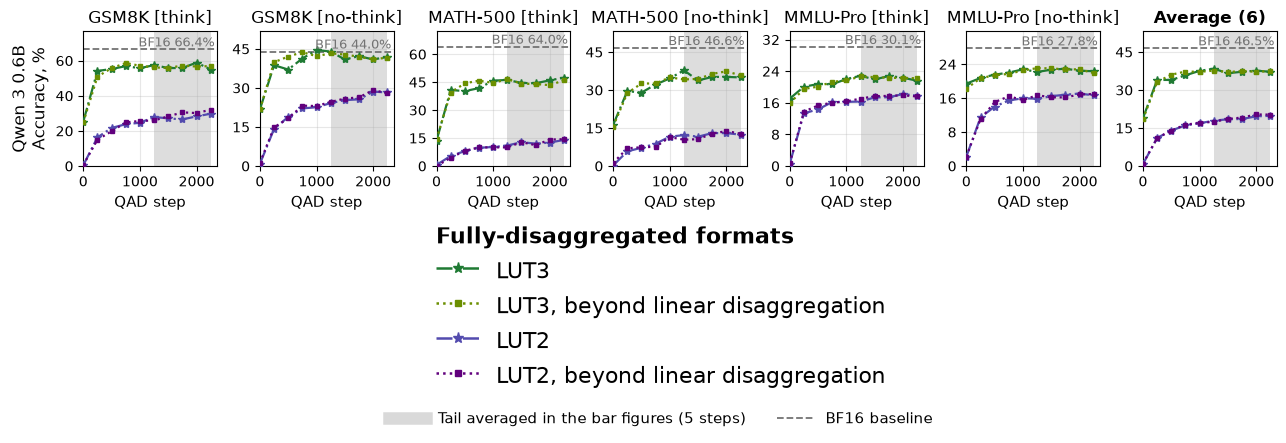

In [45]:
# EFFECT OF --full-disag, per benchmark and per QAD step (Qwen3-0.6B only).
#
# The bar version above reduces each arm to its tail mean, which is what the claim rests on;
# this is the curve behind that number. One model, because the flag's effect is a small,
# format-dependent shift and reading it needs the whole trajectory rather than eight rows of
# it -- and because 0.6B is where a second master weight is proportionally the largest bet.
#
# Each pair shares a family and differs only in the flag: "non-linear disaggregation" also makes the
# embedding, the norms and the LM head dual, so the two checkpoints share nothing but the
# architecture. Grouping by disaggregation degree is off -- every arm here is fully
# disaggregated, so the group headers would say the same thing four times.
plot_grid(["nvfp4lloyd43split", "nvfp4lloyd43split-a9264ff4",
           "nvfp4lloyd21split", "nvfp4lloyd21split-a9264ff4"],
          subset=["Qwen-Qwen3-0.6B"],
          legend_title="Fully-disaggregated formats",
          outfile="figures/lines_non_linear_disag_dh.pdf")


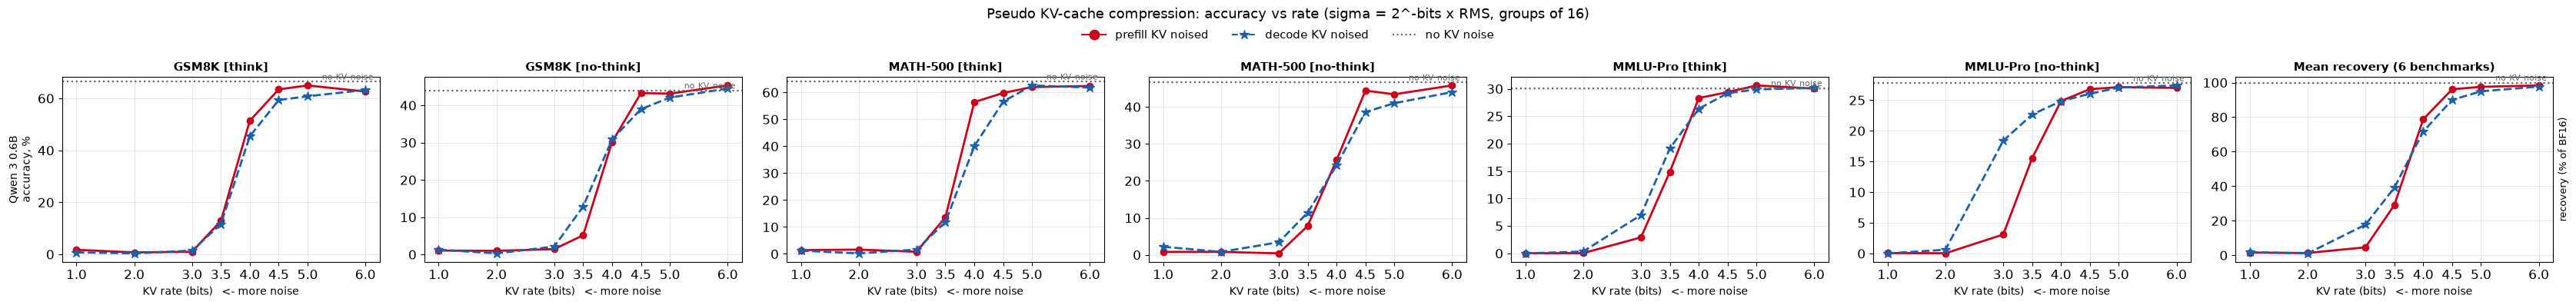

In [46]:
# KV-CACHE COMPRESSION SWEEP: accuracy vs rate, prefill-noise against decode-noise.
#
# Pseudo-compression (qad/kv_noise_connector.py): a token's K/V is degraded ONCE as it is
# written to the paged cache, by N(0, sigma^2) per contiguous group of 16 channels, with
#     sigma = 2^-kv_bits * RMS(group)
# so 4^-kv_bits of distortion POWER -- Shannon's D(R) for a Gaussian source. Lower bits =
# more noise. The right-hand end of each x axis is therefore the *gentle* end.
#
# Two arms, run on ONE BF16 checkpoint, so nothing here is confounded by training:
#   kvP  prefill engine noised, decode untouched  -> cost of compressing PROMPT KV
#   kvD  decode engine noised, prefill untouched  -> cost of compressing GENERATED KV
#
# READ THE ARMS WITH CARE. On these benchmarks prompts are long and generations short, so
# at equal rate the prefill arm degrades far MORE KV entries than the decode arm. A flat
# kvD curve therefore does not by itself show that decode KV is robust -- it may mean
# there was little of it to damage. The comparison is only fair per KV entry.
#
# Note also that the cache stores POST-RoPE keys (qwen3.py applies rotary_emb before
# self.attn writes the cache), so both arms perturb rotated keys -- which is what a real
# KV codec compresses.
import glob as _glob

KV_RE_PLOT = __import__("re").compile(
    r"Qwen3-([0-9.]+B)-unquantized-kv([pd])(\d+(?:\.\d+)?)$")
KV_ARMS = {"p": ("prefill KV noised", RED, "-", "o"),
           "d": ("decode KV noised", BLUE, "--", "*")}


def _load_kv_sweep():
    """{(model, arm, bits, task@mode): accuracy} straight from the results trees.

    Read separately from `models` because these runs are not checkpoints: one BF16 model
    at several rates, tagged ...-kvp<bits> / -kvd<bits>, with no quantizer or step.
    """
    out = {}
    for mode, tree in (("think", "results/disagg/think"),
                       ("nothink", "results/disagg/nothink")):
        for d in _glob.glob(f"../qad/{tree}/*-unquantized-kv*"):
            m = KV_RE_PLOT.search(d.rstrip("/").split("/")[-1])
            if not m:
                continue
            model, arm, bits = f"Qwen-Qwen3-{m.group(1)}", m.group(2), float(m.group(3))
            for f in _glob.glob(f"{d}/step_*.json"):
                try:
                    res = json.load(open(f)).get("results", {})
                except Exception:
                    continue
                for task, (_, key) in BENCHMARKS.items():
                    if task in res and key in res[task]:
                        out[(model, arm, bits, f"{task}@{mode}")] = 100.0 * res[task][key]
    return out


def plot_kv_sweep(outfile=None, scale=1.0):
    """One row per model; columns = benchmarks then mean recovery, x = kv_bits."""
    data = _load_kv_sweep()
    if not data:
        print("no KV-noise results on disk yet (looking for *-unquantized-kv[pd]<bits>)")
        return
    kv_models = sorted({k[0] for k in data}, key=_size)
    panels = tasks + [AVG]
    F = lambda pt: pt * scale
    fig, axes = plt.subplots(len(kv_models), len(panels),
                             figsize=(4.8 * len(panels) * scale, 3.7 * len(kv_models) * scale),
                             squeeze=False)
    for i, model in enumerate(kv_models):
        bl_all = baselines.get(model, {})
        for j, panel in enumerate(panels):
            ax = axes[i][j]
            for arm, (label, color, ls, mk) in KV_ARMS.items():
                bits = sorted({k[2] for k in data if k[0] == model and k[1] == arm})
                xs, ys = [], []
                for b in bits:
                    if panel == AVG:
                        # mean RECOVERY over the benchmarks, same definition as
                        # avg_recovery(): only rates where EVERY benchmark reported.
                        vals = [data.get((model, arm, b, t)) for t in tasks]
                        if any(v is None for v in vals) or not all(bl_all.get(t) for t in tasks):
                            continue
                        ys.append(sum(v / bl_all[t] for v, t in zip(vals, tasks))
                                  / len(tasks) * 100.0)
                    else:
                        v = data.get((model, arm, b, panel))
                        if v is None:
                            continue
                        ys.append(v)
                    xs.append(b)
                if xs:
                    ax.plot(xs, ys, marker=mk, markersize=F(9 if mk == "*" else 6),
                            linestyle=ls, linewidth=F(2.0), color=color, label=label)
            # uncompressed reference: 100% recovery by construction, or the raw baseline
            bl = 100.0 if panel == AVG else bl_all.get(panel)
            if bl is not None:
                ax.axhline(bl, ls=":", color="0.4", linewidth=F(1.6))
                ax.annotate("no KV noise", xy=(0.98, bl), xycoords=("axes fraction", "data"),
                            ha="right", va="bottom", fontsize=F(8), color="0.4")
            if i == 0:
                ax.set_title("Mean recovery (6 benchmarks)" if panel == AVG
                             else TASKS[panel][0], fontweight="bold", fontsize=F(11))
            if j == 0:
                ax.set_ylabel(short_name(model) + "\naccuracy, %", fontsize=F(10))
            if panel == AVG:
                ax.set_ylabel("recovery (% of BF16)", fontsize=F(9))
                ax.yaxis.set_label_position("right")
            if i == len(kv_models) - 1:
                ax.set_xlabel("KV rate (bits)   <- more noise", fontsize=F(10))
            ax.set_xticks(sorted({k[2] for k in data if k[0] == model}))
            ax.grid(True, alpha=0.3)
            ax.set_axisbelow(True)
    handles = [plt.Line2D([], [], color=c, ls=ls, marker=mk, markersize=F(9), label=lab)
               for lab, c, ls, mk in KV_ARMS.values()]
    handles.append(plt.Line2D([], [], color="0.4", ls=":", label="no KV noise"))
    fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=F(11),
               frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle("Pseudo KV-cache compression: accuracy vs rate "
                 "(sigma = 2^-bits x RMS, groups of 16)", fontsize=F(13), y=1.06)
    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()


plot_kv_sweep()


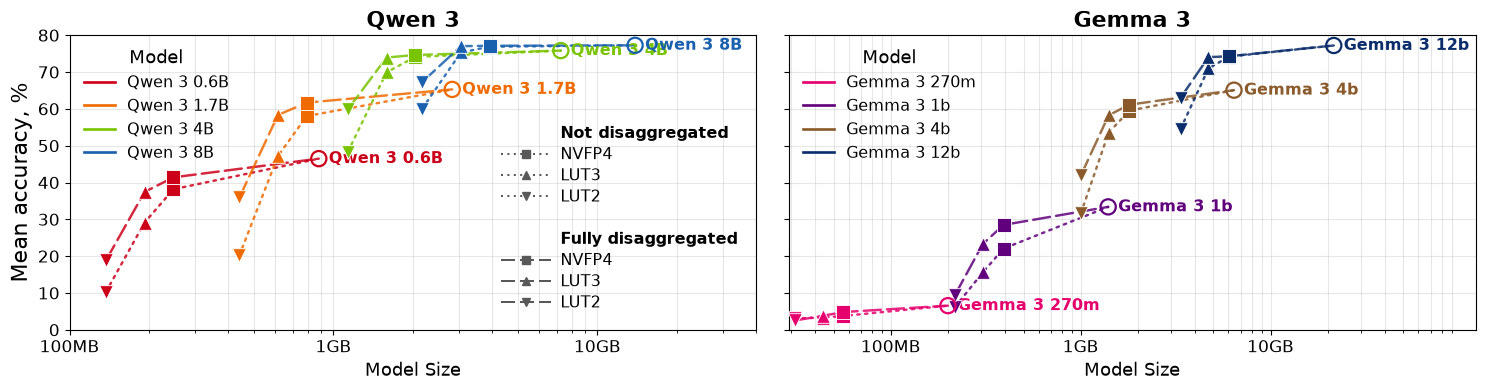

In [47]:
# PARETO: decode-side weight footprint vs accuracy.
#
# The question every one of these formats is really answering: for a given number of
# GIGABYTES you must hold resident to decode, how much accuracy do you get? Decode is the
# memory-bound phase, so its weight footprint is the deployment cost -- and a 2-bit 8B may
# beat a 4-bit 4B at the same size, which is invisible in any per-model figure.
#
# EXCLUDES embeddings and lm_head, which are not quantized by any of these formats (they
# would add a constant to every point and compress the interesting differences). Sizes are
# the DECODE half only; the prefill checkpoint is a separate residency question.
#
# HONESTY ABOUT THE X AXIS. This is the size a deployable kernel WOULD use, not the size on
# disk: the Lloyd/LUT formats ship pseudo-quantized (bf16 weights, no 2/3-bit kernel
# exists), so their bars are what such a kernel would cost, not what we measured. NVFP4
# numbers are real. Block scales are included at 8 bits per group of 16 (+0.5 bits/weight)
# because a deployed cache pays for them.
import numpy as _np

# Non-embedding linear parameters, from each config: L*(q+k+v+o) + L*3*i*h.
LINEAR_PARAMS = {"Qwen-Qwen3-0.6B": 0.440e9, "Qwen-Qwen3-1.7B": 1.409e9,
                 "Qwen-Qwen3-4B":   3.633e9, "Qwen-Qwen3-8B":   6.946e9,
                 # Gemma-3, same formula: L*(q+k+v+o) + L*3*i*h, head_dim 256 at every
                 # size. Text stack only -- the 4b/12b vision tower is neither trained nor
                 # exported, so counting it would inflate the x axis by ~0.4B/~1.2B.
                 "google-gemma-3-270m-it":  0.100e9, "google-gemma-3-1b-it":   0.698e9,
                 "google-gemma-3-4b-it":    3.209e9, "google-gemma-3-12b-it": 10.758e9}

# Bits per weight the DECODE half stores. The prefill half may differ -- that is the whole
# point of the disaggregated formats -- and is deliberately not counted here.
DECODE_BITS = {
    "nvfp4": 4, "nvfp4lloyd43upcastboth": 3, "nvfp4lloyd21upcastboth": 2,
    # "nvfp4lloyd21upcast": 2, "nvfp4lloyd43upcast": 3, "nvfp4pdshared": 4,
    "nvfp4lloyd21split": 2, "nvfp4lloyd43split": 3, "nvfp4pdsplit": 4,
}
SCALE_BITS_PER_WEIGHT = 8 / 16       # one FP8 block scale per 16 weights


def decode_gb(model, method):
    bits = DECODE_BITS[method] + (SCALE_BITS_PER_WEIGHT if DECODE_BITS[method] < 16 else 0)
    return LINEAR_PARAMS[model] * bits / 8 / 1e9


def tail_accuracy(model, method, task_subset=None, models_src=None, baselines_src=None):
    """Mean RAW accuracy over the given tasks (defaults to all plotted tasks), last-5 steps.

    Raw accuracy, not recovery, because the y axis has to be comparable ACROSS models --
    recovery is normalised per model and would put every model's BF16 at 100%, hiding
    exactly the size/quality trade this figure exists to show.
    """
    # Defaults to the columns THIS model can have, not the global list: with a
    # think-only family in the grid, defaulting to `tasks` makes every Gemma point
    # return None and the family vanishes from the Pareto without a warning.
    _tasks = task_subset if task_subset is not None else tasks_for(model)
    _msrc = models_src if models_src is not None else models
    vals = []
    for t in _tasks:
        curve = _msrc.get(model, {}).get(method, {}).get(t)
        if not curve:
            return None
        steps = [s for s in sorted(curve) if s >= MIN_STEP and s % 250 == 0][-TAIL_N:]
        if not steps:
            return None
        # NOT *100: the loader already stores accuracy in percent (baselines are
        # 66.4, not 0.664), and double-scaling put the quantized points at ~6000%
        # while the BF16 references collapsed onto the axis.
        vals.append(sum(curve[s] for s in steps) / len(steps))
    return sum(vals) / len(vals)


# Colour now identifies the MODEL and marker identifies the FORMAT, which is the pairing
# this figure needs: the question is whether a compressed big model beats an uncompressed
# small one, so the eye has to group by model first. That is the opposite of the per-model
# figures, where colour is the method -- deliberately, because there every panel IS one
# model and colour is free to carry the format.
MODEL_COLOUR = {"Qwen-Qwen3-0.6B": RED, "Qwen-Qwen3-1.7B": ORANGE,
                "Qwen-Qwen3-4B": GREEN, "Qwen-Qwen3-8B": BLUE,
                "google-gemma-3-270m-it": PINK, "google-gemma-3-1b-it": PURPLE,
                "google-gemma-3-4b-it": BROWN, "google-gemma-3-12b-it": NAVY}
# Distinct shapes, ordered so the families read together: circles = homogeneous,
# triangles/diamonds = duals, squares = LUT.
# MARKER = DECODE BIT-WIDTH, LINESTYLE = FAMILY. The two axes of this figure are "how
# small is the decode weight" and "how did you get there", so each visual channel carries
# exactly one of them. Same-bitwidth formats therefore share a marker: LUT2, NVFP4/LUT2
# and NVFP4+LUT2 are all triangles, and it is the line through them that says which
# family they belong to.
BITS_MARKER = {2: "v", 3: "^", 4: "s"}


def _marker(method):
    if method in REFERENCE:
        return "o"                       # the reference is deliberately its own shape
    return BITS_MARKER.get(DECODE_BITS.get(method), "o")


# Straight off the shared DISAG table: these chains and the bar legend's sections are the
# same three groups, and a local copy of the mapping is how they would drift apart.
def _family(method):
    return DISAG.get(method)


# Dash patterns are explicit and widely spaced: the default "--" and ":" are hard to
# tell apart at print size under the alpha these chains are drawn with.
FAMILY_LS = {"none":   (0, (1, 2.2)),      # fine dots
             "format": "solid",
             "full":   (0, (7, 2.5))}           # long dashes
# Drawn in black at reduced size, outside all families and both colour keys.
REFERENCE = {}

# Panels that omit the (panel-invariant) format legend. Add a family here to reclaim the
# space; the per-panel MODEL legend is always drawn.
NO_FORMAT_LEGEND = {"gemma3"}

def plot_pareto(methods=None, outfile=None, scale=1.0, annotate_bf16=True,
               task_subset=None, models_src=None, baselines_src=None):
    """Pareto of decode memory vs accuracy.

    task_subset: list of task keys (e.g. ["minerva_math500@think"]) to use instead of
        the full `tasks` list. Defaults to all plotted tasks.
    """
    # Left as None so tail_accuracy() can resolve it PER MODEL (see there).
    _tasks = task_subset
    _msrc = models_src if models_src is not None else models
    _bsrc = baselines_src if baselines_src is not None else baselines
    methods = [m for m in (methods or PLOT_METHODS) if m in found and m in DECODE_BITS]
    F = lambda pt: pt * scale
    # ONE SUBPLOT PER MODEL FAMILY, side by side. Qwen3 and Gemma-3 share neither axis,
    # deliberately: their accuracy ranges barely overlap (gemma-3-270m sits near the floor
    # while Qwen3-8B is near the top) and their decode footprints differ by an order of
    # magnitude, so a shared axis squeezes both families into unreadable corners. A shared
    # axis would also imply the two are directly comparable, and they are not -- the
    # Average is over a per-family task set (Gemma is think-only), so the plotted y
    # quantity itself differs between panels. Each panel therefore carries its own full
    # legend instead of one figure-level legend.
    mfams = [f for f in ("qad3x", "gemma3")
             if any(family_of(m) == f and m in LINEAR_PARAMS for m in PARETO_ORDER)]
    fig, axes = plt.subplots(1, len(mfams), figsize=(9.5 * len(mfams) * scale, 5.0 * scale),
                             squeeze=False, sharex=False, sharey=True)
    axes = axes[0]

    for ax, mfam in zip(axes, mfams):
        for model in PARETO_ORDER:
            if family_of(model) != mfam:
                continue
            if model not in LINEAR_PARAMS:
                continue
            # Resolve the task set PER MODEL. A single global list makes every point of a
            # think-only family return None AND drops its BF16 anchor, so the family would
            # silently disappear from the Pareto rather than plot short.
            _mtasks = _tasks if _tasks is not None else tasks_for(model)
            colour = MODEL_COLOUR.get(model, "0.4")
            short = short_name(model)
            chains = {fam: [] for fam in FAMILY_LS}
            for method in methods:
                acc = tail_accuracy(model, method, _mtasks, models_src=_msrc)
                if acc is None:
                    continue
                x = decode_gb(model, method)
                fam = _family(method)
                if fam:
                    chains[fam].append((x, acc))
                if method in REFERENCE:
                    ax.scatter([x], [acc], s=F(34), c="black", marker="o", zorder=5)
                else:
                    ax.scatter([x], [acc], s=F(120), c=colour,
                               marker=_marker(method),
                               edgecolors="white", linewidths=F(0.8), zorder=3)
            bl = _bsrc.get(model, {})
            if annotate_bf16 and all(bl.get(t) for t in _mtasks):
                xb = LINEAR_PARAMS[model] * 16 / 8 / 1e9
                yb = sum(bl[t] for t in _mtasks) / len(_mtasks)
                # BF16 anchors BOTH chains: it is the uncompressed origin of each family.
                for c in chains.values():
                    c.append((xb, yb))
                ax.scatter([xb], [yb], s=F(150), facecolors="none", edgecolors=colour,
                           linewidths=F(2.0), zorder=4)
                ax.annotate(short, (xb, yb), textcoords="offset points",
                            xytext=(F(9), F(-4)), fontsize=F(14), fontweight="bold",
                            color=colour)
            for fam, chain in chains.items():
                if len(chain) > 1:
                    chain.sort()
                    ax.plot([c[0] for c in chain], [c[1] for c in chain], color=colour,
                            ls=FAMILY_LS[fam], lw=F(2.2), alpha=0.85, zorder=1,
                            solid_capstyle="round", dash_capstyle="round")

        ax.set_xscale("log")
        # Explicit decade ticks in human units. matplotlib's default log labels here are
        # 10^0 / 10^1, which reads as "1" and "10" with no unit and hides that the left half
        # of the figure is in the hundreds of MB.
        if ax == axes[0]:
            ax.set_xlim(0.1, 40.0)
        else:
            ax.set_xlim(0.029, 120.0)
        ax.set_ylim(0, 80)
        ax.set_xticks([0.1, 1.0, 10.0])
        ax.set_xticklabels(["100MB", "1GB", "10GB"])
        ax.xaxis.set_minor_formatter(plt.NullFormatter())
        ax.set_xlabel("Model Size", fontsize=F(16))
        # Y-axis label. `_tasks` is None unless the caller pinned a subset, because the task
        # set is resolved per model above -- so the label must be derived the same way. With
        # more than one family in the figure the rows do NOT average the same number of
        # benchmarks, so only state a count when it is actually uniform rather than quoting
        # one family's count over a mixed figure.
        if _tasks is not None and len(_tasks) == 1:
            task_label = BENCHMARKS[_tasks[0].split("@")[0]][0]
        else:
            _ns = {len(_tasks if _tasks is not None else tasks_for(m))
                   for m in PARETO_ORDER if m in LINEAR_PARAMS}
            task_label = (f"{_ns.pop()} benchmarks" if len(_ns) == 1
                          else "per-model benchmark set")
        if ax == axes[0]:
            ax.set_ylabel(f"Mean accuracy, %", fontsize=F(20))
        ax.grid(True, which="both", alpha=0.3)
        ax.set_axisbelow(True)
        ax.set_title({"qad3x": "Qwen 3", "gemma3": "Gemma 3"}[mfam],
                     fontsize=F(20), fontweight="bold")

        # ONE format legend, with the group names as inert rows inside it. Three stacked
        # legends each own their own text column, so the labels never line up with each
        # other; a single legend has one handle column and one text column, which is what
        # makes the entries align horizontally. The group headers are handles with no marker
        # and no line -- they occupy the handle column invisibly and read as section titles.
        def _handle(q):
            if q is None:
                return plt.Line2D([], [], color="0.35", ls="none", marker="o",
                                  markerfacecolor="none", markersize=F(8), label="BF16")
            if q in REFERENCE:
                return plt.Line2D([], [], color="black", ls="none", marker="o",
                                  markersize=F(5), label=METHODS[q][0])
            return plt.Line2D([], [], color="0.35", ls=FAMILY_LS.get(_family(q), "none"),
                              lw=F(1.8), marker=_marker(q),
                              markersize=F(8), label=METHODS[q][0])

        def _header(text):
            return plt.Line2D([], [], ls="none", marker="none", label=text)

        groups = [(title, [m for m in methods
                           if _family(m) == key or (key == "none" and m in REFERENCE)])
                  for key, title in DISAG_LABEL.items()]
        handles = []
        for i, (title, qs) in enumerate(groups):
            if not qs:
                continue
            if i:
                handles.append(_header(" "))        # blank row between sections
            handles.append(_header(title))
            handles += [_handle(q) for q in qs]
        # handlelength matters here: the default sample is too short to show a dash pattern,
        # so the upcast (solid) and disaggregated (long-dash) sections looked identical in the
        # legend even though the chains on the figure are clearly different.
        # The format legend is identical in every panel -- same methods, same markers, same
        # linestyles -- so drawing it twice spends a third of each panel restating one key.
        # It is kept on the Qwen3 panel and dropped on Gemma-3, where the curves climb into
        # the lower-right corner the legend occupies. The MODEL legend stays on BOTH,
        # because that one genuinely differs per panel.
        if mfam not in NO_FORMAT_LEGEND:
            leg = ax.legend(handles=handles, fontsize=F(14), frameon=False,
                            loc="lower right", labelspacing=0.35, handletextpad=0.6,
                            borderaxespad=0.8, handlelength=3.2)
            # Bold the section titles so they read as headers, not unmarked entries.
            titles = {t for t, _ in groups}
            for txt in leg.get_texts():
                if txt.get_text() in titles:
                    txt.set_fontweight("bold")
            ax.add_artist(leg)

        colour_handles = [plt.Line2D([], [], color=MODEL_COLOUR[m], ls="-", lw=F(2.4),
                                     label=short_name(m))
                          for m in PARETO_ORDER
                          if m in MODEL_COLOUR and family_of(m) == mfam]
        ax.legend(handles=colour_handles, fontsize=F(14), frameon=False,
                  loc="upper left", title="Model", title_fontsize=F(16))

    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, bbox_inches="tight", transparent=True)
    plt.show()


plot_pareto(scale=0.8, outfile="figures/pareto_decode_weight_size_dh.pdf")


MMLU-Pro | iq1m: selected reason8k980-iq1m-d
MMLU-Pro | iq1s: selected reason8k980-iq1s-d
MMLU-Pro | iq2s: selected reason8k980-iq2s-d
MMLU-Pro | iq2xxs: selected reason8k980-iq2xxs-d
MMLU-Pro | iq3s: selected reason8k980-iq3s-d
MMLU-Pro | iq3xxs: selected reason8k980-iq3xxs-d
MMLU-Pro | q2kxl: selected reason8k980-q2kxl-d
MMLU-Pro | q3kxl: selected reason8k980-q3kxl-d
MMMU-Pro | iq1m: selected reason8k980-iq1m-d
MMMU-Pro | iq1s: selected reason8k980-iq1s-d
MMMU-Pro | iq2s: selected reason8k980-iq2s-d
MMMU-Pro | iq2xxs: selected reason8k980-iq2xxs-d
MMMU-Pro | iq3s: selected reason8k980-iq3s-d
MMMU-Pro | iq3xxs: selected reason8k980-iq3xxs-d
MMMU-Pro | q2kxl: selected reason8k980-q2kxl-d
MMMU-Pro | q3kxl: selected reason8k980-q3kxl-d
Pareto source: Unsloth. Both groups use the decode-weight footprint; ODP buffers reuse decode-weight memory.


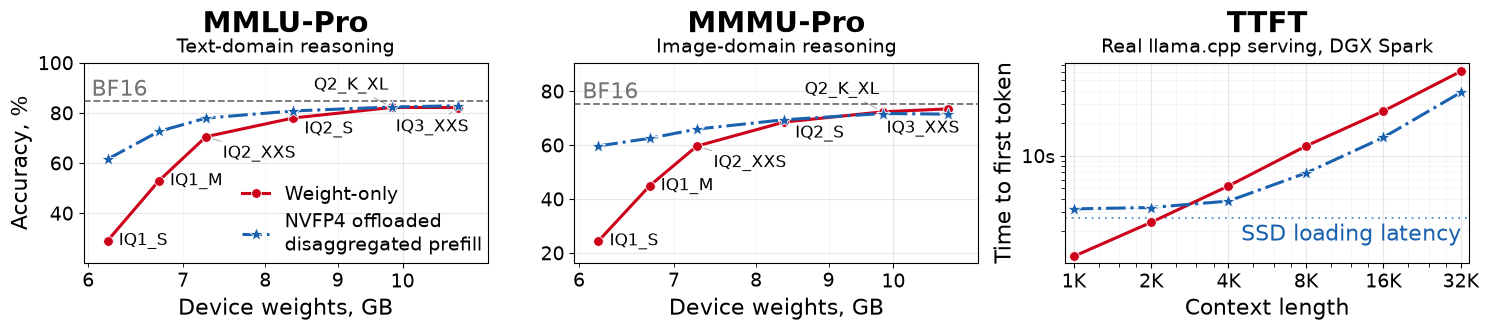

(<Figure size 1500x340 with 3 Axes>,
 array([<Axes: title={'center': 'MMLU-Pro'}, xlabel='Device weights, GB', ylabel='Accuracy, %'>,
        <Axes: title={'center': 'MMMU-Pro'}, xlabel='Device weights, GB'>,
        <Axes: title={'center': 'TTFT'}, xlabel='Context length', ylabel='Time to first token'>],
       dtype=object))

In [48]:
PLOT_1BIT = True  # Set False to hide IQ1_S and IQ1_M from this plot.

# Unsloth backbone GGUF bytes; excludes the separate BF16 vision projector.
# https://huggingface.co/unsloth/Qwen3.8-27B-GGUF/tree/main (metadata read 2026-09-13)
# ODP buffers reuse decode-weight memory, so both groups use this footprint.
GSQ_RCO_BYTES = {
    "iq1s": 6_192_222_208, "iq1m": 6_729_166_848,
    "iq2xxs": 7_266_070_528, "iq2s": 8_371_970_048,
    "q2kxl": 9_828_981_664, "iq3xxs": 10_934_860_704,
    "iq3s": 12_040_883_104, "q3kxl": 13_146_393_504,
}
GSQ_RCO_LABELS = {
    "iq1s": "IQ1_S", "iq1m": "IQ1_M", "iq2xxs": "IQ2_XXS", "iq2s": "IQ2_S",
    "q2kxl": "Q2_K_XL", "iq3xxs": "IQ3_XXS", "iq3s": "IQ3_S", "q3kxl": "Q3_K_XL",
}
GSQ_RCO_BENCHES = {
    "mmlu_pro": ("MMLU-Pro", "mmlu_pro", 12032),
    "mmmu": ("MMMU-Pro", "mmmu/vision_cot", 1730),
}
GSQ_RCO_SUBTITLES = {"mmlu_pro": "Text-domain reasoning",
                     "mmmu": "Image-domain reasoning"}


def _gsq_rco_tag(tag):
    """Return (format, disaggregated, repeat, QAD step), or None for unrelated runs."""
    tag, repeat = re.sub(r"-r\d+$", "", tag), re.search(r"-r(\d+)$", tag)
    repeat = int(repeat.group(1)) if repeat else 0
    if tag == "bf16":
        return "bf16", False, repeat, 0
    formats = "|".join(map(re.escape, GSQ_RCO_BYTES))
    m = re.fullmatch(rf"reason8k(250|500|750|980)-({formats})-d", tag)
    if m:
        return m.group(2), True, repeat, int(m.group(1))
    m = re.fullmatch(rf"unsloth-({formats})(?:-bf16)?(-d)?", tag)
    if m:
        # -bf16 means dequantized for evaluation, not unquantized model weights.
        return m.group(1), bool(m.group(2)), repeat, 0
    m = re.fullmatch(rf"nvfp4p-unsloth-({formats})-d", tag)
    return (m.group(1), True, repeat, 0) if m else None


def load_gsq_rco(root=Path("../evals/results/qwen3.8-27b")):
    """Return one {accuracy, tag} record per benchmark and (format, disaggregation).

    Prefer the largest completed reason8k step, falling back to basic -d.
    Prefer the unsuffixed run, then the lowest repeat ID at that step;
    never select by accuracy or average across repeats/checkpoints.
    """
    import warnings
    data = {}
    for bench, (_, subdir, expected_n) in GSQ_RCO_BENCHES.items():
        groups, ranks = {}, {}
        for path in sorted((Path(root) / subdir).glob("*/summary.json")):
            key = _gsq_rco_tag(path.parent.name)
            if key is None:
                continue
            fmt, disagg, repeat, step = key
            arm = (fmt, disagg)
            # Preserve the BF16 MMLU-Pro cohort; other r4 runs were accidental.
            excluded = {0} if bench == "mmlu_pro" and arm == ("bf16", False) else {4}
            if repeat in excluded:
                continue
            doc = json.loads(path.read_text())
            value = doc.get("accuracy")
            if (doc.get("n_scored") != expected_n or not isinstance(value, (float, int))
                    or not np.isfinite(value) or not 0 <= value <= 1):
                warnings.warn(f"Skipping incomplete/invalid evaluation: {path}")
                continue
            rank = (step, -repeat)
            if arm not in ranks or rank > ranks[arm]:
                ranks[arm] = rank
                groups[arm] = {"accuracy": 100.0 * value, "tag": path.parent.name}
            elif rank == ranks[arm]:
                raise ValueError(f"Duplicate aliases for {bench}, {key}: {path}")
        for (fmt, disagg), record in groups.items():
            if disagg:
                print(f"{GSQ_RCO_BENCHES[bench][0]} | {fmt}: selected {record['tag']}")
        data[bench] = groups
    return data


def _gsq_rco_plot_formats():
    return [fmt for fmt in sorted(GSQ_RCO_BYTES, key=GSQ_RCO_BYTES.get)
            if GSQ_RCO_BYTES[fmt] <= GSQ_RCO_BYTES["iq3xxs"]
            and (PLOT_1BIT or fmt not in {"iq1s", "iq1m"})]


def load_gsq_rco_prefill(path=Path("data/qwen3_8_27b_llama_cpp_ttft.csv")):
    """Measured llama.cpp TTFT (not prompt-only or transformer-stack latency)."""
    import csv
    curves = {mode: {} for mode in ("baseline", "odp")}
    with Path(path).open(newline="") as stream:
        for row in csv.DictReader(stream):
            length = int(row["seq_len"])
            if length <= 0 or int(row["reps"]) <= 0 or int(row["warmup"]) < 0:
                raise ValueError(f"Invalid llama.cpp benchmark metadata: {row}")
            for mode, curve in curves.items():
                value, low, high = (float(row[f"{mode}_{field}"])
                                    for field in ("ttft_ms", "ttft_min_ms", "ttft_max_ms"))
                if not all(np.isfinite(v) for v in (value, low, high)) or not 0 < low <= value <= high:
                    raise ValueError(f"Invalid {mode} TTFT range at {length}: {row}")
                if length in curve:
                    raise ValueError(f"Duplicate llama.cpp TTFT at {length}")
                curve[length] = (value, low, high)
    if not curves["baseline"]:
        raise ValueError(f"No llama.cpp TTFT measurements in {path}")
    return curves


def _place_gsq_rco_format_labels(axes, scale):
    """Use the same hand-tuned point-relative placement in both benchmarks."""
    # dx, dy in points; horizontal/vertical alignment; connector visibility.
    placements = {
        "IQ1_S":   (8, 0, "left", "center", False),
        "IQ1_M":   (8, 0, "left", "center", False),
        "IQ2_XXS": (12, -6, "left", "top", True),
        "IQ2_S":   (8, -2, "left", "top", False),
        "Q2_K_XL": (-3, 10, "right", "bottom", True),
        "IQ3_XXS": (8, -8, "right", "top", True),
    }
    for ax in axes:
        for label in ax.texts:
            if label.get_gid() != "format-label":
                continue
            dx, dy, ha, va, connector = placements[label.get_text()]
            label.set_position((dx * scale, dy * scale))
            label.set_ha(ha)
            label.set_va(va)
            label.arrow_patch.set_visible(connector)


def plot_gsq_rco(data=None, outfile=None, scale=1.0):
    if data is None:
        data = load_gsq_rco()
    from matplotlib.ticker import LogLocator, NullFormatter, FuncFormatter, FixedLocator
    F = lambda pt: pt * scale
    # Match bars_disag_both: canvas width and text sizes survive page-width scaling.
    fig, axes = plt.subplots(1, 3, figsize=(15 * scale, 3.4 * scale))
    formats = _gsq_rco_plot_formats()
    print("Pareto source: Unsloth. Both groups use the decode-weight "
          "footprint; ODP buffers reuse decode-weight memory.")
    styles = [(False, "Weight-only", RED, "-", "o"),
              (True, "NVFP4 offloaded\ndisaggregated prefill", BLUE, "-.", "*")]
    handles = {}
    for ax, bench in zip(axes[:2], ("mmlu_pro", "mmmu")):
        xs = [GSQ_RCO_BYTES[fmt] / 1e9 for fmt in formats]
        title = GSQ_RCO_BENCHES[bench][0]
        groups = data.get(bench, {})
        bounds = []
        for disagg, label, color, ls, marker in styles:
            point_formats = [fmt for fmt in formats if (fmt, disagg) in groups]
            points = [(GSQ_RCO_BYTES[fmt] / 1e9,
                       groups[(fmt, disagg)]["accuracy"])
                      for fmt in point_formats]
            if not points:
                continue
            x, y = np.asarray(points).T
            line, = ax.plot(x, y, color=color, ls=ls, lw=F(2.2),
                            marker=marker, ms=F(10 if disagg else 7),
                            markeredgecolor="white", markeredgewidth=F(0.6),
                            label=label, zorder=3)
            handles[label] = line
            if not disagg:
                for fmt, px, py in zip(point_formats, x, y):
                    annotation = ax.annotate(
                        GSQ_RCO_LABELS[fmt],
                        xy=(px, py), xytext=(F(4), -F(5)),
                        textcoords="offset points", ha="left", va="top",
                        fontsize=F(12), color="black", zorder=4,
                        arrowprops=dict(arrowstyle="-", color="black", alpha=0.4,
                                        lw=F(0.6), shrinkA=F(2), shrinkB=F(5)))
                    annotation.set_gid("format-label")
                    # Positioned inside the axes after layout; ignore temporary overflow.
                    annotation.set_in_layout(False)
            bounds.extend(y)
        if not bounds:
            raise ValueError(f"No completed Unsloth evaluations for {bench}")
        if ("bf16", False) not in groups:
            raise ValueError(f"No completed BF16 baseline for {bench}")
        baseline = groups[("bf16", False)]["accuracy"]
        ax.axhline(baseline, color="0.45", ls="--", lw=F(1.3))
        ax.annotate("BF16", xy=(0.02, baseline),
                    xycoords=("axes fraction", "data"), xytext=(0, F(4)),
                    textcoords="offset points", ha="left", color="0.45",
                    fontsize=F(16))
        bounds.append(baseline)
        span = max(max(bounds) - min(bounds), 1.0)
        # Reserve annotation space on both sides of the curves.
        ax.set_ylim(max(0, min(bounds) - 0.16 * span),
                    min(100, max(bounds) + 0.30 * span))
        ax.set_xscale("log")
        # Keep a small annotation margin, without forcing unused space to 14 GB.
        x_upper = max(xs) * 1.05
        ax.set_xlim(min(xs) / 1.04, x_upper)
        ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
        ax.xaxis.set_minor_locator(FixedLocator(
            [*range(2, 10), 12, 14]))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda value, pos: f"{value:g}"))
        ax.xaxis.set_minor_formatter(FuncFormatter(lambda value, pos: f"{value:g}"))
        ax.set_xlabel("Device weights, GB", fontsize=F(16))
        if ax is axes[0]:
            ax.set_ylabel("Accuracy, %", fontsize=F(16))
        ax.set_title(title, fontsize=F(21), fontweight="bold", pad=F(22))
        subtitle = ax.annotate(GSQ_RCO_SUBTITLES[bench], (0.5, 1.0),
                               xycoords="axes fraction", xytext=(0, F(4)),
                               textcoords="offset points", ha="center", va="bottom",
                               fontsize=F(14))
        subtitle.set_gid("workload-subtitle")
        ax.tick_params(which="both", labelsize=F(14))
        ax.tick_params(which="minor", length=F(3))
        ax.grid(True, which="major", alpha=0.3)
        ax.grid(True, which="minor", axis="x", alpha=0.12, lw=F(0.6))
        ax.set_axisbelow(True)
    # Measured llama.cpp time to first token; keep separate from stack microbenchmarks.
    latency_ax = axes[2]
    latency_ax.set_title("TTFT", fontsize=F(21), fontweight="bold", pad=F(22))
    subtitle = latency_ax.annotate("Real llama.cpp serving, DGX Spark", (0.5, 1.0),
                                    xycoords="axes fraction", xytext=(0, F(4)),
                                    textcoords="offset points", ha="center", va="bottom",
                                    fontsize=F(14))
    subtitle.set_gid("hardware-subtitle")
    latency_ax.set_xscale("log", base=2)
    latency_ax.set_yscale("log")
    prefill_curves = load_gsq_rco_prefill()
    lengths = sorted(n for n in prefill_curves["baseline"] if n >= 1024)
    latency_ax.set_xticks(lengths, [f"{n // 1024}K" if n >= 1024 else str(n) for n in lengths])
    latency_ax.set_yticks([1000, 10000], ["1s", "10s"])
    latency_ax.set_xlim(min(lengths) / 1.08, max(lengths) * 1.08)
    latency_values = []
    # Use the same visual encodings as the corresponding accuracy curves.
    for mode, label, color, ls, marker in (
            ("baseline", "Baseline", *styles[0][2:]),
            ("odp", "Offloaded disaggregated\nNVFP4 prefill", *styles[1][2:])):
        points = sorted((n, values) for n, values in prefill_curves[mode].items()
                        if n >= 1024)
        context = [n for n, _ in points]
        latency, low, high = np.asarray([values for _, values in points]).T
        latency_ax.plot(context, latency, color=color, ls=ls, marker=marker,
                        lw=F(2.2), ms=F(10 if mode == "odp" else 7),
                        markeredgecolor="white", markeredgewidth=F(0.6),
                        label=label, zorder=3)
        latency_ax.fill_between(context, low, high, color=color, alpha=0.15, linewidth=0)
        latency_values.extend(low)
        latency_values.extend(high)
    # Restore the load-only reference from the earlier cold-carve-out microbenchmark;
    # this is not a separate SSD-floor measurement from the llama.cpp TTFT run.
    import csv
    with Path("../qad/kernels/prefill/load_floor_zero_ssd.csv").open(newline="") as stream:
        floors = [float(row["load_ms"]) for row in csv.DictReader(stream)
                  if row["model"] == "Qwen/Qwen3.8-27B" and row["quant"] == "nvfp4"]
    if len(floors) != 1 or not np.isfinite(floors[0]) or floors[0] <= 0:
        raise ValueError("Expected one positive Qwen3.8-27B NVFP4 SSD-loading floor")
    floor = floors[0]
    latency_ax.axhline(floor, color=BLUE, ls=(0, (1, 3)), lw=F(1.2), alpha=0.85)
    latency_ax.annotate("SSD loading latency", xy=(0.98, floor),
                        xycoords=latency_ax.get_yaxis_transform(), xytext=(0, -F(4)),
                        textcoords="offset points", ha="right", va="top",
                        fontsize=F(16), color=BLUE)
    latency_values.append(floor)
    latency_ax.set_ylim(min(latency_values) / 1.15, max(latency_values) * 1.2)
    latency_ax.xaxis.set_minor_locator(LogLocator(base=2, subs=(1.25, 1.5, 1.75)))
    latency_ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
    latency_ax.xaxis.set_minor_formatter(NullFormatter())
    latency_ax.yaxis.set_minor_formatter(NullFormatter())
    latency_ax.set_xlabel("Context length", fontsize=F(16))
    latency_ax.set_ylabel("Time to first token", fontsize=F(16))
    latency_ax.tick_params(labelsize=F(14))
    latency_ax.tick_params(which="minor", length=F(3))
    latency_ax.grid(True, which="major", alpha=0.3)
    latency_ax.grid(True, which="minor", alpha=0.12, lw=F(0.6))
    latency_ax.set_axisbelow(True)

    labels = [label for _, label, *_ in styles if label in handles]
    axes[0].legend([handles[label] for label in labels], labels, loc="lower right",
                   ncol=1, frameon=False, fontsize=F(14), handlelength=1.4,
                   labelspacing=0.3, borderaxespad=0.3, borderpad=0)
    fig.tight_layout(pad=1.08 * scale)
    _place_gsq_rco_format_labels(axes[:2], scale)
    if outfile:
        fig.savefig(outfile, bbox_inches="tight", transparent=True)
    plt.show()
    return fig, axes


plot_gsq_rco(outfile="figures/pareto_gsq_rco_both.pdf")
